## Librerias

In [1]:
import warnings
#import prince
#import textwrap

import numpy as np
import pandas as pd
import seaborn as sns
from os import listdir
from os.path import isfile, join
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
warnings.filterwarnings('ignore')
from utils import decodificar_variables, wrap_labels
pd.options.display.float_format = '{:.4f}'.format
# Tutorial: https://www.geeksforgeeks.org/data-science-with-python-tutorial/
import prince







In [2]:
import numpy as np
import pandas as pd

print(pd.__version__)  # 1.5.3
print(np.__version__)  # 1.26.4


1.5.3
1.26.4


## Carga de Datos

In [3]:
# Definimos ruta de los archivos
ruta = 'datasets/'
primer_archivo = 'usu_individual_t117.txt'
# Cargamos el primer archivo
df_inicial = pd.read_csv(f'{ruta}{primer_archivo}', sep=';')
# Cargar los los nombres de los archivos en la lista 'archivos' link: https://es.stackoverflow.com/questions/24278/c%C3%B3mo-listar-todos-los-archivos-de-una-carpeta-usando-python
archivos = [arch for arch in listdir(ruta) if isfile(join(ruta, arch)) and arch not in primer_archivo]

In [4]:
for archivo in archivos:
    df_tmp = pd.read_csv(f'{ruta}{archivo}', sep=';')
    df_inicial = df_inicial.append(df_tmp)
    print(archivo)

Individual_t215.csv
usu_individual_t118.txt
usu_individual_t119.txt
usu_individual_T120.txt
usu_individual_T121.txt
usu_individual_T122.txt
usu_individual_T123.txt
usu_individual_T124.txt
usu_individual_T216.txt
usu_individual_t217.txt
usu_individual_t218.txt
usu_individual_t219.txt
usu_Individual_T220.txt
usu_individual_T221.txt
usu_individual_T222.txt
usu_individual_T223.txt
usu_individual_T224.txt
usu_individual_t316.txt
usu_individual_t317.txt
usu_individual_T318.txt
usu_individual_T319.txt
usu_individual_T320.txt
usu_individual_T321.txt
usu_individual_T322.txt
usu_individual_T323.txt
usu_individual_T324.txt
usu_individual_t416.txt
usu_Individual_T417.txt
usu_individual_t418.txt
usu_individual_T419.txt
usu_individual_T420.txt
usu_individual_T421.txt
usu_individual_T422.txt
usu_individual_T423.txt


In [5]:
## “El período de análisis se restringe a 2017–2024 con el objetivo de garantizar consistencia temporal completa en los cuatro trimestres de cada año. Se excluye 2016 debido a la falta de disponibilidad del primer trimestre en la base utilizada.

In [6]:
df_inicial.shape

(1836404, 181)

In [7]:
df_inicial.head()

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,IDECCFR,RDECCFR,GDECCFR,PDECCFR,ADECCFR,PONDIH,PP04B_CAES,PP11B_CAES,IDIMPP,Unnamed: 177
0,TQRMNOQURHKOMLCDEFIAH00469284,2017,1,1,4,1,43,S,2,861,...,,,,,,0.0000,NaN,NaN,NaN,NaN
1,TQRMNOQURHKOMLCDEFIAH00469284,2017,1,1,5,1,43,S,2,861,...,,,,,,0.0000,NaN,NaN,NaN,NaN
2,TQRMNOQURHKOMLCDEFIAH00469284,2017,1,1,6,1,43,S,2,861,...,,,,,,0.0000,NaN,NaN,NaN,NaN
3,TQRMNOQURHKOMLCDEFIAH00469284,2017,1,1,7,1,43,S,2,861,...,,,,,,0.0000,NaN,NaN,NaN,NaN
4,TQRMNOQURHKOMLCDEFIAH00469284,2017,1,1,8,0,43,S,2,861,...,,,,,,0.0000,NaN,NaN,NaN,NaN


In [8]:
df_inicial['ANO4'].value_counts()


2017    235332
2019    234375
2018    230083
2022    198097
2023    193382
2021    192600
2016    177515
2020    174227
2024    140765
2015     60028
Name: ANO4, dtype: int64

In [9]:
df_inicial['AÑO_TRIM'] = df_inicial['ANO4'] * 100 + df_inicial['TRIMESTRE']

In [10]:
df_inicial.groupby('AÑO_TRIM')['CODUSU'].count()

AÑO_TRIM
201502    60028
201602    59811
201603    59550
201604    58154
201701    58675
201702    59755
201703    58721
201704    58181
201801    57951
201802    57835
201803    56879
201804    57418
201901    59369
201902    59258
201903    57229
201904    58519
202001    51643
202002    37132
202003    41685
202004    43767
202101    46693
202102    47085
202103    48668
202104    50154
202201    49706
202202    50614
202203    49232
202204    48545
202301    48638
202302    49072
202303    48335
202304    47337
202401    46050
202402    47151
202403    47564
Name: CODUSU, dtype: int64

In [11]:

# Seleccionamos un grupo de variables

variables = ['ANO4','TRIMESTRE','REGION', 'AGLOMERADO','ESTADO', 'NIVEL_ED', 'CH04','P21','CH06','CH15', 'CH12','CH13','CH14','CH15','PONDERA', 'PONDIIO','P47T','CAT_OCUP', 'CAT_INAC','PONDIH','PP05H','PP3E_TOT','ITF','PP04A','PP07H','PP04C'] #'PP04B_COD','PP04D_COD']
df = df_inicial[variables]
# Excluimos NIVEL_ED 9 
df = df[df['NIVEL_ED']<9]
# Añadimos estas variables 'PP05H','PP07G4','PP3E_TOT','ITF', 'PP04A'  
# Reemplazamos con 0 los NA
df['PP05H'] = df['PP05H'].fillna(0)
df['PP3E_TOT'] = df['PP3E_TOT'].fillna(0)

#df['PP07G4'] = df['PP07G4'].fillna(0)
df['PP04A'] = df['PP04A'].fillna(0)
#df['PP07I'] = df['PP07I'].fillna(0)
df['PP07H'] = df['PP07H'].fillna(0)
df['PP04C'] = df['PP04C'].fillna(0)

#df['PP04B_COD'] = df['PP04B_COD'].fillna(0)
#df['PP04D_COD'] = df['PP04D_COD'].fillna(0)

# Tranformamos a entero 
df['PP05H'] = df['PP05H'].astype(int)
#df['PP07G4'] = df['PP07G4'].astype(int)
df['PP04A'] = df['PP04A'].astype(int)
#df['PP07I'] = df['PP07I'].astype(int)
df['PP07H'] = df['PP07H'].astype(int)
df['PP04C'] = df['PP04C'].astype(int)

#df['PP04B_COD'] = df['PP04B_COD'].astype(int)
#df['PP04D_COD'] = df['PP04D_COD'].astype(int)

print('Vemos la cantidad de filas y columnas',df.shape)

Vemos la cantidad de filas y columnas (1836404, 26)


## Feature Engineering

In [12]:
import numpy as np

# ===============================
# 1️⃣ AÑOS DE EDUCACIÓN (TU CRITERIO)
# ===============================

condiciones = [
    df['NIVEL_ED'] == 1,
    df['NIVEL_ED'] == 2,
    df['NIVEL_ED'] == 3,
    df['NIVEL_ED'] == 4,
    df['NIVEL_ED'] == 5,
    df['NIVEL_ED'] == 6,
    df['NIVEL_ED'] == 7
]

opciones = [5, 7, 10, 12, 13, 17, 0]

df['Años Educacion'] = np.select(condiciones, opciones, 0)

# ===============================
# 2️⃣ EXPERIENCIA POTENCIAL (MINCER)
# ===============================

df['Experiencia Potencial'] = df['CH06'] - df['Años Educacion'] - 6

# Truncar valores negativos en 0
df['Experiencia Potencial'] = np.where(
    df['Experiencia Potencial'] < 0,
    0,
    df['Experiencia Potencial']
)

# Término cuadrático (ya corregido)
df['Experiencia Potencial Cuadrado'] = df['Experiencia Potencial'] ** 2

# ===============================
# 3️⃣ ELIMINAR EDAD² (NO USAR)
# ===============================

# ❌ Eliminar esta línea
# df['Edad_Cuadrado'] = df['CH06'] ** 2

df.head()

,ANO4,TRIMESTRE,REGION,AGLOMERADO,ESTADO,NIVEL_ED,CH04,P21,CH06,CH15,...,PONDIH,PP05H,PP3E_TOT,ITF,PP04A,PP07H,PP04C,Años Educacion,Experiencia Potencial,Experiencia Potencial Cuadrado
0,2017,1,43,2,3,2,2,0.0000,18,1,...,0.0000,0,0,0.0000,0,0,0,7,5,25
1,2017,1,43,2,3,3,2,0.0000,13,1,...,0.0000,0,0,0.0000,0,0,0,10,0,0
2,2017,1,43,2,3,3,1,0.0000,15,1,...,0.0000,0,0,0.0000,0,0,0,10,0,0
3,2017,1,43,2,3,3,2,0.0000,11,1,...,0.0000,0,0,0.0000,0,0,0,10,0,0
4,2017,1,43,2,4,1,1,0.0000,7,1,...,0.0000,0,0,0.0000,0,0,0,5,0,0


In [13]:
# Convertimos los tipos de datos a str:
#variables_str = ['REGION','AGLOMERADO', 'ESTADO', 'NIVEL_ED', 'CH04', 'CH15', 'CAT_OCUP', 'CAT_INAC','CH06','Edad_Cuadrado', 'CH12','CH13','CH14','CH15','PP05H','PP3E_TOT','ITF','PP04A','PP07H']
variables_str = ['REGION','AGLOMERADO', 'ESTADO', 'NIVEL_ED', 'CH04', 'CH15', 'CAT_OCUP', 'CAT_INAC','CH06','CH12','CH13','CH14','CH15','PP05H','PP3E_TOT','ITF','PP04A','PP07H','PP04C'] #,'PP04B_COD','PP04D_COD']

for variable in variables_str:
    df[variable] = df[variable].astype('str')
    # Filtrar valores mayores a 0 en las variables categóricas convertidas a str

## Decodificacion de variables

In [14]:
# Definimos los diccionarios para cada una de las variables
## REGION

dict_REGION = {
                 '1':'Gran Buenos Aires',
               '40': 'Noroeste',
               '41': 'Noreste',
               '42': 'Cuyo',
               '43': 'Pampeana',
               '44': 'Patagonia'

}


dict_AGLOMERADO = {
    '2': 'Gran La Plata',
    '3': 'Bahía Blanca-Cerri',
    '4': 'Gran Rosario',
    '5': 'Gran Santa Fe',
    '6': 'Gran Paraná',
    '7': 'Posadas',
    '8': 'Gran Resistencia',
    '9': 'Comodoro Rivadavia-Rada Tilly',
    '10': 'Gran Mendoza',
    '12': 'Corrientes',
    '13': 'Gran Córdoba',
    '14': 'Concordia',
    '15': 'Formosa',
    '17': 'Neuquén-Plottier',
    '18': 'Santiago del Estero-La Banda',
    '19': 'Jujuy-Palpalá',
    '20': 'Río Gallegos',
    '22': 'Gran Catamarca',
    '23': 'Gran Salta',
    '25': 'La Rioja',
    '26': 'Gran San Luis',
    '27': 'Gran San Juan',
    '29': 'Gran Tucumán-Tafí Viejo',
    '30': 'Santa Rosa-Toay',
    '31': 'Ushuaia-Río Grande',
    '32': 'CABA',
    '33': 'Gran Buenos Aires',
    '34': 'Mar del Plata',
    '36': 'Río Cuarto',
    '38': 'San Nicolás-Villa Constitución',
    '91': 'Rawson-Trelew',
    '93': 'Viedma-Carmen de Patagones'
}



dict_NIVEL_ED = {     
               '1': 'Primario incompleto',
               '2': 'Primario completo',
               '3': 'Secundario incompleto',
               '4': 'Secundario completo',
               '5': 'Universitario incompleto',
               '6': 'Universitario completo',
               '7': 'Sin instrucción', 
               '9':  'Ns/Nr'    }

## ESTADO
dict_ESTADO = {       '0':'Entrevista individual no realizada',
               '1':'Ocupado',
               '2': 'Desocupado',
               '3': 'Inactivo',
               '4': 'Menor de 10 años' }

## CH04
dict_CH04 = {  '1':'Varón',
               '2':'Mujer'}

## CH15
dict_CH15 = {     
               '1':'En esta localidad',
               '2': 'En otra localidad de esta provincia',
               '3': 'En otra provincia',
               '4': 'En país limítrofe',
               '5': 'En otro país',
               '6':  'No había nacido',
               '9':   'Ns/Nr'    }

## CAT_OCUP
dict_CAT_OCUP = {'1.0':'Patrón',
                 '2.0': 'Cuenta propia',
                 '3.0': 'Obrero o empleado',
                 '4.0': 'Trabajador familiar sin remunación'}


## CAT_INAC
dict_CAT_INAC = {       
               '1':'Jubilado/Pensionado',
               '2': 'Rentista',
               '3': 'Estudiante',
               '4': 'Ama de casa',
               '5': 'Menor de 6 años',
               '6':  'Discapacitado',
               '7':   'Otros'   }

## PP04A
dict_PP04A = {  '1':'Estatal',
                '2':'Privada'}
                #'3':'de otro tipo'}

## Descuento jubiltario
dict_PP07H= {  '1':'Sí',
                 '2':'No'}

## Tamaño de la empresa
dict_PP04C = {
    1: '1 persona',
    2: '2 personas',
    3: '3 personas',
    4: '4 personas',
    5: '5 personas',
    6: '6 a 10 personas',
    7: '11 a 25 personas',
    8: '26 a 40 personas',
    9: '41 a 100 personas',
    10: '101 a 200 personas',
    11: '201 a 500 personas',
    12: 'Más de 500 personas',
    99: 'Ns/Nr'}


df['PP07H']= decodificar_variables(df, 'PP07H', dict_PP07H)
df['REGION']= decodificar_variables(df, 'REGION', dict_REGION)
df['AGLOMERADO']= decodificar_variables(df, 'AGLOMERADO', dict_AGLOMERADO)
df['ESTADO']= decodificar_variables(df, 'ESTADO', dict_ESTADO)
df['NIVEL_ED']= decodificar_variables(df, 'NIVEL_ED', dict_NIVEL_ED)
df['ESTADO']= decodificar_variables(df, 'ESTADO', dict_ESTADO)
df['CH04']= decodificar_variables(df,'CH04', dict_CH04)
df['CH15']= decodificar_variables(df, 'CH15', dict_CH15)
df['CAT_OCUP']= decodificar_variables(df, 'CAT_OCUP', dict_CAT_OCUP)
df['CAT_INAC']= decodificar_variables(df, 'CAT_INAC', dict_CAT_INAC)
df['PP04A']= decodificar_variables(df,'PP04A', dict_PP04A)
df['PP04C']= decodificar_variables(df,'PP04C', dict_PP04C)





In [15]:
dict_names = {'CH04': 'Sexo',
              'CH06': 'Edad',
              'CH12': 'Maximo Nivel Educativo',
              'CH13': 'Finalizo Nivel',
              'CH14': 'Ultimo Año Aprobado',
              'CH15': 'Nacionalidad',
              'REGION': 'Region',
              'ESTADO': 'Estado',
              'NIVEL_ED': 'Nivel Educativo',
              'P21': 'Ingreso_Principal',
              'P47T': 'Ingreso Total',
              'ITF': 'Ingreso_TotalFamiliar',
              'CAT_OCUP': 'Categoria Ocupacional',
              'CAT_INAC': 'Categoria Inactividad',
              'PP05H': 'Tiempo Trabajado',
              'PP07G4': 'Obra social',
              'PP3E_TOT': 'Horas trabajadas',
              'PP04B3_MES':'Meses que trabaja',
              'PP04A':'Tipo_empleador',
              'PP07H': 'Descuento jubilatorio',
              'PP04C': 'Tamaño Establecimiento'
        
            }

df.rename(columns = dict_names, inplace = True)
# Nos quedamos con los que tienen ingresos totales y principales  mayores a 0
df_reg= df[(df['Ingreso Total']>0) & (df['Ingreso_Principal']>0) ] #& (df['Ingreso_TotalFamiliar']>0)]
# Dropeamos PONDERA,PONDIH,  Ingreso Total
df_reg.drop(['PONDIH','Ingreso Total'], axis = 1, inplace=True)
# Ponemos Ingreso Principal al final
df_reg['Ingreso Principal'] = df_reg['Ingreso_Principal'] 
df_reg.drop(['Ingreso_Principal'], axis = 1, inplace=True)
# Ponemos Ingreso Total Familiar
df_reg['ITF'] = df_reg['Ingreso_TotalFamiliar'] 
df_reg.drop(['Ingreso_TotalFamiliar'], axis = 1, inplace=True)
# Reemplazar los valores Sexo
df_reg['Sexo'] = df_reg['Sexo'].replace({'1': 'Varón', '2': 'Mujer'})
# Reemplazar los valores Tipo empleador
#df_reg['Tipo empleador'] = df_reg['Tipo empleador'].replace({'1': 'Estatal', '2': 'Privada','3': 'de otro tipo'})
# Reemplazar valores numéricos por etiquetas de texto
df_reg['Tipo_empleador'] = df_reg['Tipo_empleador'].replace({
    1: 'Estatal',
    2: 'Privada',
    3: 'de otro tipo'})
#})
df_reg['Categoria Ocupacional'] = df_reg['Categoria Ocupacional'].replace({
    1.0: 'Patrón',
    2.0: 'Cuenta propia',
    3.0: 'Obrero o empleado'})



df_reg['Provincia'] = df_reg['AGLOMERADO'].replace({
    # CABA y Gran Buenos Aires
    'CABA': 'CABA',
    'Gran Buenos Aires': 'Buenos Aires',
    'Gran La Plata': 'Buenos Aires',
    'Mar del Plata': 'Buenos Aires',
    'Bahía Blanca-Cerri': 'Buenos Aires',
    'San Nicolás-Villa Constitución': 'Buenos Aires',
    # Santa Fe
    'Gran Rosario': 'Santa Fe',
    'Gran Santa Fe': 'Santa Fe',
    # Córdoba
    'Gran Córdoba': 'Córdoba',
    'Río Cuarto': 'Córdoba',
    # Mendoza
    'Gran Mendoza': 'Mendoza',
    # San Juan
    'Gran San Juan': 'San Juan',
    # Catamarca
    'Gran Catamarca': 'Catamarca',
    # La Rioja
    'La Rioja': 'La Rioja',
    # Santiago del Estero
    'Santiago del Estero-La Banda': 'Santiago del Estero',
    # Tucumán
    'Gran Tucumán-Tafí Viejo': 'Tucumán',
    # Jujuy
    'Jujuy-Palpalá': 'Jujuy',
    # Chaco
    'Gran Resistencia': 'Chaco',
    # Misiones
    'Posadas': 'Misiones',
    # Corrientes
    'Corrientes': 'Corrientes',
    # Formosa
    'Formosa': 'Formosa',
    # Entre Ríos
    'Gran Paraná': 'Entre Ríos',
    'Concordia': 'Entre Ríos',
    # La Pampa
    'Santa Rosa-Toay': 'La Pampa',
    # San Luis
    'Gran San Luis': 'San Luis',
    # Neuquén
    'Neuquén-Plottier': 'Neuquén',
    # Chubut
    'Comodoro Rivadavia-Rada Tilly': 'Chubut',
    'Rawson-Trelew': 'Chubut',
    # Río Negro
    'Viedma-Carmen de Patagones': 'Río Negro',
    # Santa Cruz
    'Río Gallegos': 'Santa Cruz',
    # Tierra del Fuego
    'Ushuaia-Río Grande': 'Tierra del Fuego',
    # Salta
    'Gran Salta': 'Salta'
})


# Verificación final
print(df_reg['Provincia'].value_counts())



# Reseteamos los indices
df_reg.reset_index(inplace = True)
df_reg.drop('index', axis = 1, inplace = True)

Buenos Aires           113236
Córdoba                 46426
Santa Fe                37140
Salta                   33154
Entre Ríos              30817
Chubut                  29227
Tucumán                 27638
Mendoza                 26437
Jujuy                   25371
San Juan                24004
Catamarca               22231
CABA                    22229
Santiago del Estero     21643
La Rioja                20429
San Luis                19142
Misiones                16415
Corrientes              16132
Chaco                   15764
Formosa                 15112
Tierra del Fuego        14019
Neuquén                 12861
Río Negro               12653
Santa Cruz              10695
La Pampa                 9810
Name: Provincia, dtype: int64


In [16]:
print(df_reg.columns)

Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel Educativo', 'Sexo', 'Edad', 'Nacionalidad',
       'Maximo Nivel Educativo', 'Finalizo Nivel', 'Ultimo Año Aprobado',
       'Nacionalidad', 'PONDERA', 'PONDIIO', 'Categoria Ocupacional',
       'Categoria Inactividad', 'Tiempo Trabajado', 'Horas trabajadas',
       'Tipo_empleador', 'Descuento jubilatorio', 'Tamaño Establecimiento',
       'Años Educacion', 'Experiencia Potencial',
       'Experiencia Potencial Cuadrado', 'Ingreso Principal', 'ITF',
       'Provincia'],
      dtype='object')


## Creación variable: Tamaño_empresa

In [17]:
# Excluir Ns/Nr
df_reg = df_reg[df_reg['Tamaño Establecimiento'] != 99]

# Crear agrupación estructural
map_tamano_estructural = {
    1: 'Microempresa',
    2: 'Microempresa',
    3: 'Microempresa',
    4: 'Microempresa',
    5: 'Microempresa',
    6: 'Microempresa',
    7: 'Empresa_Mediana',
    8: 'Empresa_Mediana',
    9: 'Empresa_Mediana',
    10: 'Empresa_Mediana',
    11: 'Empresa_Grande',
    12: 'Empresa_Grande'
}

df_reg['Tamaño_Empresa'] = df_reg['Tamaño Establecimiento'].map(map_tamano_estructural)

df_reg['Tamaño_Empresa'] = df_reg['Tamaño_Empresa'].astype('category')

In [18]:
df_reg['Tamaño_Empresa'].value_counts(normalize=True)

Series([], Name: Tamaño_Empresa, dtype: float64)

In [19]:
#En economías como la argentina suele predominar microempresa → eso ya es dato estructural.

In [20]:
df_reg.groupby(['Tamaño_Empresa','Nivel Educativo'])['Ingreso Principal'].mean()

Series([], Name: Ingreso Principal, dtype: float64)

In [21]:
## Los retornos educativo parecen amplificarse en grandes empresas.

In [22]:
# Convertir a números (NaN si no es convertible)
df_reg['Tamaño_Establecimiento'] = pd.to_numeric(df_reg['Tamaño Establecimiento'], errors='coerce')

# Excluir 0, 99 y NaN
df_reg = df_reg[df_reg['Tamaño_Establecimiento'].notna() & 
                (df_reg['Tamaño_Establecimiento'] != 99) & 
                (df_reg['Tamaño_Establecimiento'] != 0)]

# Mapear tamaños
map_tamano_estructural = {
    1: 'Microempresa', 2: 'Microempresa', 3: 'Microempresa', 4: 'Microempresa', 5: 'Microempresa', 6: 'Microempresa',
    7: 'Empresa_Mediana', 8: 'Empresa_Mediana', 9: 'Empresa_Mediana', 10: 'Empresa_Mediana',
    11: 'Empresa_Grande', 12: 'Empresa_Grande'
}

df_reg['Tamaño_Empresa'] = df_reg['Tamaño_Establecimiento'].map(map_tamano_estructural)

# Por si quedara algún valor raro, asignar 'Desconocido'
df_reg['Tamaño_Empresa'] = df_reg['Tamaño_Empresa'].fillna('Desconocido')

# Categoría y conteo
df_reg['Tamaño_Empresa'] = df_reg['Tamaño_Empresa'].astype('category')
print(df_reg['Tamaño_Empresa'].value_counts())

Microempresa       274007
Empresa_Mediana    177263
Empresa_Grande      59484
Name: Tamaño_Empresa, dtype: int64


In [23]:
df_reg['Tamaño Establecimiento'].unique()

array(['4', '7', '1', '3', '8', '12', '2', '6', '11', '9', '10', '5'],
      dtype=object)

In [24]:
##La variable sectorial se construye a partir de la clasificación de actividades económicas CAES-Mercosur 1.0 (INDEC). Para evitar una excesiva fragmentación sectorial, las ramas de actividad se agrupan en macrosectores productivos siguiendo criterios de similitud tecnológica y organizacional.

## Analisis Ingresos + Genero
Período 2017 - 2024

In [25]:
#La serie analizada se inicia en 2017 debido a que los microdatos de 2016 presentan registros incompletos y falta de consistencia metodológica en algunos aglomerados, por lo que se priorizó la calidad de la serie.

In [26]:
df_reg.head(10)

,ANO4,TRIMESTRE,Region,AGLOMERADO,Estado,Nivel Educativo,Sexo,Edad,Nacionalidad,Maximo Nivel Educativo,...,Descuento jubilatorio,Tamaño Establecimiento,Años Educacion,Experiencia Potencial,Experiencia Potencial Cuadrado,Ingreso Principal,ITF,Provincia,Tamaño_Empresa,Tamaño_Establecimiento
0,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,No,4,7,7,49,1500.0000,0.0,Buenos Aires,Microempresa,4
1,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,Sí,7,12,46,2116,9500.0000,9500.0,Buenos Aires,Empresa_Mediana,7
3,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,42,En país limítrofe,2,...,0,1,7,29,841,6000.0000,6000.0,Buenos Aires,Microempresa,1
4,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,59,En esta localidad,7,...,No,3,17,36,1296,14000.0000,21000.0,Buenos Aires,Microempresa,3
5,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,41,En esta localidad,6,...,Sí,8,17,18,324,9000.0000,0.0,Buenos Aires,Empresa_Mediana,8
6,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario incompleto,Varón,49,En otra localidad de esta provincia,4,...,0,1,10,33,1089,20000.0000,0.0,Buenos Aires,Microempresa,1
7,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,47,En esta localidad,4,...,Sí,8,12,29,841,15000.0000,0.0,Buenos Aires,Empresa_Mediana,8
9,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Varón,52,En esta localidad,4,...,Sí,12,12,34,1156,23000.0000,29000.0,Buenos Aires,Empresa_Grande,12
10,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,54,En esta localidad,4,...,Sí,7,12,36,1296,6000.0000,29000.0,Buenos Aires,Empresa_Mediana,7
12,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,25,En esta localidad,7,...,Sí,7,17,2,4,11000.0000,0.0,Buenos Aires,Empresa_Mediana,7


In [27]:
df_reg.columns

Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel Educativo', 'Sexo', 'Edad', 'Nacionalidad',
       'Maximo Nivel Educativo', 'Finalizo Nivel', 'Ultimo Año Aprobado',
       'Nacionalidad', 'PONDERA', 'PONDIIO', 'Categoria Ocupacional',
       'Categoria Inactividad', 'Tiempo Trabajado', 'Horas trabajadas',
       'Tipo_empleador', 'Descuento jubilatorio', 'Tamaño Establecimiento',
       'Años Educacion', 'Experiencia Potencial',
       'Experiencia Potencial Cuadrado', 'Ingreso Principal', 'ITF',
       'Provincia', 'Tamaño_Empresa', 'Tamaño_Establecimiento'],
      dtype='object')

In [28]:
# Promedio de ingreso principal por sector
df_reg.groupby("Tamaño_Empresa")["Ingreso Principal"].mean()

# Cantidad de observaciones por sector
df_reg["Tamaño_Empresa"].value_counts()

Microempresa       274007
Empresa_Mediana    177263
Empresa_Grande      59484
Name: Tamaño_Empresa, dtype: int64

In [29]:
# Mantener solo asalariados del sector estatal y privado
df_reg = df_reg[
    df_reg['Tipo_empleador'].isin(['Estatal', 'Privada'])
].copy()

# Eliminar categorías vacías
df_reg['Tipo_empleador'] = (
    df_reg['Tipo_empleador']
    .astype('category')
    .cat.remove_unused_categories()
)

# Verificación
print(df_reg['Tipo_empleador'].value_counts())
print(df_reg['Tipo_empleador'].cat.categories)

Privada    374079
Estatal    130765
Name: Tipo_empleador, dtype: int64
Index(['Estatal', 'Privada'], dtype='object')


In [30]:
# Cantidad de registros por año
df_reg['ANO4'].value_counts().sort_index()


2015    18825
2016    45656
2017    62923
2018    63244
2019    66458
2020    46113
2021    53407
2022    54586
2023    54265
2024    39367
Name: ANO4, dtype: int64

In [31]:
df_reg['Nivel Educativo'].value_counts().sort_index()

Primario completo            62413
Primario incompleto          15690
Secundario completo         150415
Secundario incompleto        83686
Sin instrucción               1527
Universitario completo      120415
Universitario incompleto     70698
Name: Nivel Educativo, dtype: int64

In [32]:
df_reg['Categoria Ocupacional'].value_counts().sort_index()

Cuenta propia        126923
Obrero o empleado    358178
Patrón                19743
Name: Categoria Ocupacional, dtype: int64

## Creación variable: Condición Laboral

In [33]:
#La muestra se restringe a trabajadores asalariados ocupados. La informalidad laboral se define como la ausencia de descuento jubilatorio, siguiendo la definición estándar utilizada por la EPH del INDEC.

In [130]:
df_reg['Condición laboral'] = df_reg['Descuento jubilatorio'].map({
    'Sí': 'Empleo formal',
    'No': 'Empleo informal'
})


In [35]:
df_reg['Condición laboral'].value_counts(dropna=False)


Empleo formal      252911
NaN                146663
Empleo informal    105270
Name: Condición laboral, dtype: int64

In [131]:
df_mincer = df_reg[df_reg['Condición laboral'].notna()].copy()


In [37]:
##Trabajar solo con ocupados asalariados!!Eso elimina:

#Inactivos #Desocupados #Cuentapropistas
#Patrones #Casos con descuento jubilatorio = 0


df_mincer = df_reg[
    (df_reg['Estado'] == 'Ocupado') &
    (df_reg['Condición laboral'].notna())
].copy()


In [38]:
## El universo pertenece Asalariados( Obreros) 

df_mincer['Categoria Ocupacional'].value_counts()

Obrero o empleado    358177
Cuenta propia             4
Name: Categoria Ocupacional, dtype: int64

In [39]:
## Me quedo con asalariados: obreros empleados 

df_mincer = df_mincer[
    df_mincer['Categoria Ocupacional'] == 'Obrero o empleado'
]

#DF + VARIABLE CONDICIÓN LABORAL

In [132]:
# 1️⃣ Copia de trabajo
df = df_reg.copy()

# 2️⃣ Filtrar solo ocupados
df = df[df['Estado'] == 'Ocupado'].copy()

# 3️⃣ Filtrar solo asalariados
df = df[df['Categoria Ocupacional'] == 'Obrero o empleado'].copy()

# 4️⃣ Normalizar variable descuento jubilatorio
df['Descuento jubilatorio'] = df['Descuento jubilatorio'].astype(str).str.strip()

# 5️⃣ Crear variable dicotómica formalidad
df['Condición laboral'] = df['Descuento jubilatorio'].map({
    'Sí': 'Empleo formal',
    'No': 'Empleo informal',
    '0': 'Empleo informal'
})

# 6️⃣ Eliminar observaciones sin información clara
df = df[df['Condición laboral'].notna()].copy()

# 7️⃣ Convertir a categoría
df['Condición laboral'] = pd.Categorical(
    df['Condición laboral'],
    categories=['Empleo formal', 'Empleo informal']
)

# 8️⃣ Guardar base final
df_informal = df.copy()

In [133]:
df_informal = df_informal[df_informal['Condición laboral'].notna()].copy()

In [134]:
df_informal.head(10)

,ANO4,TRIMESTRE,Region,AGLOMERADO,Estado,Nivel Educativo,Sexo,Edad,Nacionalidad,Maximo Nivel Educativo,...,Tamaño Establecimiento,Años Educacion,Experiencia Potencial,Experiencia Potencial Cuadrado,Ingreso Principal,ITF,Provincia,Tamaño_Empresa,Tamaño_Establecimiento,Condición laboral
0,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,4,7,7,49,1500.0000,0.0,Buenos Aires,Microempresa,4,Empleo informal
1,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,7,12,46,2116,9500.0000,9500.0,Buenos Aires,Empresa_Mediana,7,Empleo formal
4,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,59,En esta localidad,7,...,3,17,36,1296,14000.0000,21000.0,Buenos Aires,Microempresa,3,Empleo informal
5,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,41,En esta localidad,6,...,8,17,18,324,9000.0000,0.0,Buenos Aires,Empresa_Mediana,8,Empleo formal
7,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,47,En esta localidad,4,...,8,12,29,841,15000.0000,0.0,Buenos Aires,Empresa_Mediana,8,Empleo formal
10,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,54,En esta localidad,4,...,7,12,36,1296,6000.0000,29000.0,Buenos Aires,Empresa_Mediana,7,Empleo formal
12,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,25,En esta localidad,7,...,7,17,2,4,11000.0000,0.0,Buenos Aires,Empresa_Mediana,7,Empleo formal
14,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario incompleto,Varón,22,En esta localidad,4,...,2,10,6,36,4000.0000,10000.0,Buenos Aires,Microempresa,2,Empleo informal
15,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,27,En esta localidad,2,...,7,7,14,196,10000.0000,10000.0,Buenos Aires,Empresa_Mediana,7,Empleo informal
16,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,38,En otra provincia,2,...,6,7,25,625,5000.0000,8000.0,Buenos Aires,Microempresa,6,Empleo informal


In [135]:
### Tasa de informalidad entre asalariados:tasa = 161794 / (312638 + 161794)
#print(tasa) Informalidad≈34%

In [136]:
df_reg= df_reg[(df_reg['ANO4'] >= 2017) & (df_reg['ANO4'] <= 2024)].copy()

In [137]:
print(df_informal.columns)

Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel Educativo', 'Sexo', 'Edad', 'Nacionalidad',
       'Maximo Nivel Educativo', 'Finalizo Nivel', 'Ultimo Año Aprobado',
       'Nacionalidad', 'PONDERA', 'PONDIIO', 'Categoria Ocupacional',
       'Categoria Inactividad', 'Tiempo Trabajado', 'Horas trabajadas',
       'Tipo_empleador', 'Descuento jubilatorio', 'Tamaño Establecimiento',
       'Años Educacion', 'Experiencia Potencial',
       'Experiencia Potencial Cuadrado', 'Ingreso Principal', 'ITF',
       'Provincia', 'Tamaño_Empresa', 'Tamaño_Establecimiento',
       'Condición laboral'],
      dtype='object')


In [138]:
df_informal['Nivel Educativo'].value_counts()

Secundario completo         95909
Universitario completo      82760
Secundario incompleto       48539
Universitario incompleto    45587
Primario completo           30576
Primario incompleto          7143
Sin instrucción               667
Name: Nivel Educativo, dtype: int64

## Deflación + IPC

In [158]:
import pandas as pd

# ============================================================
# ARCHIVO IPC INDEC
# ============================================================

archivo_ipc = "sh_ipc_08_26.xls"

# ============================================================
# VER LAS SOLAPAS DISPONIBLES
# ============================================================

xls = pd.ExcelFile(archivo_ipc)

print("Solapas disponibles:")
for i, hoja in enumerate(xls.sheet_names):
    print(i, repr(hoja))


# ============================================================
# BUSCAR AUTOMÁTICAMENTE LA SOLAPA DE COBERTURA NACIONAL
# ============================================================

hoja_ipc = next(
    hoja for hoja in xls.sheet_names
    if "cobertura nacional" in hoja.lower()
)

print("\nSolapa seleccionada:", repr(hoja_ipc))


# ============================================================
# LEER LA SOLAPA
# ============================================================

ipc_raw = pd.read_excel(
    archivo_ipc,
    sheet_name=hoja_ipc,
    header=None
)

print("\nDimensiones del archivo:", ipc_raw.shape)

display(ipc_raw.head(15))

Solapas disponibles:
0 'Variación mensual IPC Nacional'
1 'Var. interanual IPC Nacional'
2 'Índices IPC Cobertura Nacional'
3 'IPC GBA Base dic 2016'
4 'IPC GBA Abril 2016-Mayo 2017'
5 'Ponderaciones'

Solapa seleccionada: 'Índices IPC Cobertura Nacional'

Dimensiones del archivo: (216, 117)


,0,1,2,3,4,5,6,7,8,9,...,107,108,109,110,111,112,113,114,115,116
0,Índice de precios al consumidor con cobertura ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Período de referencia: Diciembre 2016=100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Índices correspondientes a los meses de diciem...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Total nacional,2016-12-01 00:00:00,2017-01-01 00:00:00,2017-02-01 00:00:00,2017-03-01 00:00:00,2017-04-01 00:00:00,2017-05-01 00:00:00,2017-06-01 00:00:00,2017-07-01 00:00:00,2017-08-01 00:00:00,...,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-26 00:00:00,2026-04-01 00:00:00,2026-05-01 00:00:00,2026-06-01 00:00:00,2026-07-01 00:00:00
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Nivel general y divisiones COICOP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Nivel general,100,101.5859,103.6859,106.1476,108.9667,110.5301,111.8477,113.7852,115.3819,...,9603.8623,9841.3581,10121.3715,10413.0309,10714.6255,11077.0608,11363.0904,11607.3937,11826.4103,12076.3937


In [140]:
# ============================================================
# INSPECCIONAR ESTRUCTURA DEL IPC
# ============================================================

# Mostrar las primeras 25 filas y las primeras 35 columnas
display(ipc_raw.iloc[:25, :35])

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,Índice de precios al consumidor con cobertura ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Período de referencia: Diciembre 2016=100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Índices correspondientes a los meses de diciem...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Total nacional,2016-12-01 00:00:00,2017-01-01 00:00:00,2017-02-01 00:00:00,2017-03-01 00:00:00,2017-04-01 00:00:00,2017-05-01 00:00:00,2017-06-01 00:00:00,2017-07-01 00:00:00,2017-08-01 00:00:00,...,2018-12-01 00:00:00,2019-01-01 00:00:00,2019-02-01 00:00:00,2019-03-01 00:00:00,2019-04-01 00:00:00,2019-05-01 00:00:00,2019-06-01 00:00:00,2019-07-01 00:00:00,2019-08-01 00:00:00,2019-09-01 00:00:00
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Nivel general y divisiones COICOP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Nivel general,100,101.5859,103.6859,106.1476,108.9667,110.5301,111.8477,113.7852,115.3819,...,184.2552,189.6101,196.7501,205.9571,213.0517,219.5691,225.5370,230.4940,239.6077,253.7102


In [141]:
import pandas as pd
import numpy as np

# ============================================================
# 1. EXTRAER FECHAS Y NIVEL GENERAL DEL IPC
# ============================================================

# Fila 5 contiene las fechas
fechas = pd.to_datetime(ipc_raw.iloc[5, 1:], errors='coerce')

# Fila 9 contiene "Nivel general"
ipc_valores = pd.to_numeric(
    ipc_raw.iloc[9, 1:],
    errors='coerce'
)

# Crear base mensual
ipc_mensual = pd.DataFrame({
    'Fecha': fechas.values,
    'IPC_Mensual': ipc_valores.values
})

# Eliminar columnas/filas sin fecha o sin valor
ipc_mensual = ipc_mensual.dropna(
    subset=['Fecha', 'IPC_Mensual']
).copy()

# ============================================================
# 2. RESTRINGIR AL PERÍODO DE ANÁLISIS: 2017-2024
# ============================================================

ipc_mensual = ipc_mensual[
    ipc_mensual['Fecha'].dt.year.between(2017, 2024)
].copy()

# ============================================================
# 3. CREAR AÑO Y TRIMESTRE
# ============================================================

ipc_mensual['ANO4'] = ipc_mensual['Fecha'].dt.year
ipc_mensual['TRIMESTRE'] = ipc_mensual['Fecha'].dt.quarter

# Ordenar
ipc_mensual = ipc_mensual.sort_values('Fecha').reset_index(drop=True)

# Mostrar resultado
display(ipc_mensual.head(15))

,Fecha,IPC_Mensual,ANO4,TRIMESTRE
0,2017-01-01,101.5859,2017,1
1,2017-02-01,103.6859,2017,1
2,2017-03-01,106.1476,2017,1
3,2017-04-01,108.9667,2017,2
4,2017-05-01,110.5301,2017,2
5,2017-06-01,111.8477,2017,2
6,2017-07-01,113.7852,2017,3
7,2017-08-01,115.3819,2017,3
8,2017-09-01,117.5719,2017,3
9,2017-10-01,119.3528,2017,4


In [142]:
# ============================================================
# IPC TRIMESTRAL 2017-2024
# ============================================================

ipc_trimestral = (
    ipc_mensual
    .groupby(['ANO4', 'TRIMESTRE'], as_index=False)
    ['IPC_Mensual']
    .mean()
    .rename(columns={
        'IPC_Mensual': 'IPC_Trimestral'
    })
)

# Factor de deflactación
ipc_trimestral['Factor_Deflactacion'] = (
    100 / ipc_trimestral['IPC_Trimestral']
)

# Mostrar resultado
display(ipc_trimestral.head(32))

,ANO4,TRIMESTRE,IPC_Trimestral,Factor_Deflactacion
0,2017,1,103.8065,0.9633
1,2017,2,110.4482,0.9054
2,2017,3,115.5797,0.8652
3,2017,4,121.7141,0.8216
4,2018,1,130.0516,0.7689
5,2018,2,140.3819,0.7123
6,2018,3,156.5461,0.6388
7,2018,4,179.3471,0.5576
8,2019,1,197.4391,0.5065
9,2019,2,219.3859,0.4558


In [143]:
print(
    ipc_trimestral[
        ['ANO4', 'TRIMESTRE', 'IPC_Trimestral', 'Factor_Deflactacion']
    ].to_string(index=False)
)

 ANO4  TRIMESTRE  IPC_Trimestral  Factor_Deflactacion
 2017          1        103.8065               0.9633
 2017          2        110.4482               0.9054
 2017          3        115.5797               0.8652
 2017          4        121.7141               0.8216
 2018          1        130.0516               0.7689
 2018          2        140.3819               0.7123
 2018          3        156.5461               0.6388
 2018          4        179.3471               0.5576
 2019          1        197.4391               0.5065
 2019          2        219.3859               0.4558
 2019          3        241.2706               0.4145
 2019          4        272.9087               0.3664
 2020          1        297.0158               0.3367
 2020          2        315.6689               0.3168
 2020          3        337.2951               0.2965
 2020          4        372.1869               0.2687
 2021          1        417.7441               0.2394
 2021          2        468.

In [144]:
import pandas as pd

# =========================================================
# IPC TRIMESTRAL OFICIAL — INDEC
# Base: diciembre 2016 = 100
# Período de análisis: 2017–2024
# =========================================================

df_ipc_trim = pd.DataFrame({
    'ANO4': [
        2017, 2017, 2017, 2017,
        2018, 2018, 2018, 2018,
        2019, 2019, 2019, 2019,
        2020, 2020, 2020, 2020,
        2021, 2021, 2021, 2021,
        2022, 2022, 2022, 2022,
        2023, 2023, 2023, 2023,
        2024, 2024, 2024, 2024
    ],

    'TRIMESTRE': [
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4
    ],

    'IPC_Trimestral': [
        103.8065, 110.4482, 115.5797, 121.7141,
        130.0516, 140.3819, 156.5461, 179.3471,
        197.4391, 219.3859, 241.2706, 272.9087,
        297.0158, 315.6689, 337.2951, 372.1869,
        417.7441, 468.6601, 512.3299, 563.4854,
        638.1741, 754.3716, 910.0667, 1080.8574,
        1288.9494, 1606.8052, 2055.7637, 2948.5093,
        4814.8045, 6085.2194, 6871.1437, 7499.7977
    ],

    'Factor_Deflactacion': [
        0.9633, 0.9054, 0.8652, 0.8216,
        0.7689, 0.7123, 0.6388, 0.5576,
        0.5065, 0.4558, 0.4145, 0.3664,
        0.3367, 0.3168, 0.2965, 0.2687,
        0.2394, 0.2134, 0.1952, 0.1775,
        0.1567, 0.1326, 0.1099, 0.0925,
        0.0776, 0.0622, 0.0486, 0.0339,
        0.0208, 0.0164, 0.0146, 0.0133
    ]
})

# =========================================================
# CONTROL DEL IPC
# =========================================================

print("Cantidad de trimestres:", len(df_ipc_trim))
print(
    "Duplicados Año-Trimestre:",
    df_ipc_trim.duplicated(
        subset=['ANO4', 'TRIMESTRE']
    ).sum()
)

print("\nIPC trimestral:")
display(df_ipc_trim)

Cantidad de trimestres: 32
Duplicados Año-Trimestre: 0

IPC trimestral:


,ANO4,TRIMESTRE,IPC_Trimestral,Factor_Deflactacion
0,2017,1,103.8065,0.9633
1,2017,2,110.4482,0.9054
2,2017,3,115.5797,0.8652
3,2017,4,121.7141,0.8216
4,2018,1,130.0516,0.7689
5,2018,2,140.3819,0.7123
6,2018,3,156.5461,0.6388
7,2018,4,179.3471,0.5576
8,2019,1,197.4391,0.5065
9,2019,2,219.3859,0.4558


# Deflactacion + serie de ingreso real

CONTROL IPC - EPH
Observaciones: 311181
IPC faltante: 0
Factor faltante: 0
Duplicados Año-Trimestre en IPC: 0
Ingreso real faltante: 0

INGRESO REAL PROMEDIO PONDERADO
 ANO4  TRIMESTRE  Ingreso_Real_Ponderado
 2017          1              13243.4100
 2017          2              13155.6400
 2017          3              13186.7600
 2017          4              13359.0900
 2018          1              13705.8000
 2018          2              13099.6900
 2018          3              12276.3100
 2018          4              11711.6600
 2019          1              11481.0400
 2019          2              11339.6700
 2019          3              11290.4000
 2019          4              11052.3200
 2020          1              11108.5000
 2020          2              11537.9100
 2020          3              10972.5000
 2020          4              10670.7100
 2021          1              10778.8300
 2021          2              11019.5500
 2021          3              10912.7500
 2021       

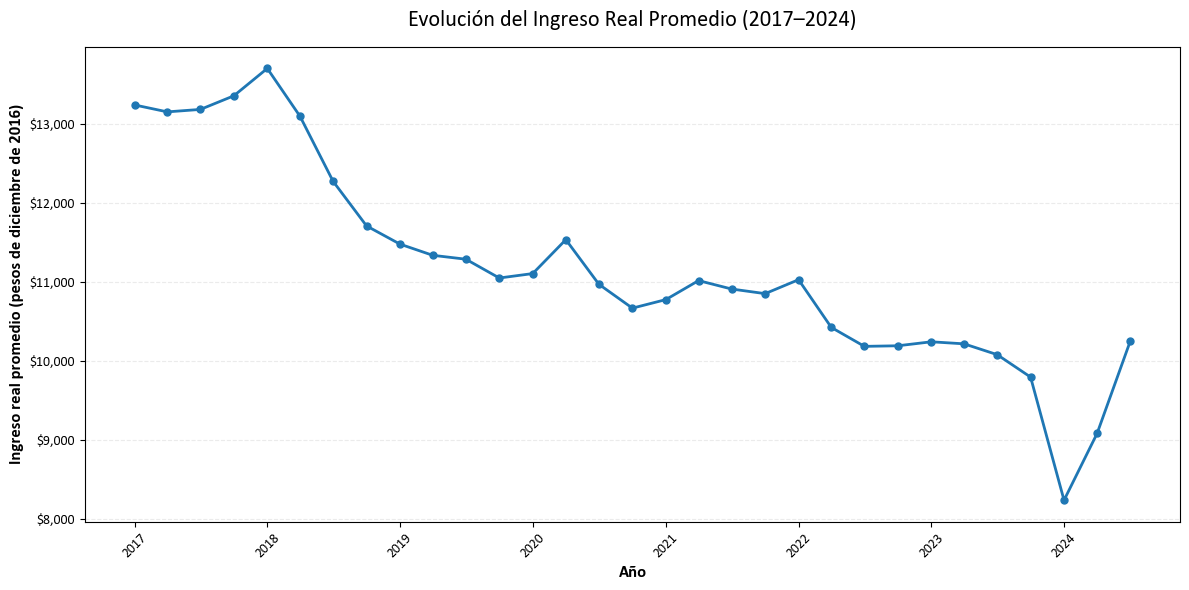

In [159]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# =========================================================
# 1. IPC TRIMESTRAL OFICIAL — INDEC
#    Base: diciembre 2016 = 100
#    Período: 2017–2024
# =========================================================

df_ipc_trim = pd.DataFrame({

    'ANO4': [
        2017, 2017, 2017, 2017,
        2018, 2018, 2018, 2018,
        2019, 2019, 2019, 2019,
        2020, 2020, 2020, 2020,
        2021, 2021, 2021, 2021,
        2022, 2022, 2022, 2022,
        2023, 2023, 2023, 2023,
        2024, 2024, 2024, 2024
    ],

    'TRIMESTRE': [
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4,
        1, 2, 3, 4
    ],

    'IPC_Trimestral': [
        103.8065, 110.4482, 115.5797, 121.7141,
        130.0516, 140.3819, 156.5461, 179.3471,
        197.4391, 219.3859, 241.2706, 272.9087,
        297.0158, 315.6689, 337.2951, 372.1869,
        417.7441, 468.6601, 512.3299, 563.4854,
        638.1741, 754.3716, 910.0667, 1080.8574,
        1288.9494, 1606.8052, 2055.7637, 2948.5093,
        4814.8045, 6085.2194, 6871.1437, 7499.7977
    ]
})

# =========================================================
# 2. CALCULAR FACTOR DE DEFLACTACIÓN
#    Base: diciembre 2016 = 100
# =========================================================

df_ipc_trim['Factor_Deflactacion'] = (
    100 / df_ipc_trim['IPC_Trimestral']
)

# =========================================================
# 3. LIMPIAR VARIABLES IPC ANTERIORES DE LA EPH
# =========================================================

columnas_ipc = [
    'IPC',
    'IPC_Trimestral',
    'Factor_Deflactacion',
    'Factor_Deflactor',
    'Año',
    'Trimestre'
]

df_informal = df_informal.drop(
    columns=[
        col for col in columnas_ipc
        if col in df_informal.columns
    ],
    errors='ignore'
).copy()

# =========================================================
# 4. ASEGURAR TIPO DE VARIABLES
# =========================================================

df_informal['ANO4'] = pd.to_numeric(
    df_informal['ANO4'],
    errors='coerce'
)

df_informal['TRIMESTRE'] = pd.to_numeric(
    df_informal['TRIMESTRE'],
    errors='coerce'
)

df_informal['Ingreso Principal'] = pd.to_numeric(
    df_informal['Ingreso Principal'],
    errors='coerce'
)

df_informal['PONDIIO'] = pd.to_numeric(
    df_informal['PONDIIO'],
    errors='coerce'
)

# =========================================================
# 5. RESTRINGIR AL PERÍODO DE ANÁLISIS
#    2017–2024
# =========================================================

df_informal = df_informal[
    (df_informal['ANO4'] >= 2017) &
    (df_informal['ANO4'] <= 2024)
].copy()

# =========================================================
# 6. MERGE LIMPIO CON IPC
# =========================================================

df_deflactado = df_informal.merge(
    df_ipc_trim,
    on=['ANO4', 'TRIMESTRE'],
    how='left',
    validate='many_to_one'
)

# =========================================================
# 7. CONTROLES DEL MERGE
# =========================================================

print("============================================")
print("CONTROL IPC - EPH")
print("============================================")

print("Observaciones:", len(df_deflactado))

print(
    "IPC faltante:",
    df_deflactado['IPC_Trimestral'].isna().sum()
)

print(
    "Factor faltante:",
    df_deflactado['Factor_Deflactacion'].isna().sum()
)

print(
    "Duplicados Año-Trimestre en IPC:",
    df_ipc_trim.duplicated(
        ['ANO4', 'TRIMESTRE']
    ).sum()
)

# =========================================================
# 8. INGRESO REAL
# =========================================================

df_deflactado['Ingreso_Real'] = (
    df_deflactado['Ingreso Principal']
    * df_deflactado['Factor_Deflactacion']
)

print(
    "Ingreso real faltante:",
    df_deflactado['Ingreso_Real'].isna().sum()
)

# =========================================================
# 9. FECHA TRIMESTRAL
# =========================================================

df_deflactado['Fecha'] = pd.PeriodIndex(
    year=df_deflactado['ANO4'].astype(int),
    quarter=df_deflactado['TRIMESTRE'].astype(int)
).to_timestamp()

## =========================================================
# 10. INGRESO REAL PROMEDIO TRIMESTRAL PONDERADO
#     Ponderación: PONDIIO
# =========================================================

# Numerador: ingreso real × factor de expansión
df_deflactado['Ingreso_Real_Ponderado'] = (
    df_deflactado['Ingreso_Real']
    * df_deflactado['PONDIIO']
)

# Agregación trimestral
df_agg = (
    df_deflactado
    .groupby(
        ['ANO4', 'TRIMESTRE', 'Fecha'],
        as_index=False
    )
    .agg(
        Suma_Ingreso_Ponderado=(
            'Ingreso_Real_Ponderado',
            'sum'
        ),
        Suma_PONDIIO=(
            'PONDIIO',
            'sum'
        )
    )
)

# Promedio real ponderado
df_agg['Ingreso_Real_Ponderado'] = (
    df_agg['Suma_Ingreso_Ponderado']
    / df_agg['Suma_PONDIIO']
)

# =========================================================
# 11. CONTROL
# =========================================================

print("\n============================================")
print("INGRESO REAL PROMEDIO PONDERADO")
print("============================================")

print(
    df_agg[
        ['ANO4', 'TRIMESTRE', 'Ingreso_Real_Ponderado']
    ]
    .round(2)
    .to_string(index=False)
)

# =========================================================
# 12. GRÁFICO
# =========================================================

plt.rcParams['font.family'] = 'Calibri'

plt.figure(figsize=(12, 6))

plt.plot(
    df_agg['Fecha'],
    df_agg['Ingreso_Real_Ponderado'],
    marker='o',
    markersize=5,
    linewidth=2
)

plt.title(
    'Evolución del Ingreso Real Promedio (2017–2024)',
    fontsize=16,
    pad=15
)

plt.xlabel(
    'Año',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Ingreso real promedio (pesos de diciembre de 2016)',
    fontsize=12,
    fontweight='bold'
)

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [160]:
df_deflactado['Empleo formal'] = (
    df_deflactado['Descuento jubilatorio']
    .str.strip()
    .str.upper()
    .eq('SI')
    .astype(int)
)

df_deflactado['Empleo informal'] = (
    1 - df_deflactado['Empleo formal']
)

In [161]:
df_deflactado.head(10)

,ANO4,TRIMESTRE,Region,AGLOMERADO,Estado,Nivel Educativo,Sexo,Edad,Nacionalidad,Maximo Nivel Educativo,...,Tamaño_Empresa,Tamaño_Establecimiento,Condición laboral,IPC_Trimestral,Factor_Deflactacion,Ingreso_Real,Fecha,Ingreso_Real_Ponderado,Empleo formal,Empleo informal
0,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,Microempresa,4,Empleo informal,103.8065,0.9633,1444.9962,2017-01-01,2706477.9180,0,1
1,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,Empresa_Mediana,7,Empleo formal,103.8065,0.9633,9151.6427,2017-01-01,7550105.2439,0,1
2,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,59,En esta localidad,7,...,Microempresa,3,Empleo informal,103.8065,0.9633,13486.6314,2017-01-01,23480225.2267,0,1
3,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,41,En esta localidad,6,...,Empresa_Mediana,8,Empleo formal,103.8065,0.9633,8669.9773,2017-01-01,8721997.1774,0,1
4,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,47,En esta localidad,4,...,Empresa_Mediana,8,Empleo formal,103.8065,0.9633,14449.9622,2017-01-01,15851608.5216,0,1
5,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,54,En esta localidad,4,...,Empresa_Mediana,7,Empleo formal,103.8065,0.9633,5779.9849,2017-01-01,5334926.0403,0,1
6,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,25,En esta localidad,7,...,Empresa_Mediana,7,Empleo formal,103.8065,0.9633,10596.6389,2017-01-01,10246949.8538,0,1
7,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario incompleto,Varón,22,En esta localidad,4,...,Microempresa,2,Empleo informal,103.8065,0.9633,3853.3233,2017-01-01,3483404.2184,0,1
8,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,27,En esta localidad,2,...,Empresa_Mediana,7,Empleo informal,103.8065,0.9633,9633.3081,2017-01-01,10066806.9919,0,1
9,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,38,En otra provincia,2,...,Microempresa,6,Empleo informal,103.8065,0.9633,4816.6541,2017-01-01,6338716.7470,0,1


In [162]:
df_deflactado.columns

Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel Educativo', 'Sexo', 'Edad', 'Nacionalidad',
       'Maximo Nivel Educativo', 'Finalizo Nivel', 'Ultimo Año Aprobado',
       'Nacionalidad', 'PONDERA', 'PONDIIO', 'Categoria Ocupacional',
       'Categoria Inactividad', 'Tiempo Trabajado', 'Horas trabajadas',
       'Tipo_empleador', 'Descuento jubilatorio', 'Tamaño Establecimiento',
       'Años Educacion', 'Experiencia Potencial',
       'Experiencia Potencial Cuadrado', 'Ingreso Principal', 'ITF',
       'Provincia', 'Tamaño_Empresa', 'Tamaño_Establecimiento',
       'Condición laboral', 'IPC_Trimestral', 'Factor_Deflactacion',
       'Ingreso_Real', 'Fecha', 'Ingreso_Real_Ponderado', 'Empleo formal',
       'Empleo informal'],
      dtype='object')

In [163]:
df_deflactado = df_deflactado.dropna(subset=['Condición laboral'])

df_deflactado['Fecha'] = pd.PeriodIndex(
    year=df_deflactado['ANO4'],
    quarter=df_deflactado['TRIMESTRE']
).to_timestamp()

df_plot = (
    df_deflactado
    .groupby(['Fecha','Condición laboral'])['Ingreso_Real']
    .mean()
    .reset_index()
)

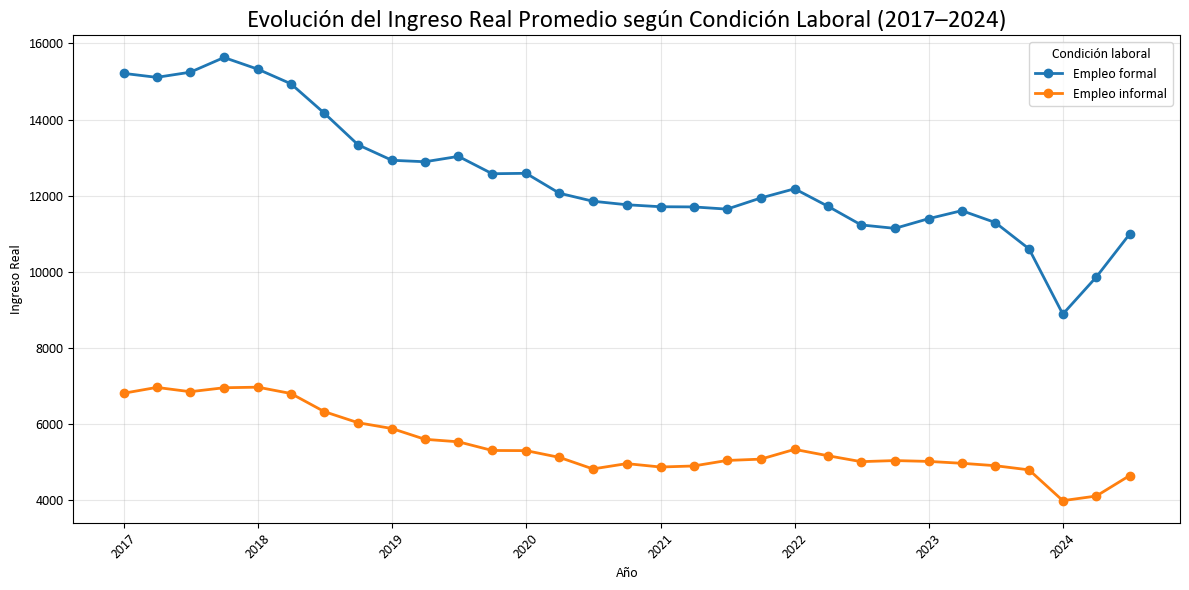

In [164]:
plt.figure(figsize=(12,6))

for key, grp in df_plot.groupby('Condición laboral'):
    plt.plot(
        grp['Fecha'],
        grp['Ingreso_Real'],
        marker='o',
        linewidth=2,
        label=key
    )

#plt.title('Ingreso Real Promedio por Condición laboral (2017–2024)', fontsize=14)
plt.title(
    'Evolución del Ingreso Real Promedio según Condición Laboral (2017–2024)',
    fontsize=18
)
plt.xlabel('Año')
plt.ylabel('Ingreso Real')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(title='Condición laboral')
plt.tight_layout()
plt.show()

In [165]:
print(df_deflactado['Condición laboral'].value_counts(dropna=False))
print(df_deflactado['Condición laboral'].dtype)

Empleo formal      217983
Empleo informal     93198
Name: Condición laboral, dtype: int64
category


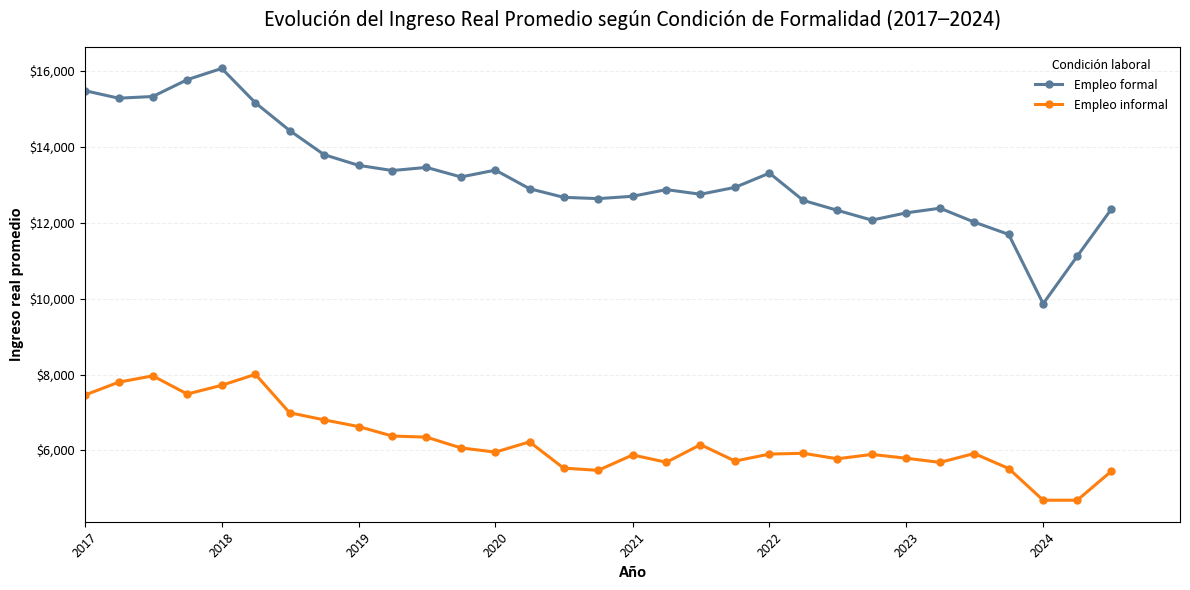

In [166]:
# =========================================================
# EVOLUCIÓN DEL INGRESO REAL SEGÚN CONDICIÓN DE FORMALIDAD
# 2017–2024
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


# =========================================================
# 1. FECHA TRIMESTRAL
# =========================================================

df_deflactado['Fecha'] = pd.PeriodIndex(
    year=df_deflactado['ANO4'].astype(int),
    quarter=df_deflactado['TRIMESTRE'].astype(int)
).to_timestamp()


# =========================================================
# 2. INGRESO REAL PONDERADO
# =========================================================

df_deflactado['Ingreso_Real_Ponderado'] = (
    df_deflactado['Ingreso_Real']
    * df_deflactado['PONDIIO']
)


# =========================================================
# 3. PROMEDIO PONDERADO POR TRIMESTRE
# =========================================================

df_plot = (
    df_deflactado
    .groupby(
        ['Fecha', 'Condición laboral'],
        as_index=False
    )
    .agg(
        Suma_Ingreso_Real=(
            'Ingreso_Real_Ponderado',
            'sum'
        ),
        Suma_PONDIIO=(
            'PONDIIO',
            'sum'
        )
    )
)


# =========================================================
# 4. CALCULAR INGRESO REAL PROMEDIO
# =========================================================

df_plot['Ingreso_Real_Promedio'] = (
    df_plot['Suma_Ingreso_Real']
    / df_plot['Suma_PONDIIO']
)

df_plot = df_plot.sort_values('Fecha')


# =========================================================
# 5. CONFIGURACIÓN DEL GRÁFICO
# =========================================================

plt.rcParams['font.family'] = 'Calibri'

palette = {
    'Empleo formal': '#5B7C99',
    'Empleo informal': '#FF7F0E'
}

plt.figure(figsize=(12, 6))


# =========================================================
# 6. GRAFICAR
# =========================================================

for condicion, grupo in df_plot.groupby('Condición laboral'):

    grupo = grupo.sort_values('Fecha')

    plt.plot(
        grupo['Fecha'],
        grupo['Ingreso_Real_Promedio'],
        marker='o',
        markersize=5,
        linewidth=2.2,
        color=palette[condicion],
        label=condicion
    )


# =========================================================
# 7. TÍTULO
# =========================================================

plt.title(
    'Evolución del Ingreso Real Promedio según Condición de Formalidad (2017–2024)',
    fontsize=16,
    pad=15
)


# =========================================================
# 8. EJES
# =========================================================

plt.xlabel(
    'Año',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Ingreso real promedio',
    fontsize=12,
    fontweight='bold'
)


# =========================================================
# 9. FORMATO MONETARIO
# =========================================================

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)


# =========================================================
# 10. RESTRINGIR AL PERÍODO DE ANÁLISIS
# =========================================================

plt.xlim(
    pd.Timestamp('2017-01-01'),
    pd.Timestamp('2024-12-31')
)


# =========================================================
# 11. ESTÉTICA
# =========================================================

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.20
)

plt.xticks(rotation=45)

plt.legend(
    title='Condición laboral',
    frameon=False
)

plt.tight_layout()

plt.show()

### Gráfico: "Evolución del Ingreso Real"

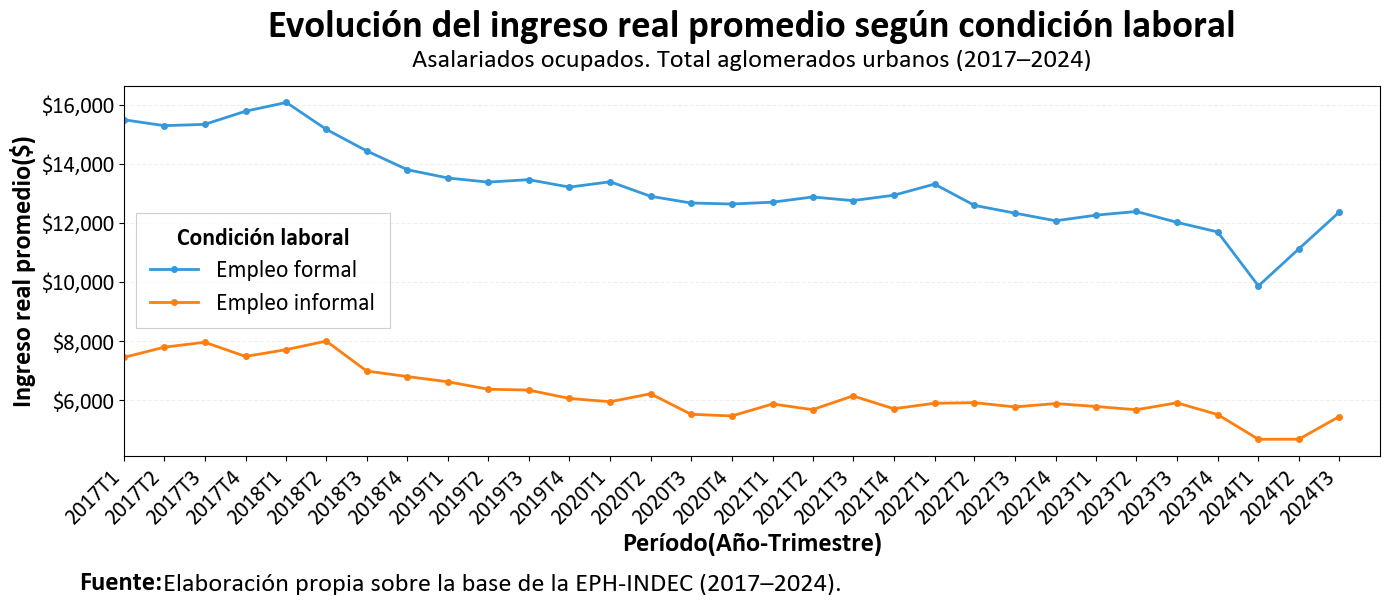

In [61]:
# =========================================================
# EVOLUCIÓN TRIMESTRAL DEL INGRESO REAL
# SEGÚN CONDICIÓN DE FORMALIDAD — 2017–2024
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


# =========================================================
# 1. FECHA TRIMESTRAL
# =========================================================

df_deflactado['Fecha'] = pd.to_datetime(
    df_deflactado['ANO4'].astype(str)
    + '-'
    + ((df_deflactado['TRIMESTRE'].astype(int) - 1) * 3 + 1).astype(str)
    + '-01'
)


# =========================================================
# 2. INGRESO REAL PONDERADO
# =========================================================

df_deflactado['Ingreso_Real_Ponderado'] = (
    df_deflactado['Ingreso_Real']
    * df_deflactado['PONDIIO']
)


# =========================================================
# 3. PROMEDIO PONDERADO POR TRIMESTRE
#    Y CONDICIÓN DE FORMALIDAD
# =========================================================

df_plot = (
    df_deflactado
    .groupby(
        ['Fecha', 'Condición laboral'],
        as_index=False
    )
    .agg(
        Suma_Ingreso_Real=(
            'Ingreso_Real_Ponderado',
            'sum'
        ),
        Suma_PONDIIO=(
            'PONDIIO',
            'sum'
        )
    )
)


# =========================================================
# 4. CALCULAR INGRESO REAL PROMEDIO
# =========================================================

df_plot['Ingreso_Real_Promedio'] = (
    df_plot['Suma_Ingreso_Real']
    / df_plot['Suma_PONDIIO']
)

df_plot = df_plot.sort_values('Fecha')


# =========================================================
# 5. CONFIGURACIÓN GENERAL
# =========================================================

plt.rcParams['font.family'] = 'Calibri'

palette = {
    'Empleo formal': '#3498DB',
    'Empleo informal': '#FF7F0E'
}

plt.figure(figsize=(14, 6))


# =========================================================
# 6. GRAFICAR LAS DOS SERIES
# =========================================================

for condicion, grupo in df_plot.groupby('Condición laboral'):

    grupo = grupo.sort_values('Fecha')

    plt.plot(
        grupo['Fecha'],
        grupo['Ingreso_Real_Promedio'],
        marker='o',
        markersize=4,
        linewidth=2,
        color=palette.get(condicion),
        label=condicion
    )


# =========================================================
# 7. TÍTULO Y SUBTÍTULO
# =========================================================

plt.title(
    'Evolución del ingreso real promedio según condición laboral',
    fontsize=28,
    pad=35,
    fontname='Calibri',
    fontweight='bold',
    color='black'
)

plt.text(
    0.5,
    1.04,
    'Asalariados ocupados. Total aglomerados urbanos (2017–2024)',
    transform=plt.gca().transAxes,
    ha='center',
    va='bottom',
    fontsize=19,
    fontname='Calibri',
    fontweight='normal',
    color='black'
)


# =========================================================
# 8. NOMBRES DE LOS EJES
# =========================================================

plt.xlabel(
    'Período(Año-Trimestre)',
    fontsize=19,
    fontweight='bold',
    fontname='Calibri',
    color='black'
)

plt.ylabel(
    'Ingreso real promedio($)',
    fontsize=19,
    fontweight='bold',
    fontname='Calibri',
    color='black'
)


# =========================================================
# 9. FORMATO MONETARIO DEL EJE Y
# =========================================================

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)


# =========================================================
# 10. ETIQUETAS TRIMESTRALES DEL EJE X
# =========================================================

fechas = sorted(
    df_plot['Fecha'].unique()
)

etiquetas = [
    f"{pd.Timestamp(fecha).year}T{pd.Timestamp(fecha).quarter}"
    for fecha in fechas
]

plt.xticks(
    fechas,
    etiquetas,
    rotation=45,
    ha='right',
    fontsize=16,
    fontname='Calibri',
    fontweight='normal',
    color='black'
)


# =========================================================
# 11. NÚMEROS DEL EJE Y
# =========================================================

plt.yticks(
    fontsize=16,
    fontname='Calibri',
    fontweight='normal',
    color='black'
)


# =========================================================
# 12. RESTRINGIR AL PERÍODO DE ANÁLISIS
# =========================================================

plt.xlim(
    pd.Timestamp('2017-01-01'),
    pd.Timestamp('2024-10-01')
)


# =========================================================
# 13. GRILLA
# =========================================================

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.20
)


# =========================================================
# 14. LEYENDA
# =========================================================

leg = plt.legend(
    title='Condición laboral',
    frameon=True,
    facecolor='white',
    edgecolor='#BFBFBF',
    framealpha=0.75,
    fancybox=False,
    borderpad=0.6,
    prop={
        'family': 'Calibri',
        'size': 17,
        'weight': 'normal'
    }
)

# Título de la leyenda
plt.setp(
    leg.get_title(),
    family='Calibri',
    fontsize=17,
    fontweight='bold',
    color='black'
)

# Borde sutil
leg.get_frame().set_linewidth(0.8)


# =========================================================
# 15. FUENTE
# =========================================================

plt.figtext(
    0.06,
    0.00,
    'Fuente:',
    ha='left',
    va='bottom',
    fontsize=19,
    fontname='Calibri',
    fontweight='bold',
    color='black'
)

plt.figtext(
    0.116,
    0.00,
    ' Elaboración propia sobre la base de la EPH-INDEC (2017–2024).',
    ha='left',
    va='bottom',
    fontsize=19,
    fontname='Calibri',
    fontweight='normal',
    color='black'
)


# =========================================================
# 16. AJUSTE FINAL
# =========================================================

plt.tight_layout(
    rect=[0, 0.04, 1, 1]
)

plt.show()

In [62]:
print(df_deflactado['Condición laboral'].unique())

['Empleo informal', 'Empleo formal']
Categories (2, object): ['Empleo formal', 'Empleo informal']


In [63]:
print(df_deflactado['Condición laboral'].value_counts(dropna=False))


Empleo formal      217983
Empleo informal     93198
Name: Condición laboral, dtype: int64


In [64]:
df_deflactado = df_deflactado.dropna(subset=['Condición laboral'])

In [65]:
print(df_informal['Descuento jubilatorio'].value_counts())

Sí    217983
No     93198
Name: Descuento jubilatorio, dtype: int64


In [66]:
df_deflactado.head(10)

,ANO4,TRIMESTRE,Region,AGLOMERADO,Estado,Nivel Educativo,Sexo,Edad,Nacionalidad,Maximo Nivel Educativo,...,Tamaño_Empresa,Tamaño_Establecimiento,Condición laboral,IPC_Trimestral,Factor_Deflactacion,Ingreso_Real,Fecha,Ingreso_Real_Ponderado,Empleo formal,Empleo informal
0,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,Microempresa,4,Empleo informal,103.8065,0.9633,1444.9962,2017-01-01,2706477.9180,0,1
1,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,Empresa_Mediana,7,Empleo formal,103.8065,0.9633,9151.6427,2017-01-01,7550105.2439,0,1
2,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,59,En esta localidad,7,...,Microempresa,3,Empleo informal,103.8065,0.9633,13486.6314,2017-01-01,23480225.2267,0,1
3,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,41,En esta localidad,6,...,Empresa_Mediana,8,Empleo formal,103.8065,0.9633,8669.9773,2017-01-01,8721997.1774,0,1
4,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,47,En esta localidad,4,...,Empresa_Mediana,8,Empleo formal,103.8065,0.9633,14449.9622,2017-01-01,15851608.5216,0,1
5,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,54,En esta localidad,4,...,Empresa_Mediana,7,Empleo formal,103.8065,0.9633,5779.9849,2017-01-01,5334926.0403,0,1
6,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,25,En esta localidad,7,...,Empresa_Mediana,7,Empleo formal,103.8065,0.9633,10596.6389,2017-01-01,10246949.8538,0,1
7,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario incompleto,Varón,22,En esta localidad,4,...,Microempresa,2,Empleo informal,103.8065,0.9633,3853.3233,2017-01-01,3483404.2184,0,1
8,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,27,En esta localidad,2,...,Empresa_Mediana,7,Empleo informal,103.8065,0.9633,9633.3081,2017-01-01,10066806.9919,0,1
9,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,38,En otra provincia,2,...,Microempresa,6,Empleo informal,103.8065,0.9633,4816.6541,2017-01-01,6338716.7470,0,1


In [67]:
df_deflactado['Nivel Educativo'].value_counts()

Secundario completo         95909
Universitario completo      82760
Secundario incompleto       48539
Universitario incompleto    45587
Primario completo           30576
Primario incompleto          7143
Sin instrucción               667
Name: Nivel Educativo, dtype: int64

In [68]:
print(df_deflactado.columns)

Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel Educativo', 'Sexo', 'Edad', 'Nacionalidad',
       'Maximo Nivel Educativo', 'Finalizo Nivel', 'Ultimo Año Aprobado',
       'Nacionalidad', 'PONDERA', 'PONDIIO', 'Categoria Ocupacional',
       'Categoria Inactividad', 'Tiempo Trabajado', 'Horas trabajadas',
       'Tipo_empleador', 'Descuento jubilatorio', 'Tamaño Establecimiento',
       'Años Educacion', 'Experiencia Potencial',
       'Experiencia Potencial Cuadrado', 'Ingreso Principal', 'ITF',
       'Provincia', 'Tamaño_Empresa', 'Tamaño_Establecimiento',
       'Condición laboral', 'IPC_Trimestral', 'Factor_Deflactacion',
       'Ingreso_Real', 'Fecha', 'Ingreso_Real_Ponderado', 'Empleo formal',
       'Empleo informal'],
      dtype='object')


In [69]:
df_deflactado['Estado'].value_counts()

Ocupado    311181
Name: Estado, dtype: int64

# Contrucción salario por hora

In [70]:
### Te permite interpretar los coeficientes como efectos porcentuales en la cual es estandar en los estudiso de capital humano.

In [71]:
### PONDIIO: Refleja que las estimaciones reflejen poblacion objetivo, no solo la muestra.

In [188]:
import numpy as np
import pandas as pd

# -------------------------------
# 1️⃣ Convertir horas trabajadas a numérico
# -------------------------------
df_deflactado['Horas trabajadas'] = pd.to_numeric(
    df_deflactado['Horas trabajadas'], errors='coerce'
)

# -------------------------------
# 2️⃣ Calcular horas mensuales (4.33 semanas promedio)
# -------------------------------
df_deflactado['Horas_mes'] = df_deflactado['Horas trabajadas'] * 4.33

# -------------------------------
# 3️⃣ Filtrar observaciones inválidas
#    - Horas = 0 o >350
#    - Ingreso <=0
# -------------------------------
df_deflactado = df_deflactado[
    (df_deflactado['Horas_mes'] > 0) &
    (df_deflactado['Horas_mes'] < 350) &
    (df_deflactado['Ingreso_Real'] > 0)
].copy()

# -------------------------------
# 4️⃣ Calcular salario real por hora
# -------------------------------
df_deflactado['Salario_hora_real'] = df_deflactado['Ingreso_Real'] / df_deflactado['Horas_mes']

# -------------------------------
# 5️⃣ Winsorizar salarios extremos (1%-99%)
# -------------------------------
lower = df_deflactado['Salario_hora_real'].quantile(0.01)
upper = df_deflactado['Salario_hora_real'].quantile(0.99)
df_deflactado['Salario_hora_real_w'] = df_deflactado['Salario_hora_real'].clip(lower, upper)

# -------------------------------
# 6️⃣ Logaritmo del salario truncado
# -------------------------------
df_deflactado['log_salario_hora'] = np.log(df_deflactado['Salario_hora_real_w'])



# -------------------------------
# 10️⃣ Verificación final
# -------------------------------
print("Observaciones finales:", len(df_deflactado))
print("Log salario hora: min {:.2f}, max {:.2f}".format(
    df_deflactado['log_salario_hora'].min(),
    df_deflactado['log_salario_hora'].max()
))


Observaciones finales: 287547
Log salario hora: min 2.29, max 5.56


In [189]:
df_mincer = df_deflactado[
    (df_deflactado['Estado'] == 'Ocupado') &
    (df_deflactado['Categoria Ocupacional'] == 'Obrero o empleado')
].copy()

In [190]:
df_deflactado.head(10)

,ANO4,TRIMESTRE,Region,AGLOMERADO,Estado,Nivel Educativo,Sexo,Edad,Nacionalidad,Maximo Nivel Educativo,...,Factor_Deflactacion,Ingreso_Real,Fecha,Ingreso_Real_Ponderado,Empleo formal,Empleo informal,Horas_mes,Salario_hora_real,Salario_hora_real_w,log_salario_hora
0,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,0.9633,1444.9962,2017-01-01,2706477.9180,0,1,207.8400,6.9524,9.8323,2.2857
1,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,0.9633,9151.6427,2017-01-01,7550105.2439,0,1,129.9000,70.4514,70.4514,4.2549
4,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,47,En esta localidad,4,...,0.9633,14449.9622,2017-01-01,15851608.5216,0,1,173.2000,83.4293,83.4293,4.4240
5,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,54,En esta localidad,4,...,0.9633,5779.9849,2017-01-01,5334926.0403,0,1,173.2000,33.3717,33.3717,3.5077
6,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,25,En esta localidad,7,...,0.9633,10596.6389,2017-01-01,10246949.8538,0,1,173.2000,61.1815,61.1815,4.1138
7,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario incompleto,Varón,22,En esta localidad,4,...,0.9633,3853.3233,2017-01-01,3483404.2184,0,1,173.2000,22.2478,22.2478,3.1022
8,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,27,En esta localidad,2,...,0.9633,9633.3081,2017-01-01,10066806.9919,0,1,303.1000,31.7826,31.7826,3.4589
9,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,38,En otra provincia,2,...,0.9633,4816.6541,2017-01-01,6338716.7470,0,1,194.8500,24.7198,24.7198,3.2076
10,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Mujer,36,En país limítrofe,2,...,0.9633,2889.9924,2017-01-01,4381228.5358,0,1,173.2000,16.6859,16.6859,2.8146
11,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario incompleto,Varón,53,En otra provincia,3,...,0.9633,48166.5406,2017-01-01,107315052.5256,0,1,233.8200,205.9984,205.9984,5.3279


In [191]:

df_asalariados=df_deflactado.copy()

In [192]:
df_asalariados.head(10)

,ANO4,TRIMESTRE,Region,AGLOMERADO,Estado,Nivel Educativo,Sexo,Edad,Nacionalidad,Maximo Nivel Educativo,...,Factor_Deflactacion,Ingreso_Real,Fecha,Ingreso_Real_Ponderado,Empleo formal,Empleo informal,Horas_mes,Salario_hora_real,Salario_hora_real_w,log_salario_hora
0,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,0.9633,1444.9962,2017-01-01,2706477.9180,0,1,207.8400,6.9524,9.8323,2.2857
1,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,0.9633,9151.6427,2017-01-01,7550105.2439,0,1,129.9000,70.4514,70.4514,4.2549
4,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,47,En esta localidad,4,...,0.9633,14449.9622,2017-01-01,15851608.5216,0,1,173.2000,83.4293,83.4293,4.4240
5,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,54,En esta localidad,4,...,0.9633,5779.9849,2017-01-01,5334926.0403,0,1,173.2000,33.3717,33.3717,3.5077
6,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,25,En esta localidad,7,...,0.9633,10596.6389,2017-01-01,10246949.8538,0,1,173.2000,61.1815,61.1815,4.1138
7,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario incompleto,Varón,22,En esta localidad,4,...,0.9633,3853.3233,2017-01-01,3483404.2184,0,1,173.2000,22.2478,22.2478,3.1022
8,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,27,En esta localidad,2,...,0.9633,9633.3081,2017-01-01,10066806.9919,0,1,303.1000,31.7826,31.7826,3.4589
9,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,38,En otra provincia,2,...,0.9633,4816.6541,2017-01-01,6338716.7470,0,1,194.8500,24.7198,24.7198,3.2076
10,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Mujer,36,En país limítrofe,2,...,0.9633,2889.9924,2017-01-01,4381228.5358,0,1,173.2000,16.6859,16.6859,2.8146
11,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario incompleto,Varón,53,En otra provincia,3,...,0.9633,48166.5406,2017-01-01,107315052.5256,0,1,233.8200,205.9984,205.9984,5.3279


In [193]:
df_asalariados.columns

Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel Educativo', 'Sexo', 'Edad', 'Nacionalidad',
       'Maximo Nivel Educativo', 'Finalizo Nivel', 'Ultimo Año Aprobado',
       'Nacionalidad', 'PONDERA', 'PONDIIO', 'Categoria Ocupacional',
       'Categoria Inactividad', 'Tiempo Trabajado', 'Horas trabajadas',
       'Tipo_empleador', 'Descuento jubilatorio', 'Tamaño Establecimiento',
       'Años Educacion', 'Experiencia Potencial',
       'Experiencia Potencial Cuadrado', 'Ingreso Principal', 'ITF',
       'Provincia', 'Tamaño_Empresa', 'Tamaño_Establecimiento',
       'Condición laboral', 'IPC_Trimestral', 'Factor_Deflactacion',
       'Ingreso_Real', 'Fecha', 'Ingreso_Real_Ponderado', 'Empleo formal',
       'Empleo informal', 'Horas_mes', 'Salario_hora_real',
       'Salario_hora_real_w', 'log_salario_hora'],
      dtype='object')

In [194]:
df_asalariados['ANO4'].value_counts()

2019    43887
2017    42602
2018    42335
2023    36400
2022    36002
2021    33532
2020    26996
2024    25793
Name: ANO4, dtype: int64

In [195]:
df_asalariados['ANO4'] = df_asalariados['ANO4'].astype(int)

In [184]:
# =========================================================
# CREAR VARIABLE AÑO A PARTIR DE ANO4
# =========================================================

df_asalariados['Año'] = pd.to_numeric(
    df_asalariados['ANO4'],
    errors='coerce'
).astype('Int64')

print(df_asalariados['Año'].value_counts().sort_index())

2017    45473
2018    45191
2019    46867
2020    32270
2021    36575
2022    38412
2023    38702
2024    27691
Name: Año, dtype: Int64


In [196]:
df_asalariados.columns


Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel Educativo', 'Sexo', 'Edad', 'Nacionalidad',
       'Maximo Nivel Educativo', 'Finalizo Nivel', 'Ultimo Año Aprobado',
       'Nacionalidad', 'PONDERA', 'PONDIIO', 'Categoria Ocupacional',
       'Categoria Inactividad', 'Tiempo Trabajado', 'Horas trabajadas',
       'Tipo_empleador', 'Descuento jubilatorio', 'Tamaño Establecimiento',
       'Años Educacion', 'Experiencia Potencial',
       'Experiencia Potencial Cuadrado', 'Ingreso Principal', 'ITF',
       'Provincia', 'Tamaño_Empresa', 'Tamaño_Establecimiento',
       'Condición laboral', 'IPC_Trimestral', 'Factor_Deflactacion',
       'Ingreso_Real', 'Fecha', 'Ingreso_Real_Ponderado', 'Empleo formal',
       'Empleo informal', 'Horas_mes', 'Salario_hora_real',
       'Salario_hora_real_w', 'log_salario_hora'],
      dtype='object')

In [220]:
df_asalariados = df_asalariados.rename(
    columns={'ANO4': 'Año'}
)

# MODELO EMPIRICO

## Variables seleccionadas del modelo

In [221]:
# ==========================================
# Seleccionar variables para el modelo
# ==========================================

variables_modelo = [
    'log_salario_hora',                 # Variable dependiente
    'Nivel Educativo',                  # Capital humano
    'Experiencia Potencial',
    'Experiencia Potencial Cuadrado',
    'Condición laboral',             # Formal / Informal
    'Tamaño_Empresa',
    'Tipo_empleador',                   # Público / Privado
    'Sexo',
    'Region',
    'Año',
    'PONDIIO'                           # Peso muestral
]

# ==========================================
# Crear DataFrame del modelo
# ==========================================

df_modelo = df_asalariados[variables_modelo].copy()

# ==========================================
# Eliminar valores faltantes
# ==========================================

df_modelo = df_modelo.dropna().copy()

# ==========================================
# Verificación
# ==========================================

print(df_modelo.head())

print("\nCantidad de observaciones:")
print(len(df_modelo))

print("\nVariables:")
print(df_modelo.columns.tolist())

   log_salario_hora         Nivel Educativo  Experiencia Potencial  \
0            2.2857       Primario completo                      7   
1            4.2549     Secundario completo                     46   
4            4.4240     Secundario completo                     29   
5            3.5077     Secundario completo                     36   
6            4.1138  Universitario completo                      2   

   Experiencia Potencial Cuadrado Condición laboral   Tamaño_Empresa  \
0                              49   Empleo informal     Microempresa   
1                            2116     Empleo formal  Empresa_Mediana   
4                             841     Empleo formal  Empresa_Mediana   
5                            1296     Empleo formal  Empresa_Mediana   
6                               4     Empleo formal  Empresa_Mediana   

  Tipo_empleador   Sexo    Region   Año   PONDIIO  
0        Privada  Varón  Pampeana  2017 1873.0000  
1        Estatal  Mujer  Pampeana  2017  8

In [222]:
[c for c in df_asalariados.columns if 'Experiencia' in c]

['Experiencia Potencial', 'Experiencia Potencial Cuadrado']

In [223]:
df_modelo.head(10)

,log_salario_hora,Nivel Educativo,Experiencia Potencial,Experiencia Potencial Cuadrado,Condición laboral,Tamaño_Empresa,Tipo_empleador,Sexo,Region,Año,PONDIIO
0,2.2857,Primario completo,7,49,Empleo informal,Microempresa,Privada,Varón,Pampeana,2017,1873.0000
1,4.2549,Secundario completo,46,2116,Empleo formal,Empresa_Mediana,Estatal,Mujer,Pampeana,2017,825.0000
4,4.4240,Secundario completo,29,841,Empleo formal,Empresa_Mediana,Privada,Mujer,Pampeana,2017,1097.0000
5,3.5077,Secundario completo,36,1296,Empleo formal,Empresa_Mediana,Privada,Mujer,Pampeana,2017,923.0000
6,4.1138,Universitario completo,2,4,Empleo formal,Empresa_Mediana,Estatal,Mujer,Pampeana,2017,967.0000
7,3.1022,Secundario incompleto,6,36,Empleo informal,Microempresa,Privada,Varón,Pampeana,2017,904.0000
8,3.4589,Primario completo,14,196,Empleo informal,Empresa_Mediana,Privada,Varón,Pampeana,2017,1045.0000
9,3.2076,Primario completo,25,625,Empleo informal,Microempresa,Privada,Varón,Pampeana,2017,1316.0000
10,2.8146,Primario completo,23,529,Empleo formal,Microempresa,Privada,Mujer,Pampeana,2017,1516.0000
11,5.3279,Secundario incompleto,37,1369,Empleo formal,Empresa_Grande,Privada,Varón,Pampeana,2017,2228.0000


In [208]:
df_modelo = df_modelo[(df_modelo['Año'] >= 2017) & (df_modelo['Año'] <= 2024)]

In [209]:
print("Observaciones en df_modelo:", len(df_modelo))

Observaciones en df_modelo: 287547


In [210]:
df_modelo.columns

Index(['log_salario_hora', 'Nivel Educativo', 'Experiencia Potencial',
       'Experiencia Potencial Cuadrado', 'Condición laboral', 'Tamaño_Empresa',
       'Tipo_empleador', 'Sexo', 'Region', 'Año', 'PONDIIO'],
      dtype='object')

In [211]:
df_modelo.columns.tolist()

['log_salario_hora',
 'Nivel Educativo',
 'Experiencia Potencial',
 'Experiencia Potencial Cuadrado',
 'Condición laboral',
 'Tamaño_Empresa',
 'Tipo_empleador',
 'Sexo',
 'Region',
 'Año',
 'PONDIIO']

In [212]:
df_modelo["Nivel Educativo"].value_counts(dropna=False)

Secundario completo         89544
Universitario completo      74364
Secundario incompleto       45439
Universitario incompleto    42523
Primario completo           28381
Primario incompleto          6677
Sin instrucción               619
Name: Nivel Educativo, dtype: int64

In [ ]:
df_modelo["Condición laboral"].value_counts(dropna=False)

Empleo formal      197916
Empleo informal     89631
Name: Condición laboral, dtype: int64

## Modelo de regresión estimada (WLS)+(Efectos fijos)

In [ ]:
### Objetivo: Estimar como esas variables dependientes afectan los salarios horarios en Argentina,
#considerando ponderadores de la muestra.

In [213]:
df_modelo.columns

Index(['log_salario_hora', 'Nivel Educativo', 'Experiencia Potencial',
       'Experiencia Potencial Cuadrado', 'Condición laboral', 'Tamaño_Empresa',
       'Tipo_empleador', 'Sexo', 'Region', 'Año', 'PONDIIO'],
      dtype='object')

In [110]:
df_modelo['Tipo_empleador'].value_counts()

Privada    186404
Estatal    101143
Name: Tipo_empleador, dtype: int64

In [214]:
df_modelo['Año'].value_counts()

2019    43887
2017    42602
2018    42335
2023    36400
2022    36002
2021    33532
2020    26996
2024    25793
Name: Año, dtype: int64

### Modelo 1 Corregido

In [224]:
import pandas as pd
import statsmodels.formula.api as smf
from patsy.contrasts import Treatment

# =====================================================
# FILTRAR PERÍODO 2017-2024
# =====================================================

# Si Año está como categoría, convertir a numérico
df_modelo["Año"] = pd.to_numeric(df_modelo["Año"])

df_modelo = df_modelo[
    df_modelo["Año"].between(2017, 2024)
].copy()

# Verificar
print(sorted(df_modelo["Año"].unique()))

# =====================================================
# ORDENAR NIVEL EDUCATIVO
# =====================================================

orden_educacion = [
    "Primario incompleto",
    "Primario completo",
    "Secundario incompleto",
    "Secundario completo",
    "Universitario incompleto",
    "Universitario completo"
]

df_modelo["Nivel Educativo"] = pd.Categorical(
    df_modelo["Nivel Educativo"],
    categories=orden_educacion,
    ordered=True
)

# =====================================================
# AÑO COMO CATEGORÍA ORDENADA
# =====================================================

orden_anios = [
    2017, 2018, 2019, 2020,
    2021, 2022, 2023, 2024
]

df_modelo["Año"] = pd.Categorical(
    df_modelo["Año"],
    categories=orden_anios,
    ordered=True
)

# =====================================================
# MODELO 1
# =====================================================

modelo_1 = smf.wls(
    formula="""
    log_salario_hora ~

    C(Q("Nivel Educativo"),
      Treatment(reference="Primario incompleto"))

    + Q("Experiencia Potencial")
    + Q("Experiencia Potencial Cuadrado")

    + C(Q("Año"),
        Treatment(reference=2017))
    """,
    data=df_modelo,
    weights=df_modelo["PONDIIO"]
).fit(cov_type="HC1")

print(modelo_1.summary())

# =====================================================
# EXPORTAR RESULTADOS DEL MODELO 1
# =====================================================

tabla_modelo_1 = pd.DataFrame({
    "Coeficiente": modelo_1.params,
    "Error estándar": modelo_1.bse,
    "P-valor": modelo_1.pvalues
})

tabla_modelo_1.to_excel(
    r"D:\repositorios\modelos-segmentacion-laboral\Output\tabla_modelo_1.xlsx"
)

print("Tabla del Modelo 1 guardada correctamente.")

[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
                            WLS Regression Results                            
Dep. Variable:       log_salario_hora   R-squared:                       0.303
Model:                            WLS   Adj. R-squared:                  0.303
Method:                 Least Squares   F-statistic:                     2359.
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        01:31:53   Log-Likelihood:            -3.2591e+05
No. Observations:              286928   AIC:                         6.518e+05
Df Residuals:                  286913   BIC:                         6.520e+05
Df Model:                          14                                         
Covariance Type:                  HC1                                         
                                                                                                      coef    std err          z      P>|z|      [0.025      0.97

### Modelo_2 Corregido

In [227]:
# =====================================================
# MODELO 2
# =====================================================

modelo_2 = smf.wls(
    formula="""
    log_salario_hora ~

    C(Q("Nivel Educativo"),
      Treatment(reference="Primario incompleto"))

    + Q("Experiencia Potencial")
    + Q("Experiencia Potencial Cuadrado")

    + Q("Condición laboral")

    + C(Q("Tamaño_Empresa"))

    + C(Q("Nivel Educativo"),
        Treatment(reference="Primario incompleto"))
      : Q("Condición laboral")

    + C(Q("Nivel Educativo"),
        Treatment(reference="Primario incompleto"))
      : C(Q("Tamaño_Empresa"))

    + C(Q("Año"),
        Treatment(reference=2017))
    """,
    data=df_modelo,
    weights=df_modelo["PONDIIO"]
).fit(cov_type="HC1")

print(modelo_2.summary())

# =====================================================
# EXPORTAR RESULTADOS DEL MODELO 2
# =====================================================

tabla_modelo_2 = pd.DataFrame({
    "Coeficiente": modelo_2.params,
    "Error estándar": modelo_2.bse,
    "P-valor": modelo_2.pvalues
})

tabla_modelo_2.to_excel(
    r"D:\repositorios\modelos-segmentacion-laboral\Output\tabla_modelo_2.xlsx"
)

print("Tabla del Modelo 2 guardada correctamente.")

                            WLS Regression Results                            
Dep. Variable:       log_salario_hora   R-squared:                       0.415
Model:                            WLS   Adj. R-squared:                  0.415
Method:                 Least Squares   F-statistic:                     1586.
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        01:33:41   Log-Likelihood:            -3.0066e+05
No. Observations:              286928   AIC:                         6.014e+05
Df Residuals:                  286895   BIC:                         6.017e+05
Df Model:                          32                                         
Covariance Type:                  HC1                                         
                                                                                                                                                coef    std err          z      P>|z|      [0.025      0.975]
----

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# =====================================================
# ORDEN DE LA VARIABLE EDUCATIVA
# =====================================================

orden_educacion = [
    "Primario incompleto",
    "Primario completo",
    "Secundario incompleto",
    "Secundario completo",
    "Universitario incompleto",
    "Universitario completo"
]

# =====================================================
# AÑO COMO CATEGORÍA ORDENADA
# =====================================================

orden_anios = [
    2017, 2018, 2019, 2020,
    2021, 2022, 2023, 2024
]

df_modelo["Año"] = pd.Categorical(
    df_modelo["Año"],
    categories=orden_anios,
    ordered=True
)

df_modelo["Nivel Educativo"] = pd.Categorical(
    df_modelo["Nivel Educativo"],
    categories=orden_educacion,
    ordered=True
)

# =====================================================
# MODELO 2
# =====================================================

modelo_2 = smf.wls(
    formula="""
    log_salario_hora ~
    C(Q("Nivel Educativo"), Treatment(reference="Primario incompleto")) +
    Q("Experiencia Potencial") +
    Q("Experiencia Potencial Cuadrado") +
    C(Q("Condición laboral"), Treatment(reference="Empleo formal")) +
    C(Tamaño_Empresa) +
    C(Q("Nivel Educativo"), Treatment(reference="Primario incompleto")):
    C(Q("Condición laboral"), Treatment(reference="Empleo formal")) +
    C(Q("Nivel Educativo"), Treatment(reference="Primario incompleto")):
    C(Tamaño_Empresa) +
    C(Q("Año"))
    """,
    data=df_modelo,
    weights=df_modelo["PONDIIO"]
).fit(cov_type="HC1")

print(modelo_2.summary())

                            WLS Regression Results                            
Dep. Variable:       log_salario_hora   R-squared:                       0.415
Model:                            WLS   Adj. R-squared:                  0.415
Method:                 Least Squares   F-statistic:                     1586.
Date:                Fri, 18 Sep 2026   Prob (F-statistic):               0.00
Time:                        01:08:34   Log-Likelihood:            -3.0066e+05
No. Observations:              286928   AIC:                         6.014e+05
Df Residuals:                  286895   BIC:                         6.017e+05
Df Model:                          32                                         
Covariance Type:                  HC1                                         
                                                                                                                                                                                         coef    std err          

In [ ]:
df_modelo["Condición laboral"].value_counts()

Empleo formal      197916
Empleo informal     89631
Name: Condición laboral, dtype: int64

In [ ]:
print(df_modelo.columns.tolist())
print(df_modelo.shape)
print(df_modelo['Condición laboral'].value_counts(dropna=False))

['log_salario_hora', 'Nivel Educativo', 'Experiencia Potencial', 'Experiencia Potencial Cuadrado', 'Condición laboral', 'Tamaño_Empresa', 'Tipo_empleador', 'Sexo', 'Region', 'Año', 'PONDIIO']
(287547, 11)
Empleo formal      197916
Empleo informal     89631
Name: Condición laboral, dtype: int64


In [ ]:
# =========================================================
# 1. OBSERVACIONES NO VÁLIDAS PARA WLS
# =========================================================

import numpy as np

variables_wls = [
    'log_salario_hora',
    'Nivel Educativo',
    'Experiencia Potencial',
    'Experiencia Potencial Cuadrado',
    'Condición laboral',
    'Tamaño_Empresa',
    'Tipo_empleador',
    'Sexo',
    'Region',
    'Año',
    'PONDIIO'
]

# Valores faltantes
print("Valores faltantes:")
print(df_modelo[variables_wls].isna().sum())

# Valores infinitos en variables numéricas
variables_numericas = [
    'log_salario_hora',
    'Experiencia Potencial',
    'Experiencia Potencial Cuadrado',
    'PONDIIO'
]

print("\nValores infinitos:")
for var in variables_numericas:
    print(var, np.isinf(df_modelo[var]).sum())

# Pesos no válidos para WLS
print("\nPesos PONDIIO:")
print("PONDIIO <= 0:", (df_modelo['PONDIIO'] <= 0).sum())
print("PONDIIO == 0:", (df_modelo['PONDIIO'] == 0).sum())
print("PONDIIO NaN:", df_modelo['PONDIIO'].isna().sum())
print("PONDIIO infinito:", np.isinf(df_modelo['PONDIIO']).sum())

Valores faltantes:
log_salario_hora                    0
Nivel Educativo                   619
Experiencia Potencial               0
Experiencia Potencial Cuadrado      0
Condición laboral                   0
Tamaño_Empresa                      0
Tipo_empleador                      0
Sexo                                0
Region                              0
Año                                 0
PONDIIO                             0
dtype: int64

Valores infinitos:
log_salario_hora 0
Experiencia Potencial 0
Experiencia Potencial Cuadrado 0
PONDIIO 0

Pesos PONDIIO:
PONDIIO <= 0: 0
PONDIIO == 0: 0
PONDIIO NaN: 0
PONDIIO infinito: 0


In [ ]:
# =========================================================
# MUESTRA EFECTIVA PARA WLS
# =========================================================

df_wls = df_modelo.copy()

# Eliminar NaN
df_wls = df_wls.dropna(subset=variables_wls)

# Eliminar infinitos
df_wls = df_wls[
    np.isfinite(df_wls['log_salario_hora']) &
    np.isfinite(df_wls['Experiencia Potencial']) &
    np.isfinite(df_wls['Experiencia Potencial Cuadrado']) &
    np.isfinite(df_wls['PONDIIO'])
]

# WLS requiere pesos positivos
df_wls = df_wls[df_wls['PONDIIO'] > 0]

print("Muestra original:", len(df_modelo))
print("Muestra efectiva WLS:", len(df_wls))
print("Diferencia:", len(df_modelo) - len(df_wls))

print("\nCondición de formalidad:")
print(df_wls['Condición laboral'].value_counts())

print("\nPorcentajes:")
print(
    df_wls['Condición laboral']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Muestra original: 287547
Muestra efectiva WLS: 286928
Diferencia: 619

Condición de formalidad:
Empleo formal      197642
Empleo informal     89286
Name: Condición laboral, dtype: int64

Porcentajes:
Empleo formal     68.8800
Empleo informal   31.1200
Name: Condición laboral, dtype: float64


### Modelo_3 Corregido

In [230]:
import pandas as pd
import statsmodels.formula.api as smf

# ==========================================
# Mantener solo Estatal y Privada
# ==========================================

df_modelo = df_modelo[
    df_modelo['Tipo_empleador'].isin(['Estatal', 'Privada'])
].copy()

# ==========================================
# Orden de Nivel Educativo
# ==========================================

orden_educacion = [
    "Primario incompleto",
    "Primario completo",
    "Secundario incompleto",
    "Secundario completo",
    "Universitario incompleto",
    "Universitario completo"
]

df_modelo["Nivel Educativo"] = pd.Categorical(
    df_modelo["Nivel Educativo"],
    categories=orden_educacion,
    ordered=True
)

# ==========================================
# Limpiar categorías vacías
# ==========================================

categoricas = [
    'Nivel Educativo',
    'Condición laboral',
    'Tamaño_Empresa',
    'Tipo_empleador',
    'Sexo',
    'Region',
    'Año'
]

for col in categoricas:
    df_modelo[col] = (
        df_modelo[col]
        .astype('category')
        .cat.remove_unused_categories()
    )

# ==========================================
# Fórmula Modelo 3
# ==========================================

formula = '''
log_salario_hora ~

C(Q("Nivel Educativo"), Treatment(reference="Primario incompleto"))
*
C(Q("Condición laboral"))

+

C(Q("Nivel Educativo"), Treatment(reference="Primario incompleto"))
*
C(Q("Tamaño_Empresa"))

+

C(Q("Tipo_empleador"))
+
C(Q("Sexo"))
+
C(Q("Region"))
+
C(Q("Año"))

+

Q("Experiencia Potencial")
+
Q("Experiencia Potencial Cuadrado")
'''

# ==========================================
# Estimación WLS
# ==========================================

modelo_3 = smf.wls(
    formula=formula,
    data=df_modelo,
    weights=df_modelo['PONDIIO']
).fit(cov_type='HC1')

# ==========================================
# Resultados
# ==========================================

print(modelo_3.summary())

# =====================================================
# EXPORTAR RESULTADOS DEL MODELO 3
# =====================================================

tabla_modelo_3 = pd.DataFrame({
    "Coeficiente": modelo_3.params,
    "Error estándar": modelo_3.bse,
    "P-valor": modelo_3.pvalues
})

tabla_modelo_3.to_excel(
    r"D:\repositorios\modelos-segmentacion-laboral\Output\tabla_modelo_3.xlsx"
)

print("Tabla del Modelo 3 guardada correctamente.")

                            WLS Regression Results                            
Dep. Variable:       log_salario_hora   R-squared:                       0.441
Model:                            WLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                     2220.
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        01:38:45   Log-Likelihood:            -2.9428e+05
No. Observations:              286928   AIC:                         5.886e+05
Df Residuals:                  286888   BIC:                         5.891e+05
Df Model:                          39                                         
Covariance Type:                  HC1                                         
                                                                                                                                                   coef    std err          z      P>|z|      [0.025      0.975]
-

In [ ]:
pd.crosstab(df_modelo["Nivel Educativo"],
            df_modelo["Tamaño_Empresa"],
            margins=True)

Tamaño_Empresa,Empresa_Grande,Empresa_Mediana,Microempresa,All
Nivel Educativo,,,,
Primario incompleto,481,2208,3988,6677
Primario completo,2711,11188,14482,28381
Secundario incompleto,4281,16616,24542,45439
Secundario completo,14046,40806,34692,89544
Universitario incompleto,7583,19292,15648,42523
Universitario completo,16588,45020,12756,74364
All,45690,135130,106108,286928


### Estadísticos descriptivos

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# =====================================================
# 1. Mantener solo Estatal y Privada
# =====================================================

df_modelo = df_modelo[
    df_modelo['Tipo_empleador'].isin(['Estatal', 'Privada'])
].copy()

# =====================================================
# 2. Orden educativo
# =====================================================

orden_educacion = [
    "Primario incompleto",
    "Primario completo",
    "Secundario incompleto",
    "Secundario completo",
    "Universitario incompleto",
    "Universitario completo"
]

df_modelo["Nivel Educativo"] = pd.Categorical(
    df_modelo["Nivel Educativo"],
    categories=orden_educacion,
    ordered=True
)

# =====================================================
# 3. Limpiar categorías vacías
# =====================================================

categoricas = [
    'Nivel Educativo',
    'Condición laboral',
    'Tamaño_Empresa',
    'Tipo_empleador',
    'Sexo',
    'Region',
    'Año'
]

for col in categoricas:
    df_modelo[col] = (
        df_modelo[col]
        .astype('category')
        .cat.remove_unused_categories()
    )

# =====================================================
# 4. Fórmula modelo 3
# =====================================================

formula = '''
log_salario_hora ~

C(Q("Nivel Educativo"), Treatment(reference="Primario incompleto"))
*
C(Q("Condición laboral"))

+

C(Q("Nivel Educativo"), Treatment(reference="Primario incompleto"))
*
C(Q("Tamaño_Empresa"))

+

C(Q("Tipo_empleador"))
+
C(Q("Sexo"))
+
C(Q("Region"))
+
C(Q("Año"))

+

Q("Experiencia Potencial")
+
Q("Experiencia Potencial Cuadrado")
'''

# =====================================================
# 5. Estimar modelo
# =====================================================

modelo_3 = smf.wls(
    formula=formula,
    data=df_modelo,
    weights=df_modelo['PONDIIO']
).fit(cov_type='HC1')

print(modelo_3.nobs)   # debería dar 286928

# =====================================================
# 6. Recuperar EXACTAMENTE la muestra usada
# =====================================================

df_desc = df_modelo.loc[modelo_3.model.data.row_labels].copy()

print("N descriptivos =", len(df_desc))
print("N modelo =", int(modelo_3.nobs))

# =====================================================
# 7. Crear dummies para tabla descriptiva
# =====================================================

df_desc = pd.get_dummies(
    df_desc,
    columns=[
        "Sexo",
        "Nivel Educativo",
        "Condición laboral",
        "Tamaño_Empresa",
        "Tipo_empleador",
        "Region"
    ],
    drop_first=False
)

# =====================================================
# 8. Estadísticos descriptivos
# =====================================================

tabla = df_desc.describe().T

tabla = tabla[
    ["count", "mean", "std", "min", "max"]
]

tabla.columns = [
    "Observaciones",
    "Media",
    "Desv. Est.",
    "Min",
    "Max"
]

# =====================================================
# 9. Orden académico
# =====================================================

orden = [
    "log_salario_hora",
    "Experiencia Potencial",
    "Experiencia Potencial Cuadrado",

    "Nivel Educativo_Primario incompleto",
    "Nivel Educativo_Primario completo",
    "Nivel Educativo_Secundario incompleto",
    "Nivel Educativo_Secundario completo",
    "Nivel Educativo_Universitario incompleto",
    "Nivel Educativo_Universitario completo",

    "Condición laboral_Empleo formal",
    "Condición laboral_Empleo informal",

    "Tamaño_Empresa_Microempresa",
    "Tamaño_Empresa_Empresa_Mediana",
    "Tamaño_Empresa_Empresa_Grande",

    "Tipo_empleador_Privada",
    "Tipo_empleador_Estatal",

    "Sexo_Varón",
    "Sexo_Mujer",

    "Region_Cuyo",
    "Region_Gran Buenos Aires",
    "Region_Noreste",
    "Region_Noroeste",
    "Region_Pampeana",
    "Region_Patagonia"
]

orden = [v for v in orden if v in tabla.index]

tabla = tabla.loc[orden]

tabla["Observaciones"] = tabla["Observaciones"].astype(int)

tabla["Media"] = tabla["Media"].round(3)
tabla["Desv. Est."] = tabla["Desv. Est."].round(3)
tabla["Min"] = tabla["Min"].round(3)
tabla["Max"] = tabla["Max"].round(3)
# =====================================================
# 10. Exportar
# =====================================================

tabla.reset_index().rename(
    columns={"index": "Variable"}
).to_excel(
    "tabla_estadisticos_descriptivos_modelo3.xlsx",
    index=False
)

print(tabla)

286928.0
N descriptivos = 286928
N modelo = 286928
                                          Observaciones    Media  Desv. Est.  \
log_salario_hora                                 286928   4.0070      0.6540   
Experiencia Potencial                            286928  20.6310     12.4580   
Experiencia Potencial Cuadrado                   286928 580.8700    617.0650   
Nivel Educativo_Primario incompleto              286928   0.0230      0.1510   
Nivel Educativo_Primario completo                286928   0.0990      0.2990   
Nivel Educativo_Secundario incompleto            286928   0.1580      0.3650   
Nivel Educativo_Secundario completo              286928   0.3120      0.4630   
Nivel Educativo_Universitario incompleto         286928   0.1480      0.3550   
Nivel Educativo_Universitario completo           286928   0.2590      0.4380   
Condición laboral_Empleo formal                  286928   0.6890      0.4630   
Condición laboral_Empleo informal                286928   0.3110     

# EDA

In [ ]:
# =========================================================
# PLANTILLA PROFESIONAL — GRÁFICOS TESIS
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

def estilo_tesis():

    # -----------------------------------------------------
    # Estilo base
    # -----------------------------------------------------

    plt.style.use('seaborn-v0_8-whitegrid')

    # -----------------------------------------------------
    # Tipografía
    # -----------------------------------------------------

    plt.rcParams['font.family'] = 'Times New Roman'

    # -----------------------------------------------------
    # Tamaños generales
    # -----------------------------------------------------

    plt.rcParams['figure.figsize'] = (10,6)

    plt.rcParams['axes.titlesize'] = 18
    plt.rcParams['axes.labelsize'] = 15

    plt.rcParams['xtick.labelsize'] = 15
    plt.rcParams['ytick.labelsize'] = 15

    plt.rcParams['legend.fontsize'] = 15

    # -----------------------------------------------------
    # Bordes
    # -----------------------------------------------------

    plt.rcParams['axes.linewidth'] = 1

    # -----------------------------------------------------
    # Grid suave
    # -----------------------------------------------------

    plt.rcParams['grid.alpha'] = 0.25

    # -----------------------------------------------------
    # DPI alta calidad
    # -----------------------------------------------------

    plt.rcParams['figure.dpi'] = 120

# =========================================================
# ACTIVAR ESTILO
# =========================================================

estilo_tesis()

# =========================================================
# PALETA ACADÉMICA
# =========================================================

color_principal = '#1f4e79'
color_secundario = '#5b9bd5'
color_gris = '#808080'

### Ingreso Real

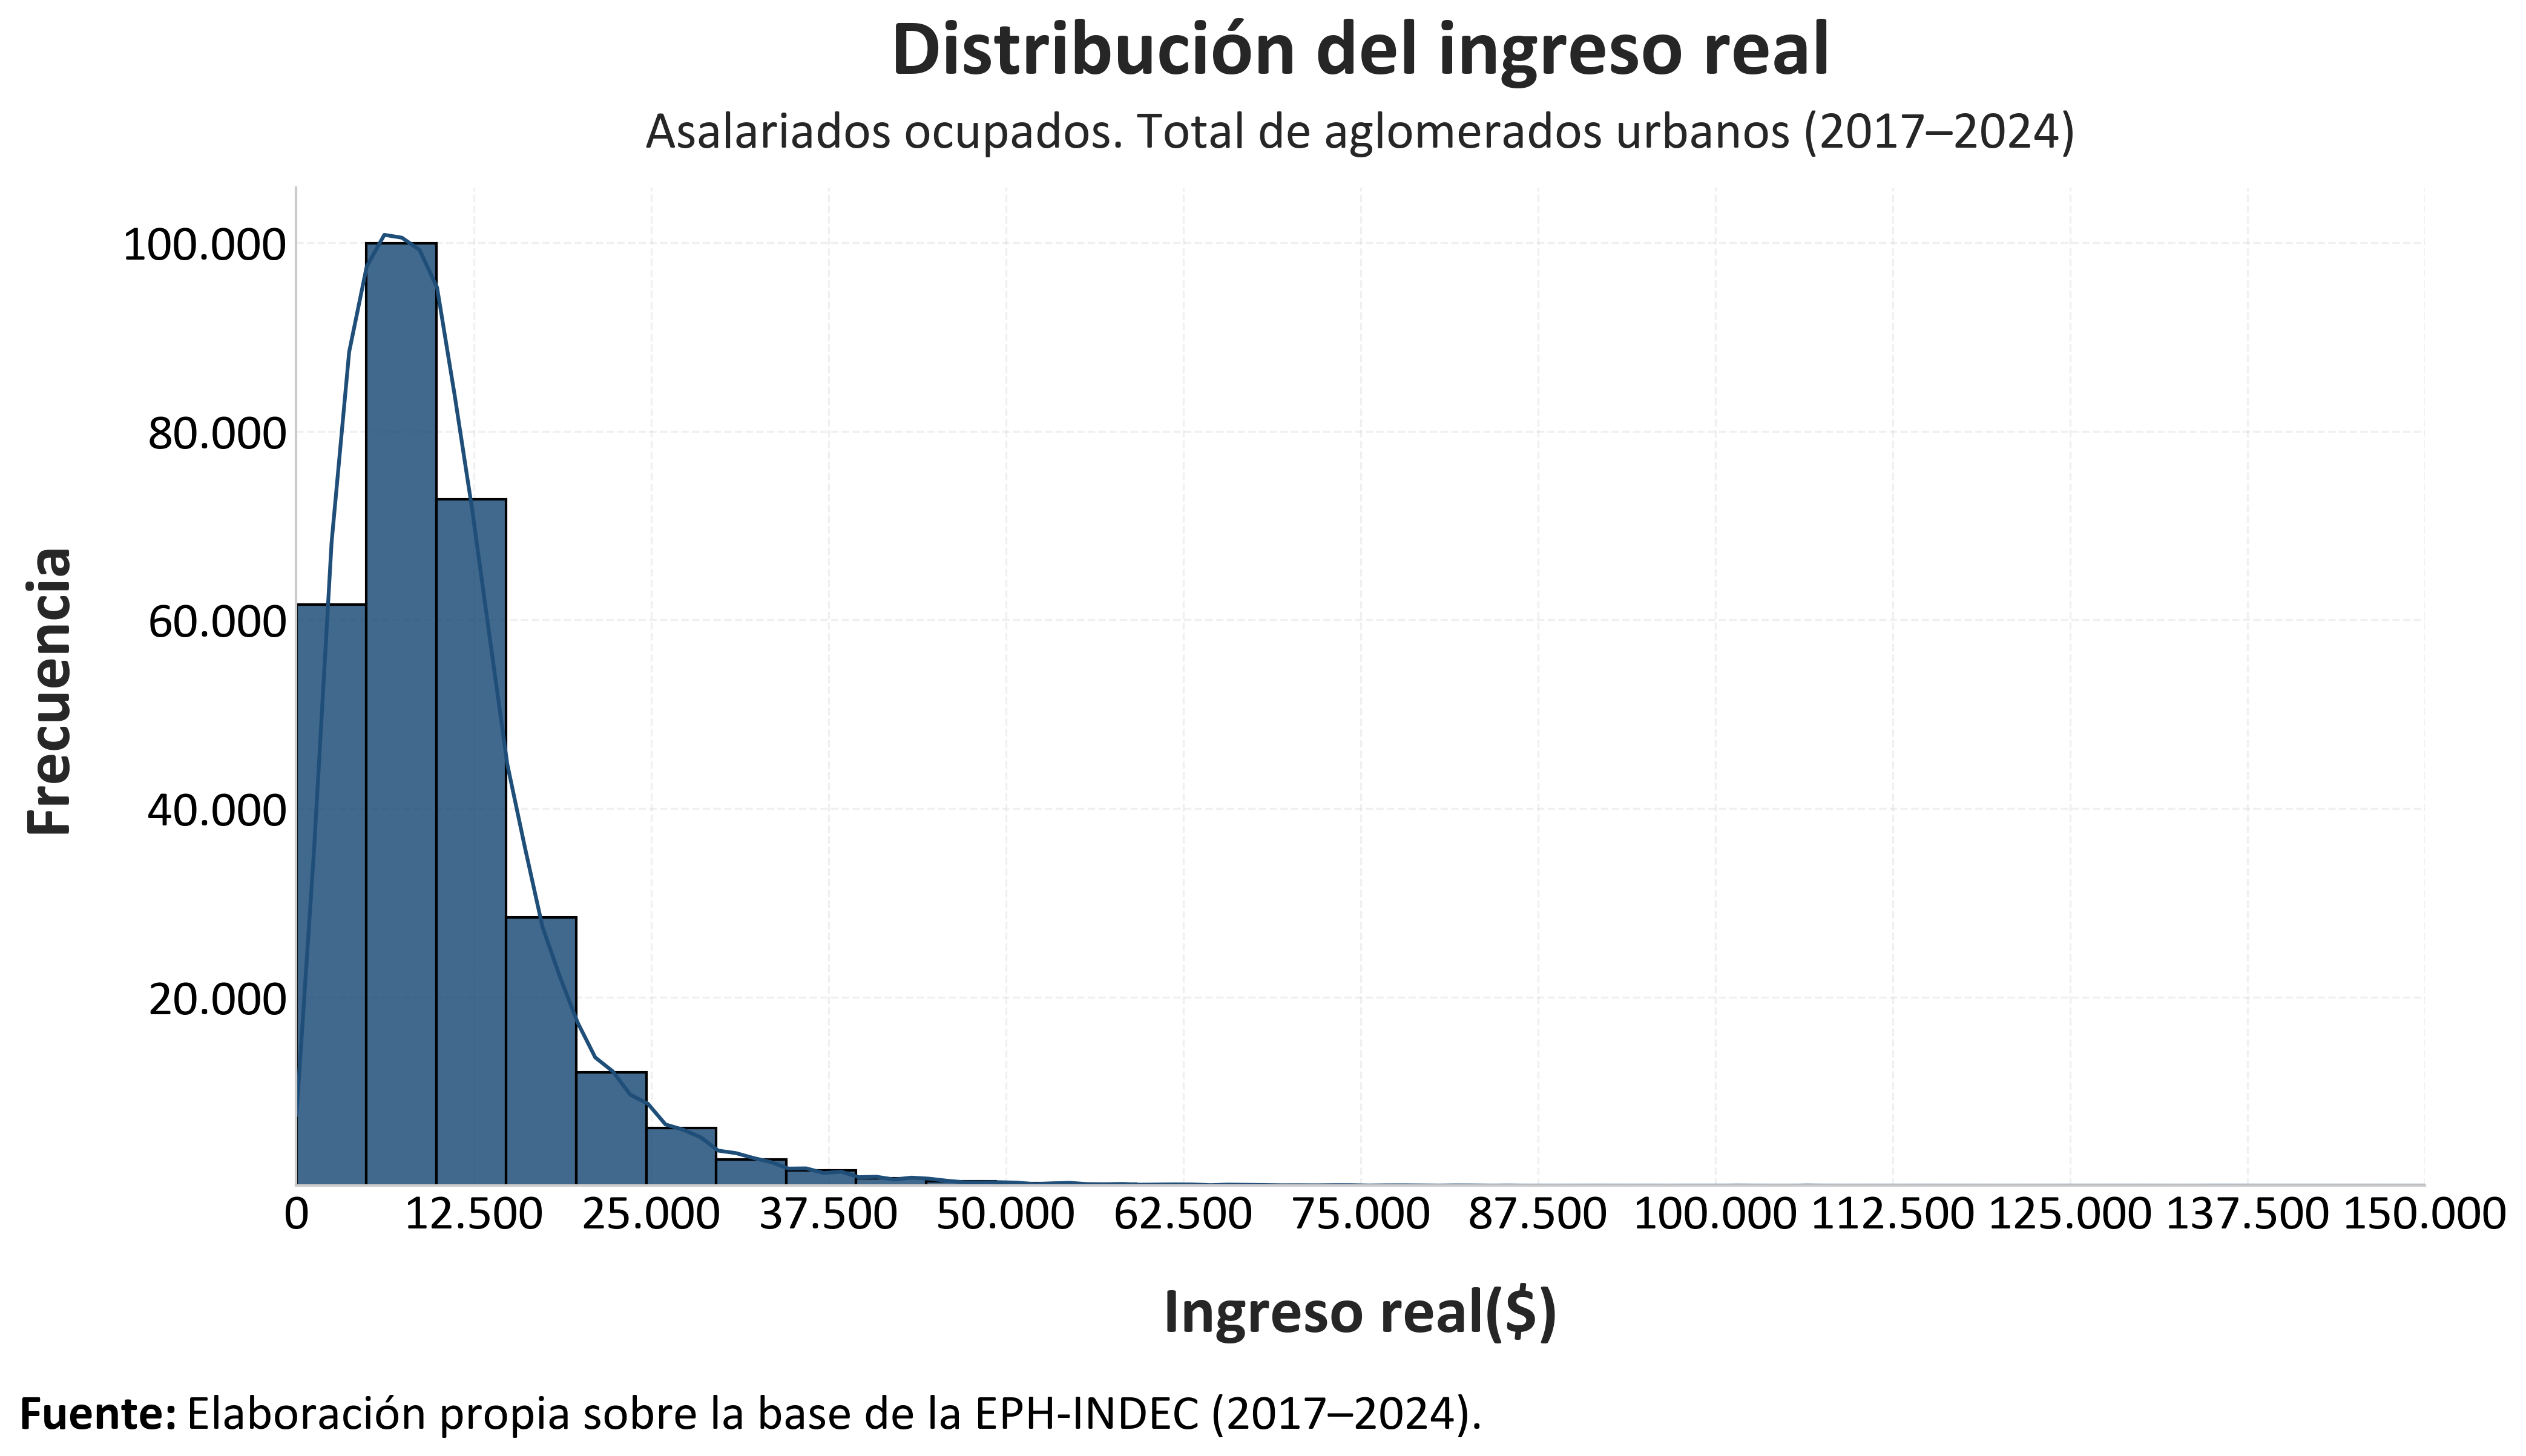

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================

plt.rcParams['font.family'] = 'Calibri'

# =========================================================
# HISTOGRAMA — INGRESO REAL
# =========================================================

plt.figure(
    figsize=(14,8),
    dpi=300
)

sns.histplot(
    data=df_asalariados,
    x='Ingreso_Real',
    bins=50,
    kde=True,
    color=color_principal,
    edgecolor='black',
    alpha=0.85
)

ax = plt.gca()

# ---------------------------------------------------------
# LÍMITE DEL EJE X
# ---------------------------------------------------------

plt.xlim(0, 150000)




# ---------------------------------------------------------
# TÍTULO
# ---------------------------------------------------------

plt.title(
    'Distribución del ingreso real',
    fontsize=32,
    fontweight='bold',
    pad=45
)

# ---------------------------------------------------------
# SUBTÍTULO / PERÍODO DE REFERENCIA
# ---------------------------------------------------------

plt.text(
    0.5,
    1.04,
    'Asalariados ocupados. Total de aglomerados urbanos (2017–2024)',
    fontsize=21,
    ha='center',
    transform=ax.transAxes
)

# ---------------------------------------------------------
# EJES
# ---------------------------------------------------------

plt.xlabel(
    'Ingreso real($)',
    fontsize=26,
    fontweight='bold',
    labelpad=18
)

plt.ylabel(
    'Frecuencia',
    fontsize=26,
    fontweight='bold',
    labelpad=18
)

# ---------------------------------------------------------
# TICKS
# ---------------------------------------------------------

plt.xticks(
    fontsize=20,
    color='black'
)

plt.yticks(
    fontsize=20,
    color='black'
)

# =========================================================
# EJE X — CADA 10.000
# =========================================================

ax.xaxis.set_major_locator(
    mtick.MultipleLocator(12500)
)

# FORMATO CON PUNTO

ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda x, p: format(int(x), ',').replace(',', '.')
    )
)

# =========================================================
# EJE Y — MILES CON PUNTO
# =========================================================

ax.yaxis.set_major_locator(
    mtick.MaxNLocator(6)
)

# ELIMINA SOLO EL 0 DEL EJE Y

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda y, p: '' if y == 0 else format(int(y), ',').replace(',', '.')
    )
)

# ---------------------------------------------------------
# ESTÉTICA PROFESIONAL
# ---------------------------------------------------------

sns.despine()

plt.grid(
    alpha=0.28,
    linestyle='--'
)


# ---------------------------------------------------------
# NOTA AL PIE (OPCIONAL PARA TESIS)
# ---------------------------------------------------------
plt.figtext(
    0.01,
    -0.04,
    'Fuente:',
    ha='left',
    fontsize=20,
    fontweight='bold',
    color='black'
)

plt.figtext(
    0.076,
    -0.04,
    'Elaboración propia sobre la base de la EPH-INDEC (2017–2024).',
    ha='left',
    fontsize=20,
    color='black'
)


plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

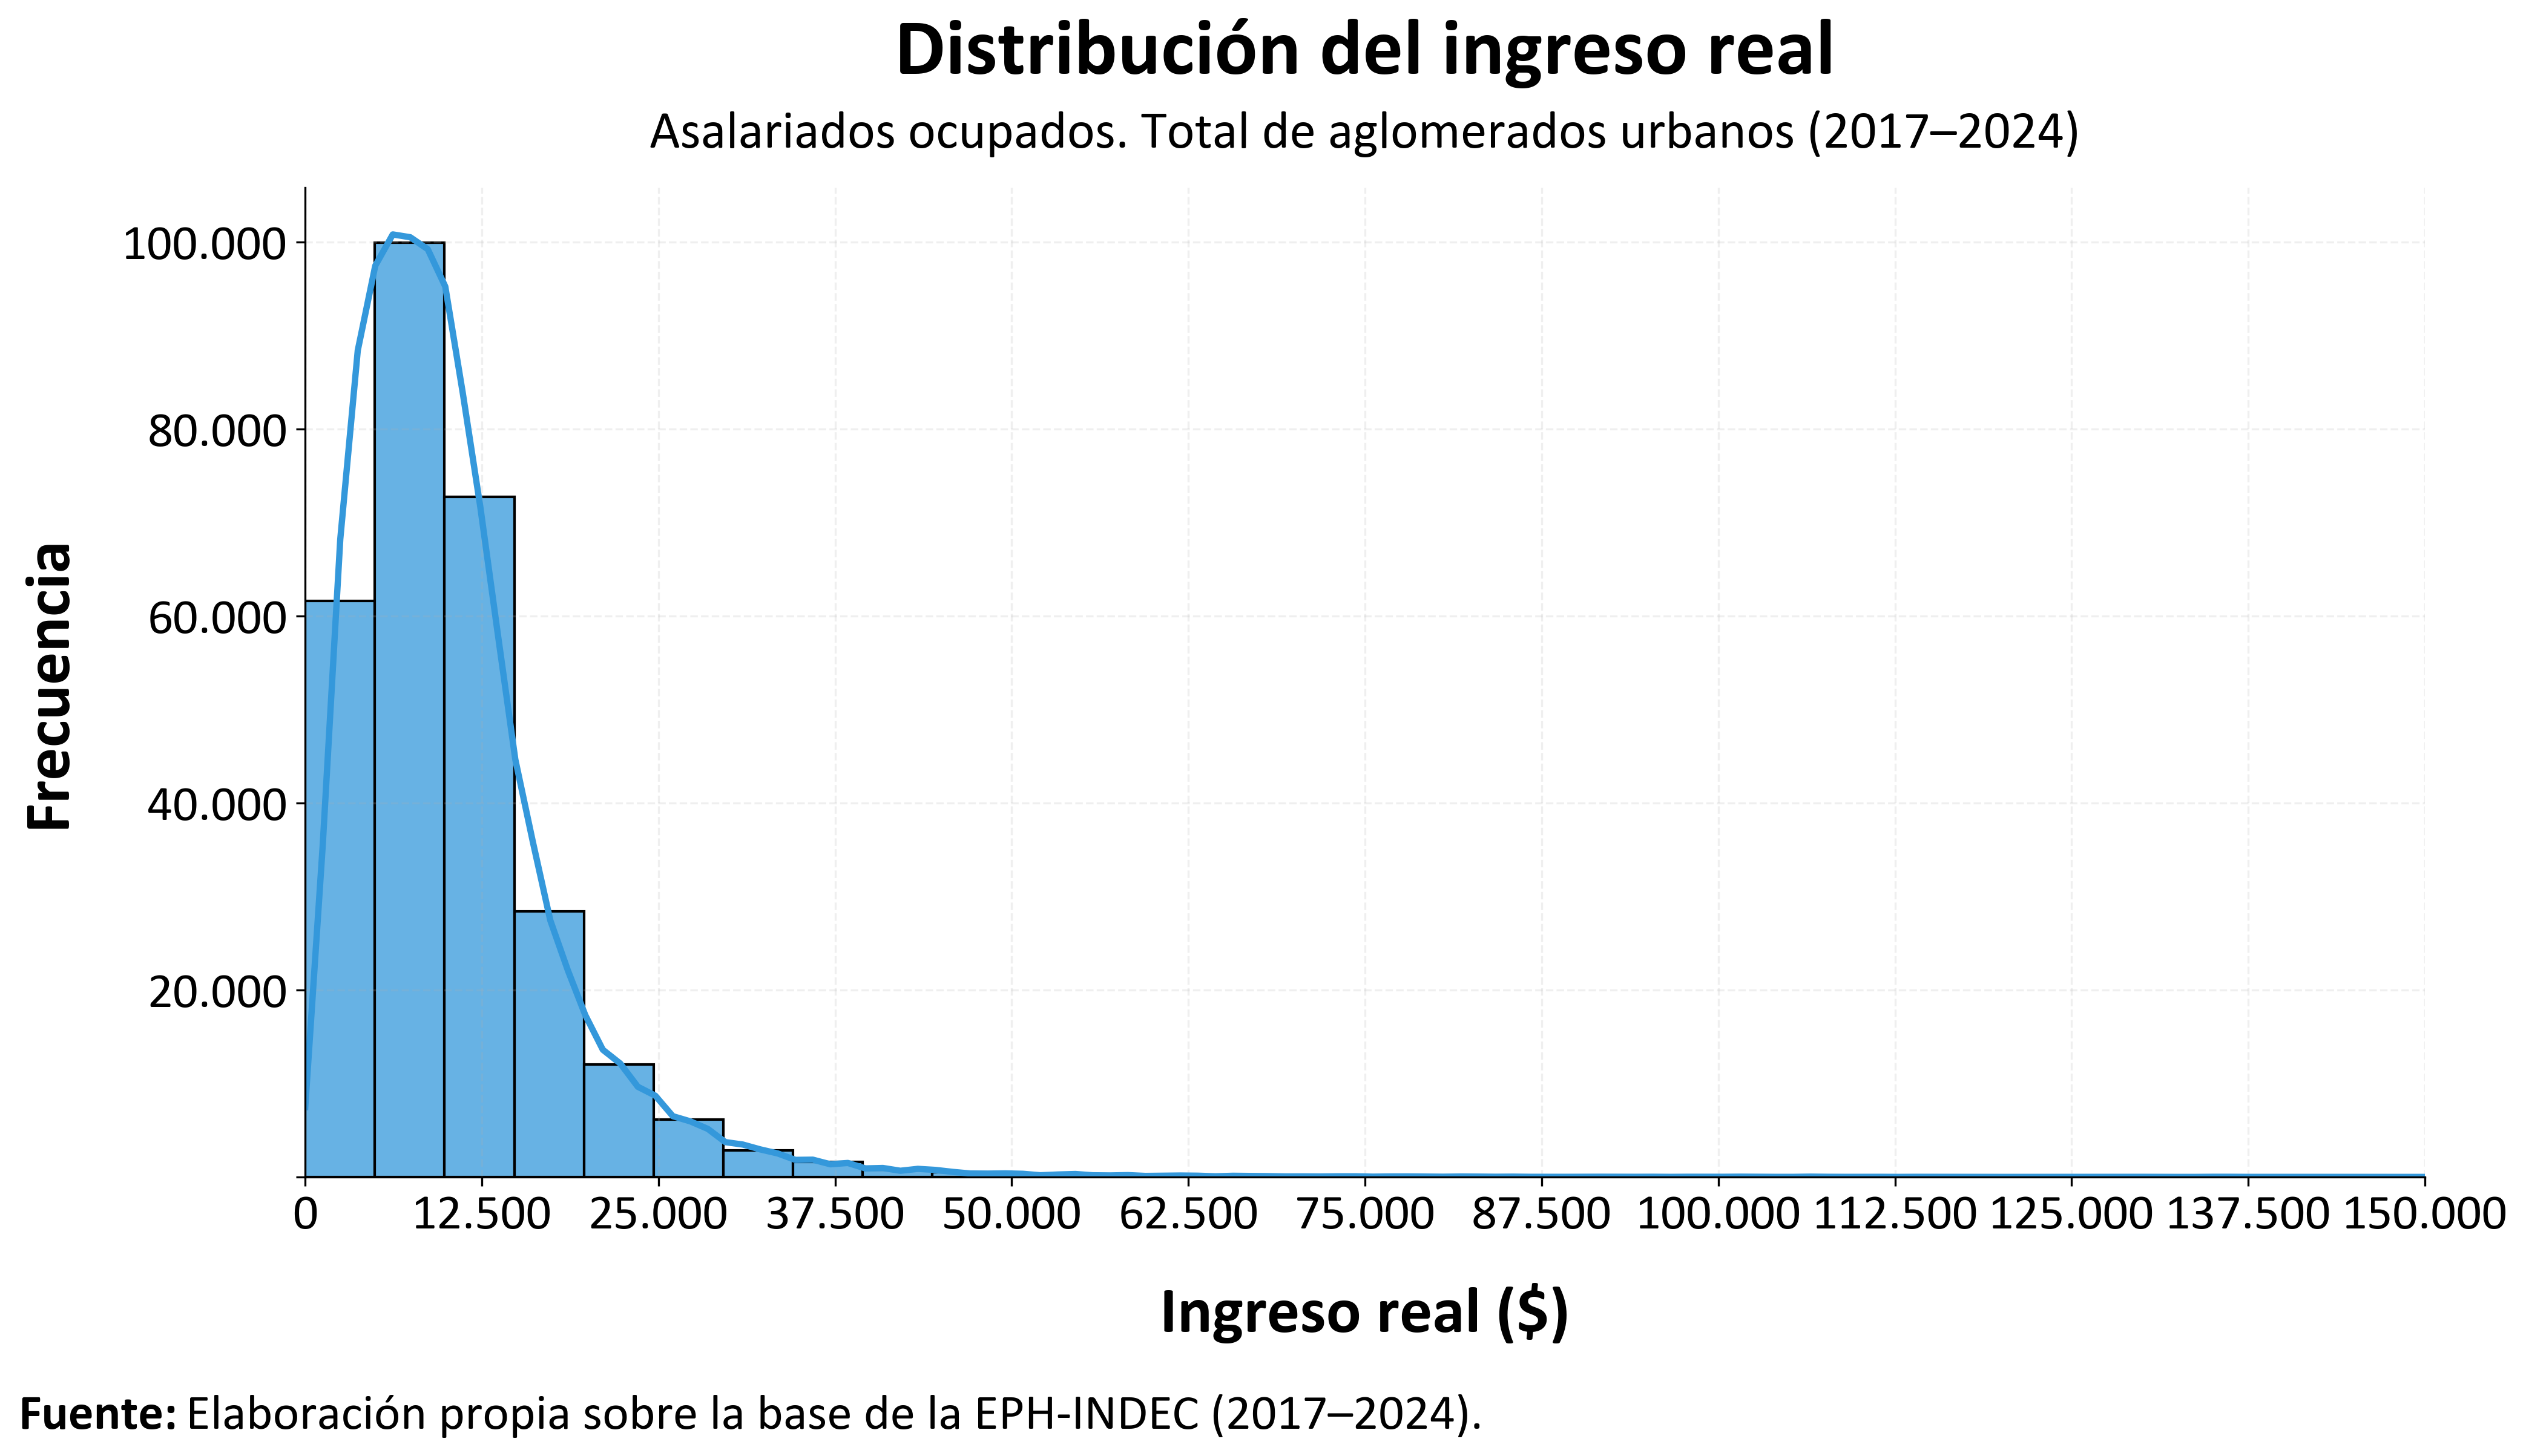

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================

plt.rcParams['font.family'] = 'Calibri'

# Color principal de la tesis
color_principal = '#3498DB'

# =========================================================
# HISTOGRAMA — INGRESO REAL
# =========================================================

plt.figure(
    figsize=(14, 8),
    dpi=300
)

sns.histplot(
    data=df_asalariados,
    x='Ingreso_Real',
    bins=50,
    kde=True,
    color=color_principal,
    edgecolor='black',
    alpha=0.75,
    line_kws={'linewidth': 2.5}
)

ax = plt.gca()

# ---------------------------------------------------------
# LÍMITE DEL EJE X
# ---------------------------------------------------------

plt.xlim(0, 150000)

# ---------------------------------------------------------
# TÍTULO
# ---------------------------------------------------------

plt.title(
    'Distribución del ingreso real',
    fontsize=32,
    fontweight='bold',
    pad=45
)

# ---------------------------------------------------------
# SUBTÍTULO
# ---------------------------------------------------------

plt.text(
    0.5,
    1.04,
    'Asalariados ocupados. Total de aglomerados urbanos (2017–2024)',
    fontsize=21,
    ha='center',
    transform=ax.transAxes
)

# ---------------------------------------------------------
# EJES
# ---------------------------------------------------------

plt.xlabel(
    'Ingreso real ($)',
    fontsize=26,
    fontweight='bold',
    labelpad=18
)

plt.ylabel(
    'Frecuencia',
    fontsize=26,
    fontweight='bold',
    labelpad=18
)

# ---------------------------------------------------------
# TICKS
# ---------------------------------------------------------

plt.xticks(
    fontsize=20,
    color='black'
)

plt.yticks(
    fontsize=20,
    color='black'
)

# =========================================================
# EJE X — INTERVALOS DE $12.500
# =========================================================

ax.xaxis.set_major_locator(
    mtick.MultipleLocator(12500)
)

ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda x, p: format(int(x), ',').replace(',', '.')
    )
)

# =========================================================
# EJE Y
# =========================================================

ax.yaxis.set_major_locator(
    mtick.MaxNLocator(6)
)

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda y, p: '' if y == 0
        else format(int(y), ',').replace(',', '.')
    )
)

# ---------------------------------------------------------
# ESTÉTICA PROFESIONAL
# ---------------------------------------------------------

sns.despine()

plt.grid(
    alpha=0.20,
    linestyle='--'
)

# =========================================================
# NOTA AL PIE
# =========================================================

plt.figtext(
    0.01,
    -0.04,
    'Fuente:',
    ha='left',
    fontsize=20,
    fontweight='bold',
    color='black'
)

plt.figtext(
    0.076,
    -0.04,
    'Elaboración propia sobre la base de la EPH-INDEC (2017–2024).',
    ha='left',
    fontsize=20,
    color='black'
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]

)

plt.savefig(
    r'D:\repositorios\modelos-segmentacion-laboral\Figuras\figura_4_distribucion_ingreso_real.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Ingreso Real según Tamaño de la Empresa y Condición Laboral

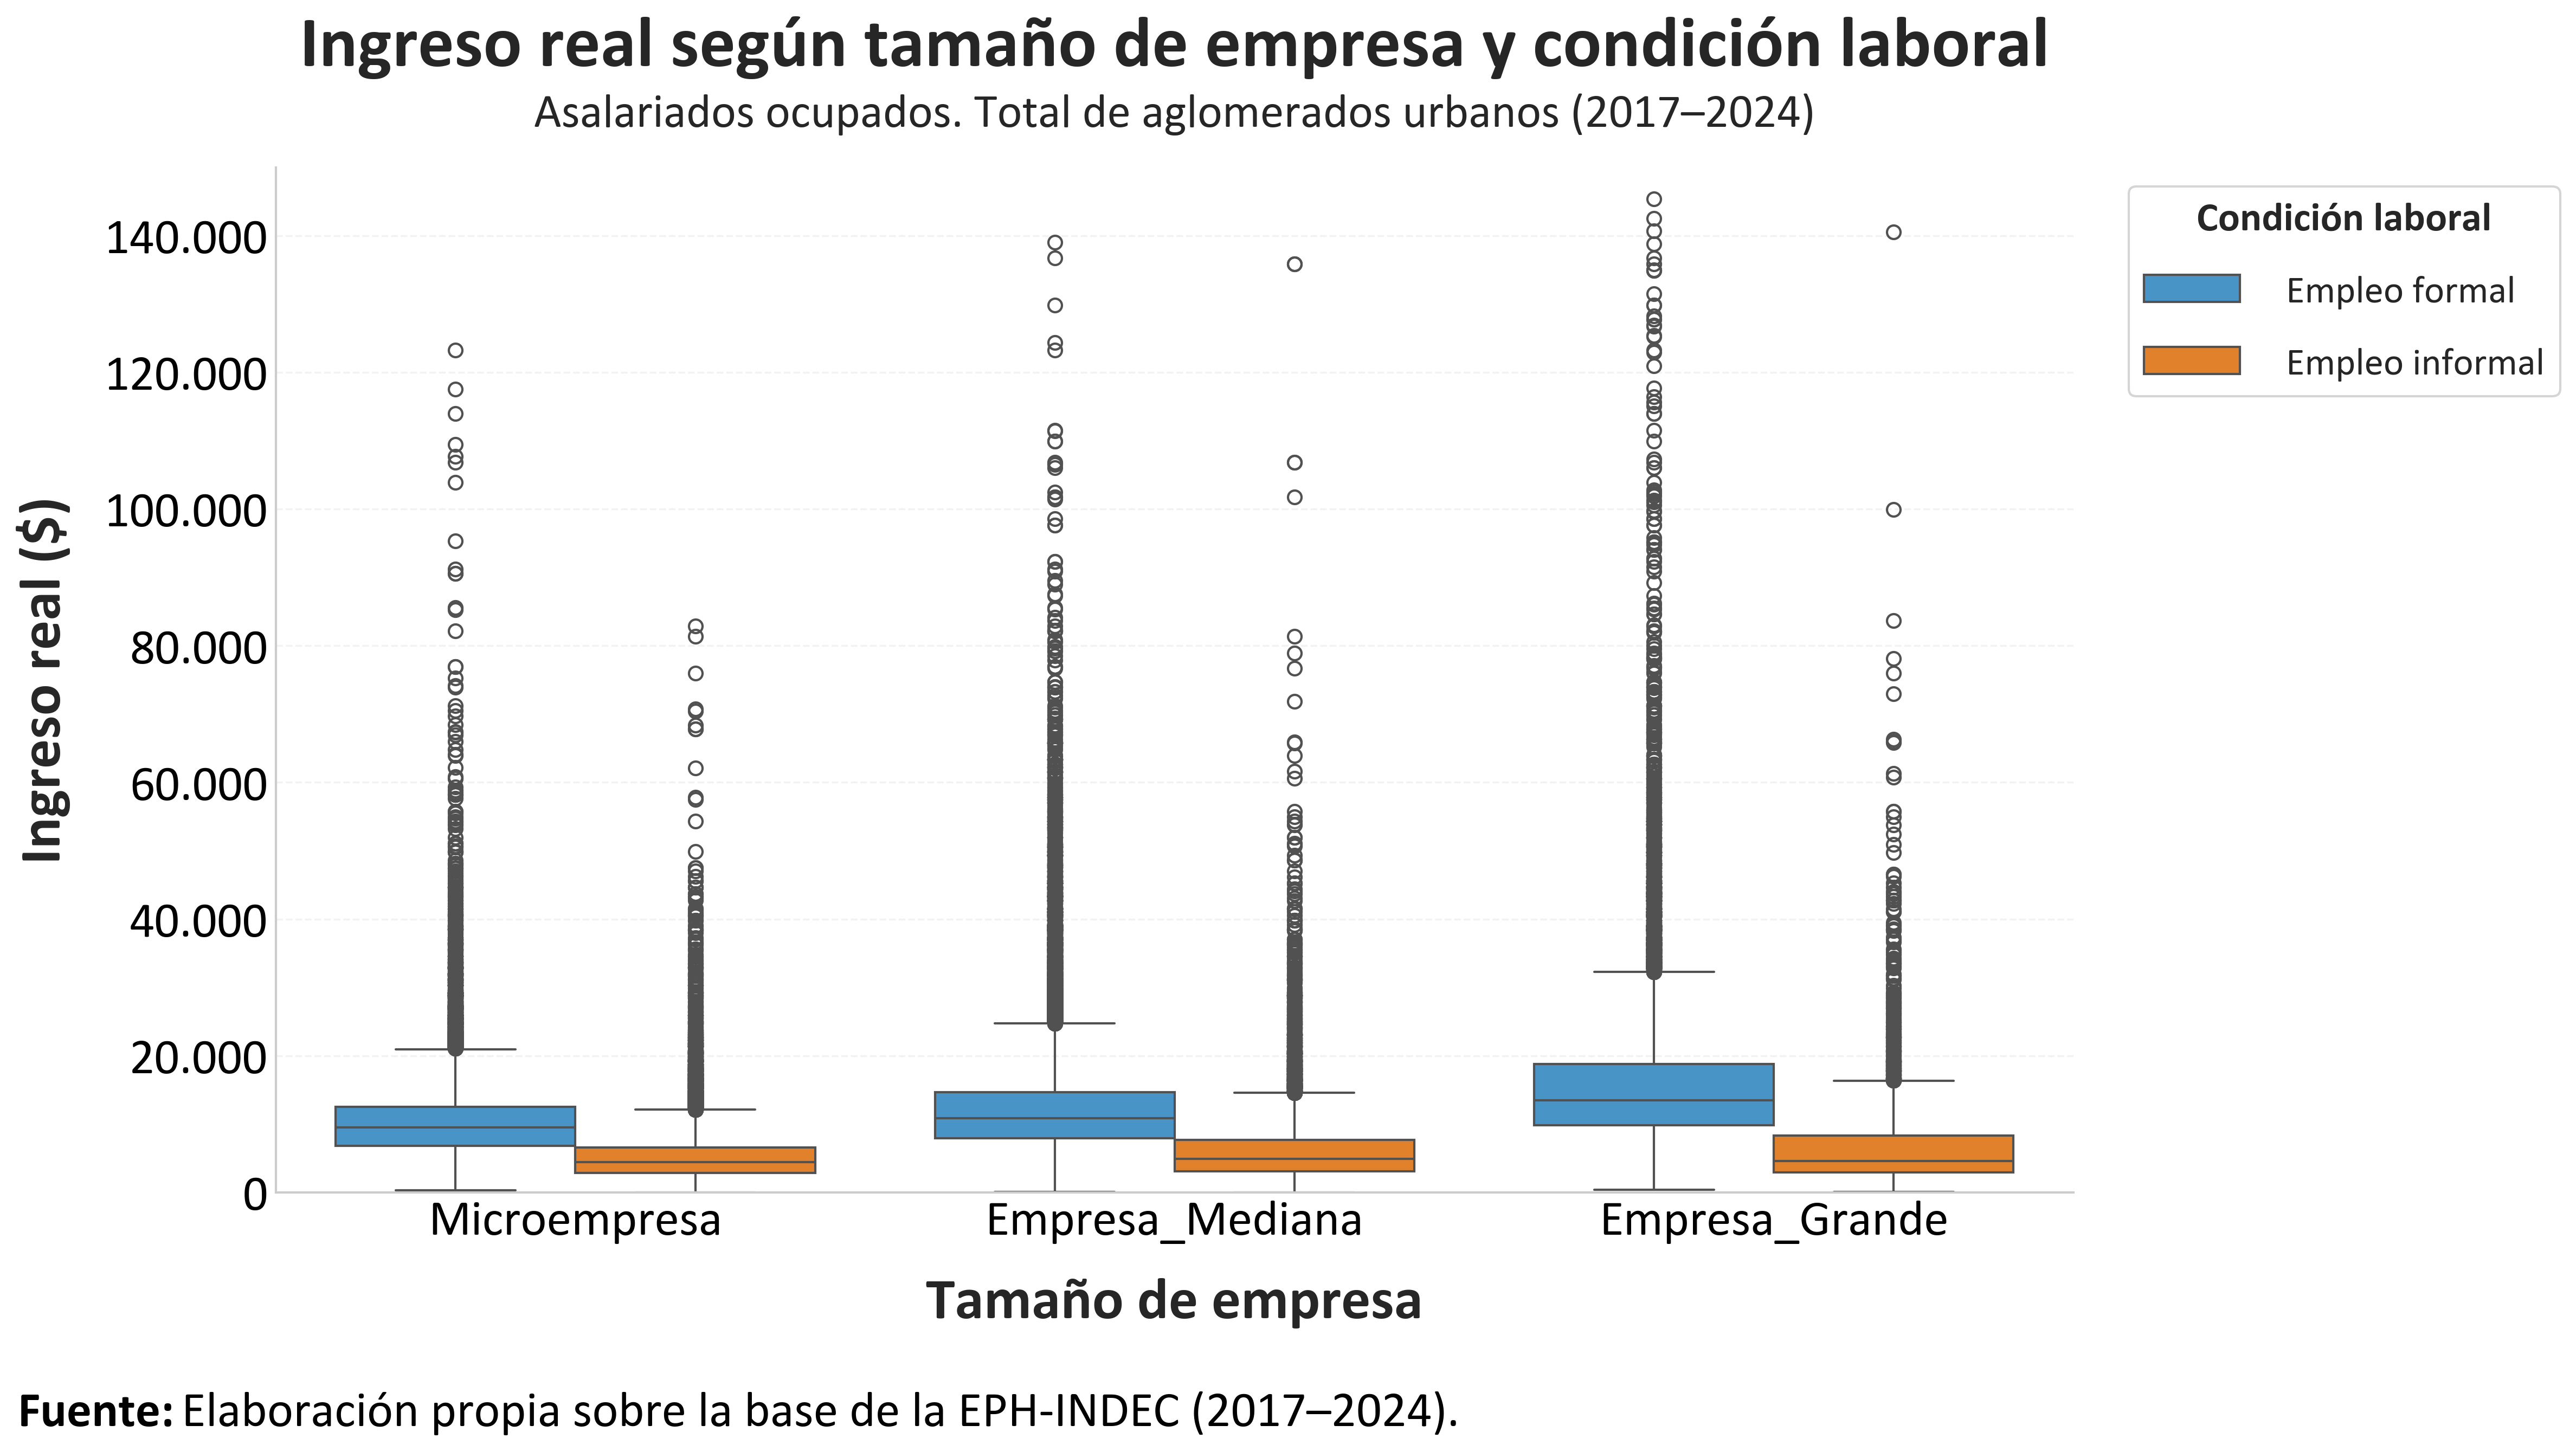

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.font_manager import FontProperties

# =========================================================
# CONFIGURACIÓN GENERAL — ESTILO TESIS
# =========================================================

plt.rcParams['font.family'] = 'Calibri'

# =========================================================
# TAMAÑO EMPRESA + CONDICIÓN LABORAL VS INGRESO REAL
# =========================================================

plt.figure(
    figsize=(16, 9),
    dpi=300
)

sns.boxplot(
    data=df_asalariados,
    x='Tamaño_Empresa',
    y='Ingreso_Real',
    hue='Condición laboral',
    order=[
        'Microempresa',
        'Empresa_Mediana',
        'Empresa_Grande'
    ],
    palette=['#3498DB', '#FF7F0E']
)

ax = plt.gca()

# ---------------------------------------------------------
# ESCALA DEL EJE Y
# ---------------------------------------------------------

ax.set_ylim(0, 150000)

ax.set_yticks(
    range(0, 150001, 20000)
)

# ---------------------------------------------------------
# TÍTULO
# ---------------------------------------------------------

plt.title(
    'Ingreso real según tamaño de empresa y condición laboral',
    fontsize=32,
    fontweight='bold',
    pad=45
)

# ---------------------------------------------------------
# SUBTÍTULO
# ---------------------------------------------------------

plt.text(
    0.5,
    1.04,
    'Asalariados ocupados. Total de aglomerados urbanos (2017–2024)',
    fontsize=21,
    ha='center',
    transform=ax.transAxes
)

# ---------------------------------------------------------
# EJES
# ---------------------------------------------------------

plt.xlabel(
    'Tamaño de empresa',
    fontsize=26,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Ingreso real ($)',
    fontsize=26,
    fontweight='bold',
    labelpad=15
)

# ---------------------------------------------------------
# TICKS
# ---------------------------------------------------------

plt.xticks(
    fontsize=22,
    color='black'
)

plt.yticks(
    fontsize=22,
    color='black'
)

# ---------------------------------------------------------
# FORMATO EJE Y — PUNTO DE MILES
# ---------------------------------------------------------

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda y, p: format(int(y), ',').replace(',', '.')
    )
)

# ---------------------------------------------------------
# LEYENDA
# ---------------------------------------------------------

legend_title_font = FontProperties(
    weight='bold',
    size=18
)

plt.legend(
    title='Condición laboral',
    title_fontproperties=legend_title_font,
    fontsize=17,
    frameon=True,
    facecolor='white',
    edgecolor='lightgray',
    framealpha=0.95,
    fancybox=True,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    handlelength=2.5,
    handletextpad=1.2,
    labelspacing=1.0
)

# ---------------------------------------------------------
# ESTÉTICA PROFESIONAL
# ---------------------------------------------------------

sns.despine()

plt.grid(
    axis='y',
    alpha=0.25,
    linestyle='--'
)

# ---------------------------------------------------------
# FUENTE
# ---------------------------------------------------------

plt.figtext(
    0.01,
    -0.03,
    'Fuente:',
    ha='left',
    fontsize=22,
    fontweight='bold',
    color='black'
)

plt.figtext(
    0.073,
    -0.03,
    'Elaboración propia sobre la base de la EPH-INDEC (2017–2024).',
    ha='left',
    fontsize=22,
    color='black'
)

plt.tight_layout(
    rect=[0, 0.02, 1, 0.95]
)

plt.subplots_adjust(
    right=0.8
)

plt.show()

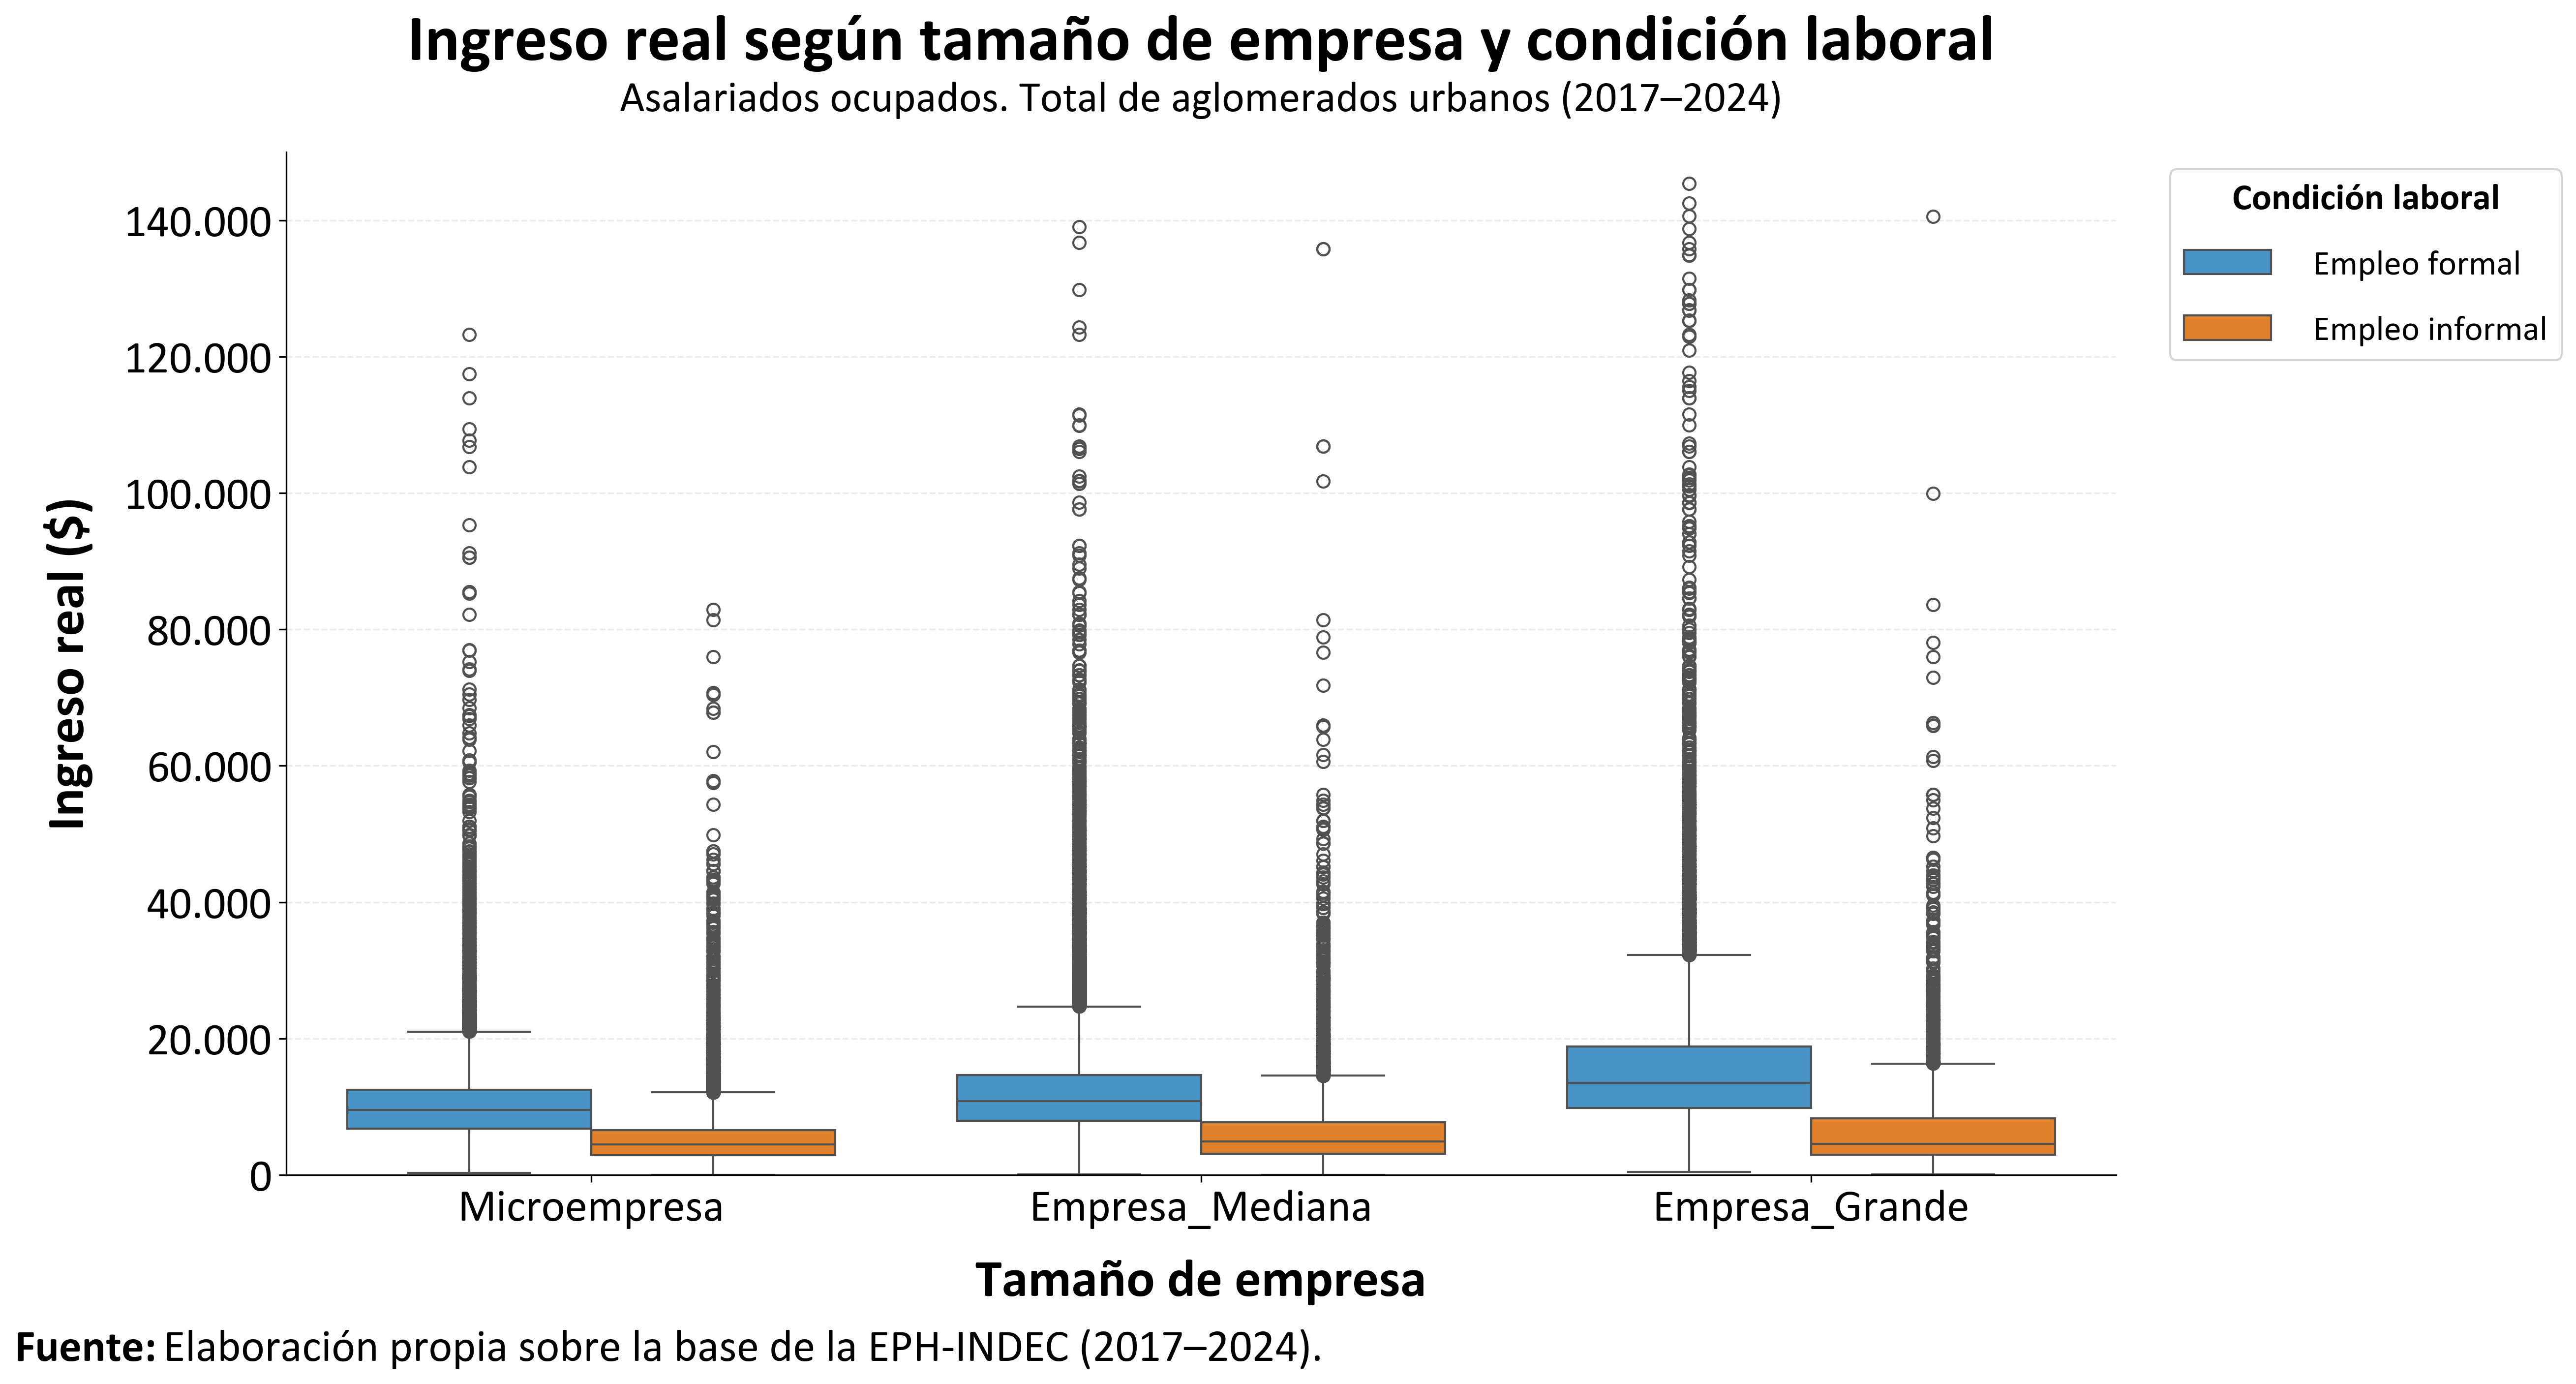

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.font_manager import FontProperties

# =========================================================
# CONFIGURACIÓN GENERAL — ESTILO TESIS
# =========================================================

plt.rcParams['font.family'] = 'Calibri'

# =========================================================
# TAMAÑO EMPRESA + CONDICIÓN LABORAL VS INGRESO REAL
# =========================================================

plt.figure(
    figsize=(16, 9),
    dpi=300
)

sns.boxplot(
    data=df_asalariados,
    x='Tamaño_Empresa',
    y='Ingreso_Real',
    hue='Condición laboral',
    order=[
        'Microempresa',
        'Empresa_Mediana',
        'Empresa_Grande'
    ],
    palette=['#3498DB', '#FF7F0E']
)

ax = plt.gca()

# ---------------------------------------------------------
# ESCALA DEL EJE Y
# ---------------------------------------------------------

ax.set_ylim(0, 150000)

ax.set_yticks(
    range(0, 150001, 20000)
)

# ---------------------------------------------------------
# TÍTULO
# ---------------------------------------------------------

plt.title(
    'Ingreso real según tamaño de empresa y condición laboral',
    fontsize=32,
    fontweight='bold',
    pad=45
)

# ---------------------------------------------------------
# SUBTÍTULO / PERÍODO DE REFERENCIA
# ---------------------------------------------------------

plt.text(
    0.5,
    1.04,
    'Asalariados ocupados. Total de aglomerados urbanos (2017–2024)',
    fontsize=21,
    ha='center',
    transform=ax.transAxes
)

# ---------------------------------------------------------
# EJES
# ---------------------------------------------------------

plt.xlabel(
    'Tamaño de empresa',
    fontsize=26,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Ingreso real ($)',
    fontsize=26,
    fontweight='bold',
    labelpad=15
)

# ---------------------------------------------------------
# TICKS
# ---------------------------------------------------------

plt.xticks(
    fontsize=22,
    color='black'
)

plt.yticks(
    fontsize=22,
    color='black'
)

# ---------------------------------------------------------
# FORMATO EJE Y — PUNTO DE MILES
# ---------------------------------------------------------

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda y, p: format(int(y), ',').replace(',', '.')
    )
)

# ---------------------------------------------------------
# LEYENDA
# ---------------------------------------------------------

legend_title_font = FontProperties(
    weight='bold',
    size=18
)

plt.legend(
    title='Condición laboral',
    title_fontproperties=legend_title_font,
    fontsize=17,
    frameon=True,
    facecolor='white',
    edgecolor='lightgray',
    framealpha=0.95,
    fancybox=True,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    handlelength=2.5,
    handletextpad=1.2,
    labelspacing=1.0
)

# ---------------------------------------------------------
# ESTÉTICA PROFESIONAL
# ---------------------------------------------------------

sns.despine()

plt.grid(
    axis='y',
    alpha=0.25,
    linestyle='--'
)

# ---------------------------------------------------------
# NOTA AL PIE
# ---------------------------------------------------------

plt.figtext(
    0.01,
    -0.03,
    'Fuente:',
    ha='left',
    fontsize=22,
    fontweight='bold',
    color='black'
)

plt.figtext(
    0.073,
    -0.03,
    'Elaboración propia sobre la base de la EPH-INDEC (2017–2024).',
    ha='left',
    fontsize=22,
    color='black'
)
### Se incorpora la figura al repositorio de GitHub para su uso en eL TIF.
plt.savefig(
    r'D:\repositorios\modelos-segmentacion-laboral\Figuras\figura_5_ingreso_real_tamaño_condición.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.subplots_adjust(right=0.8)

plt.show()

In [ ]:
print(df_asalariados['Tamaño_Empresa'].unique())

['Microempresa', 'Empresa_Mediana', 'Empresa_Grande']
Categories (3, object): ['Empresa_Grande', 'Empresa_Mediana', 'Microempresa']


### Ingreso Real según Región y Condición Laboral

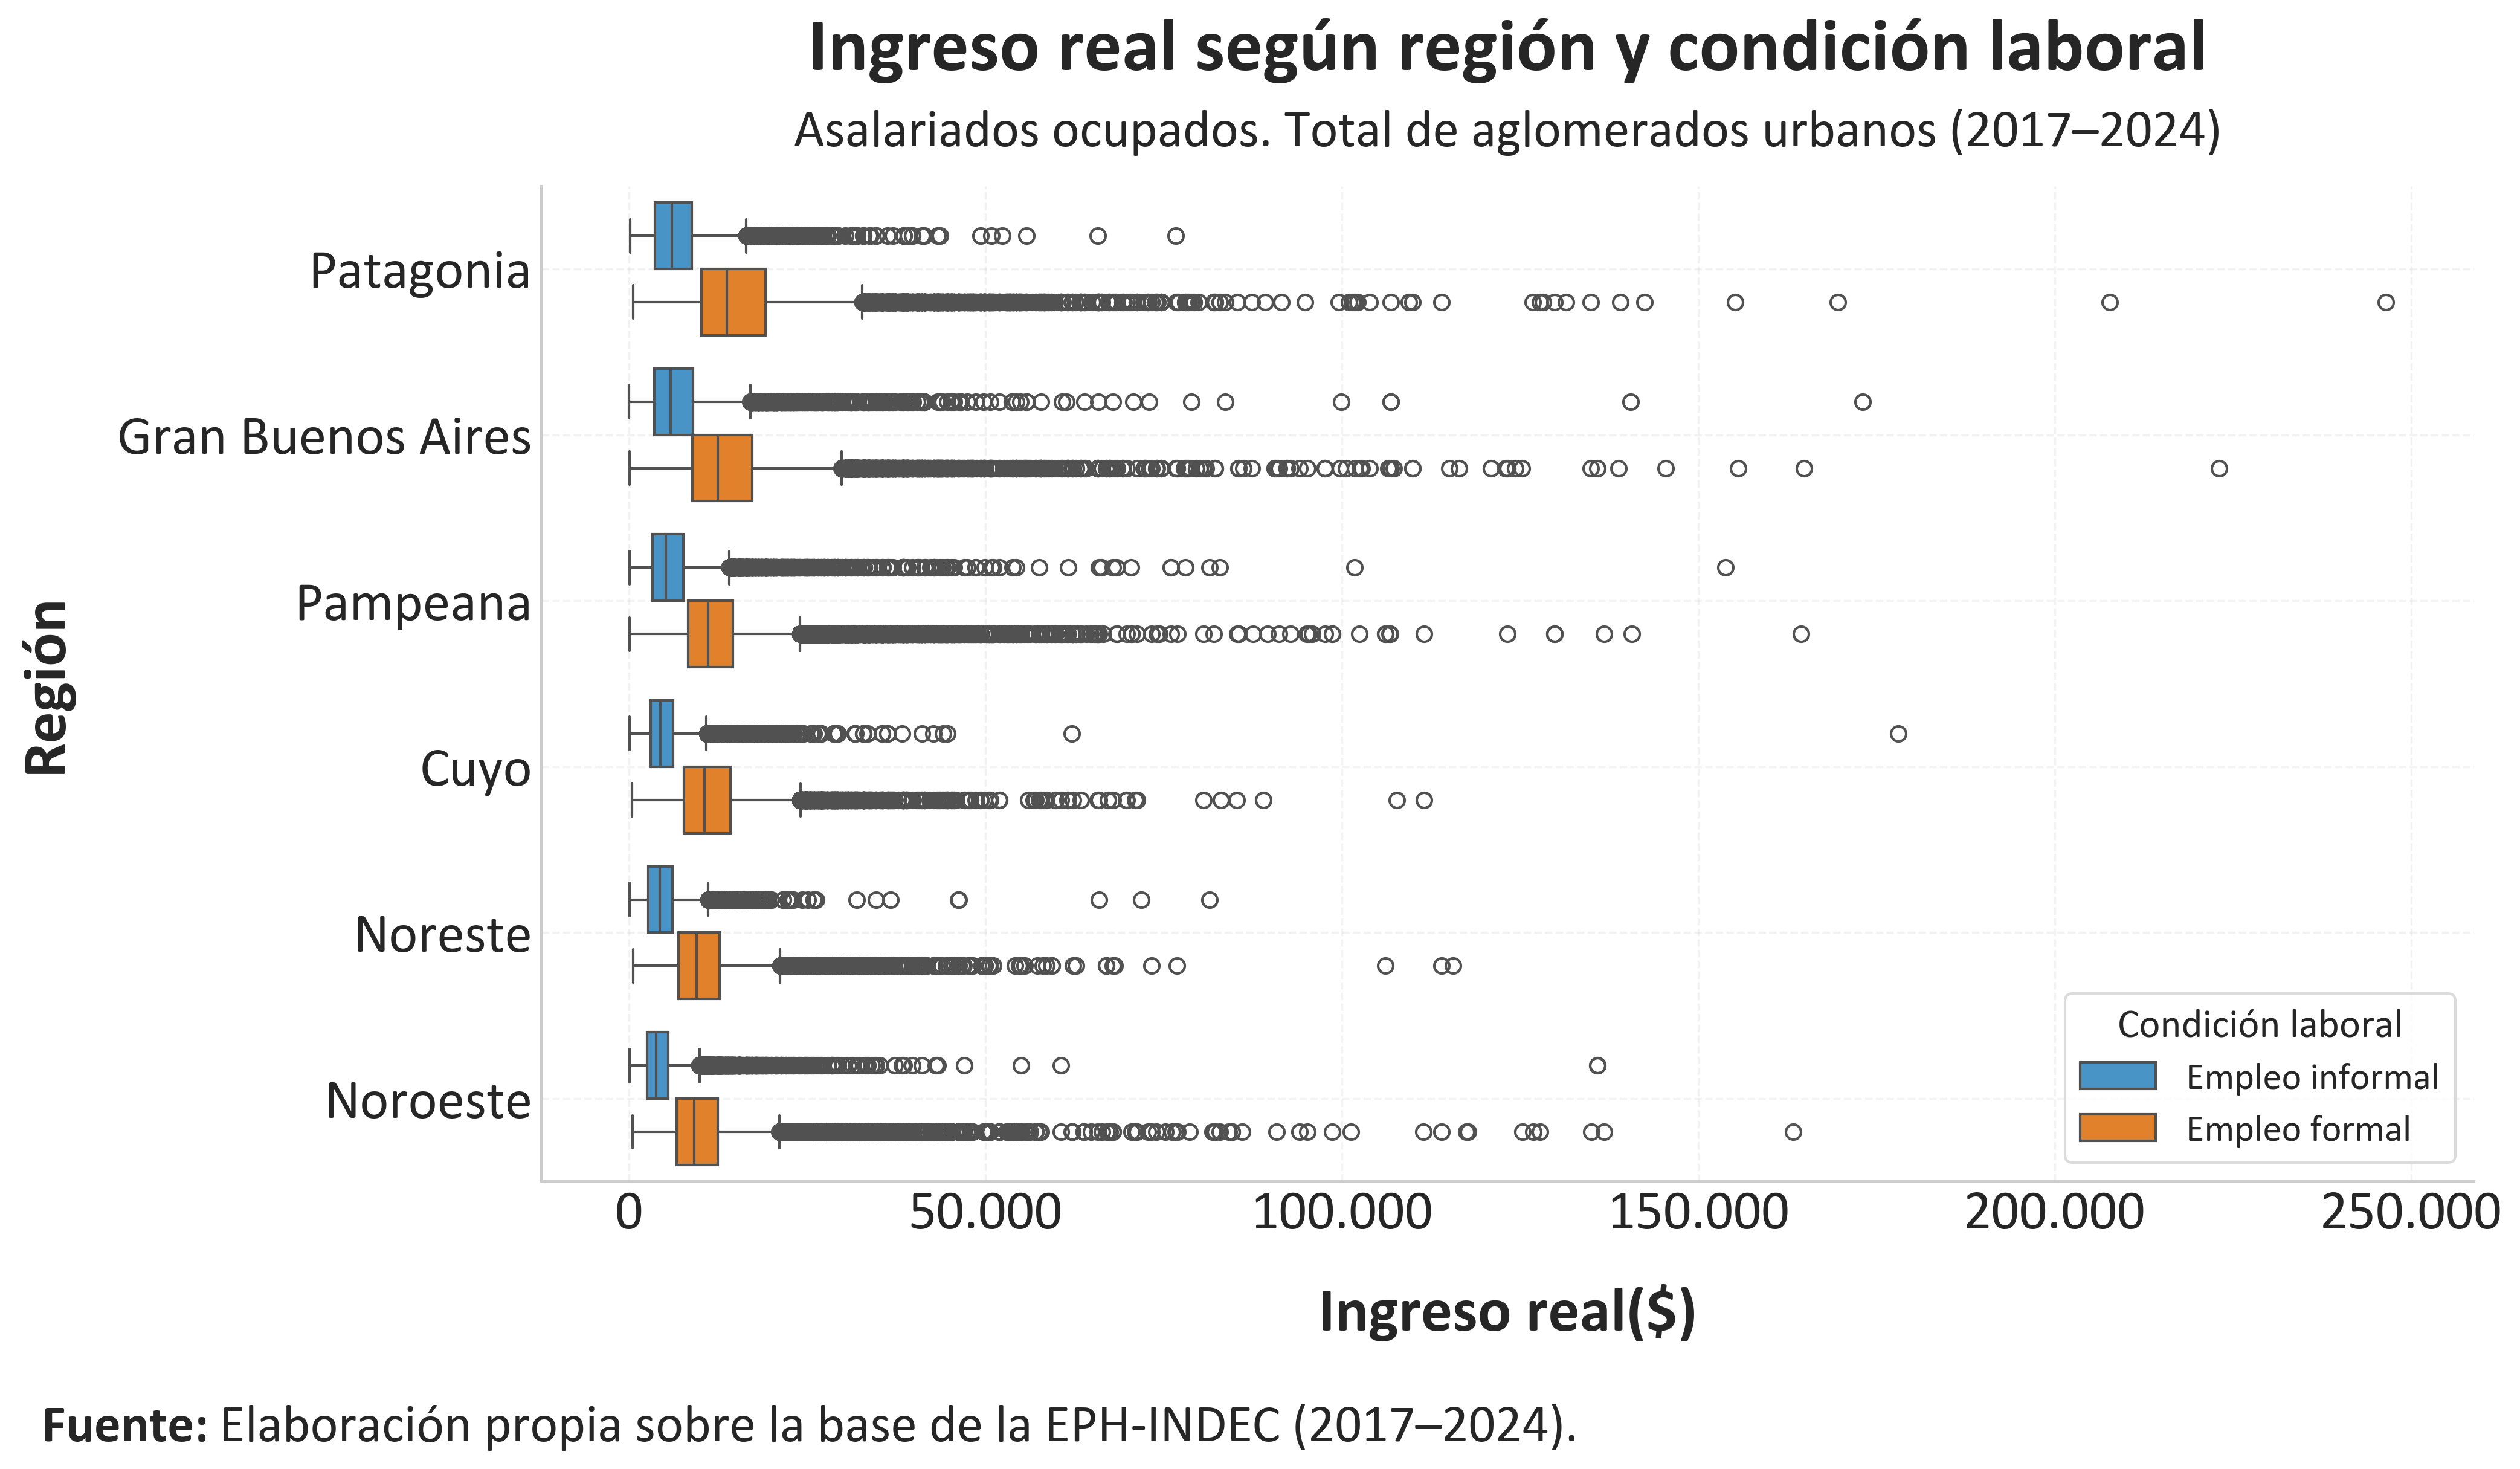

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# =========================================================
# CONFIGURACIÓN GENERAL — ESTILO TESIS
# =========================================================
plt.rcParams['font.family'] = 'Calibri'

# =========================================================
# ORDENAR REGIONES POR MEDIANA DE INGRESO
# =========================================================
orden_region = (
    df_asalariados
    .groupby('Region')['Ingreso_Real']
    .median()
    .sort_values(ascending=False)
    .index
)

df_asalariados['Region'] = pd.Categorical(
    df_asalariados['Region'],
    categories=orden_region,
    ordered=True
)

# =========================================================
# FIGURA
# =========================================================
plt.figure(figsize=(14,8), dpi=300)

ax = sns.boxplot(
    data=df_asalariados,
    y='Region',
    x='Ingreso_Real',
    hue='Informal',
    palette=['#3498DB', '#FF7F0E'],
    dodge=True
)
### '#1f4e79', '#5b9bd5'
# =========================================================
# TÍTULO
# =========================================================
plt.title(
    'Ingreso real según región y condición laboral',
    fontsize=30,
    fontweight='bold',
    pad=46
)

# =========================================================
# SUBTÍTULO
# =========================================================
plt.text(
    0.5,
    1.04,
    'Asalariados ocupados. Total de aglomerados urbanos (2017–2024)',
    fontsize=21,
    ha='center',
    transform=ax.transAxes
)

# =========================================================
# EJES
# =========================================================
plt.xlabel('Ingreso real($)', fontsize=25, fontweight='bold', labelpad=18)
plt.ylabel('Región', fontsize=25, fontweight='bold', labelpad=18)

plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

# =========================================================
# FORMATO EJE X
# =========================================================
ax.xaxis.set_major_locator(mtick.MultipleLocator(50000))

ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, p: f'{x:,.0f}'.replace(',', '.'))
)

# =========================================================
# LEYENDA
# =========================================================
plt.legend(
    title='Condición laboral',
    fontsize=15,
    title_fontsize=16,
    frameon=True,
    facecolor='white',
    edgecolor='lightgray'
)

# =========================================================
# ESTÉTICA FINAL
# =========================================================
sns.despine()
plt.grid(alpha=0.25, linestyle='--')
plt.tight_layout(rect=[0, 0, 1, 0.95])

# =========================================================
# NOTA AL PIE
# =========================================================
plt.figtext(
    0.02,
    -0.05,
    "Fuente:",
    ha='left',
    fontsize=21,
    fontweight='bold'
)

plt.figtext(
    0.090,
    -0.05,
    "Elaboración propia sobre la base de la EPH-INDEC (2017–2024).",
    ha='left',
    fontsize=21
)

plt.show()

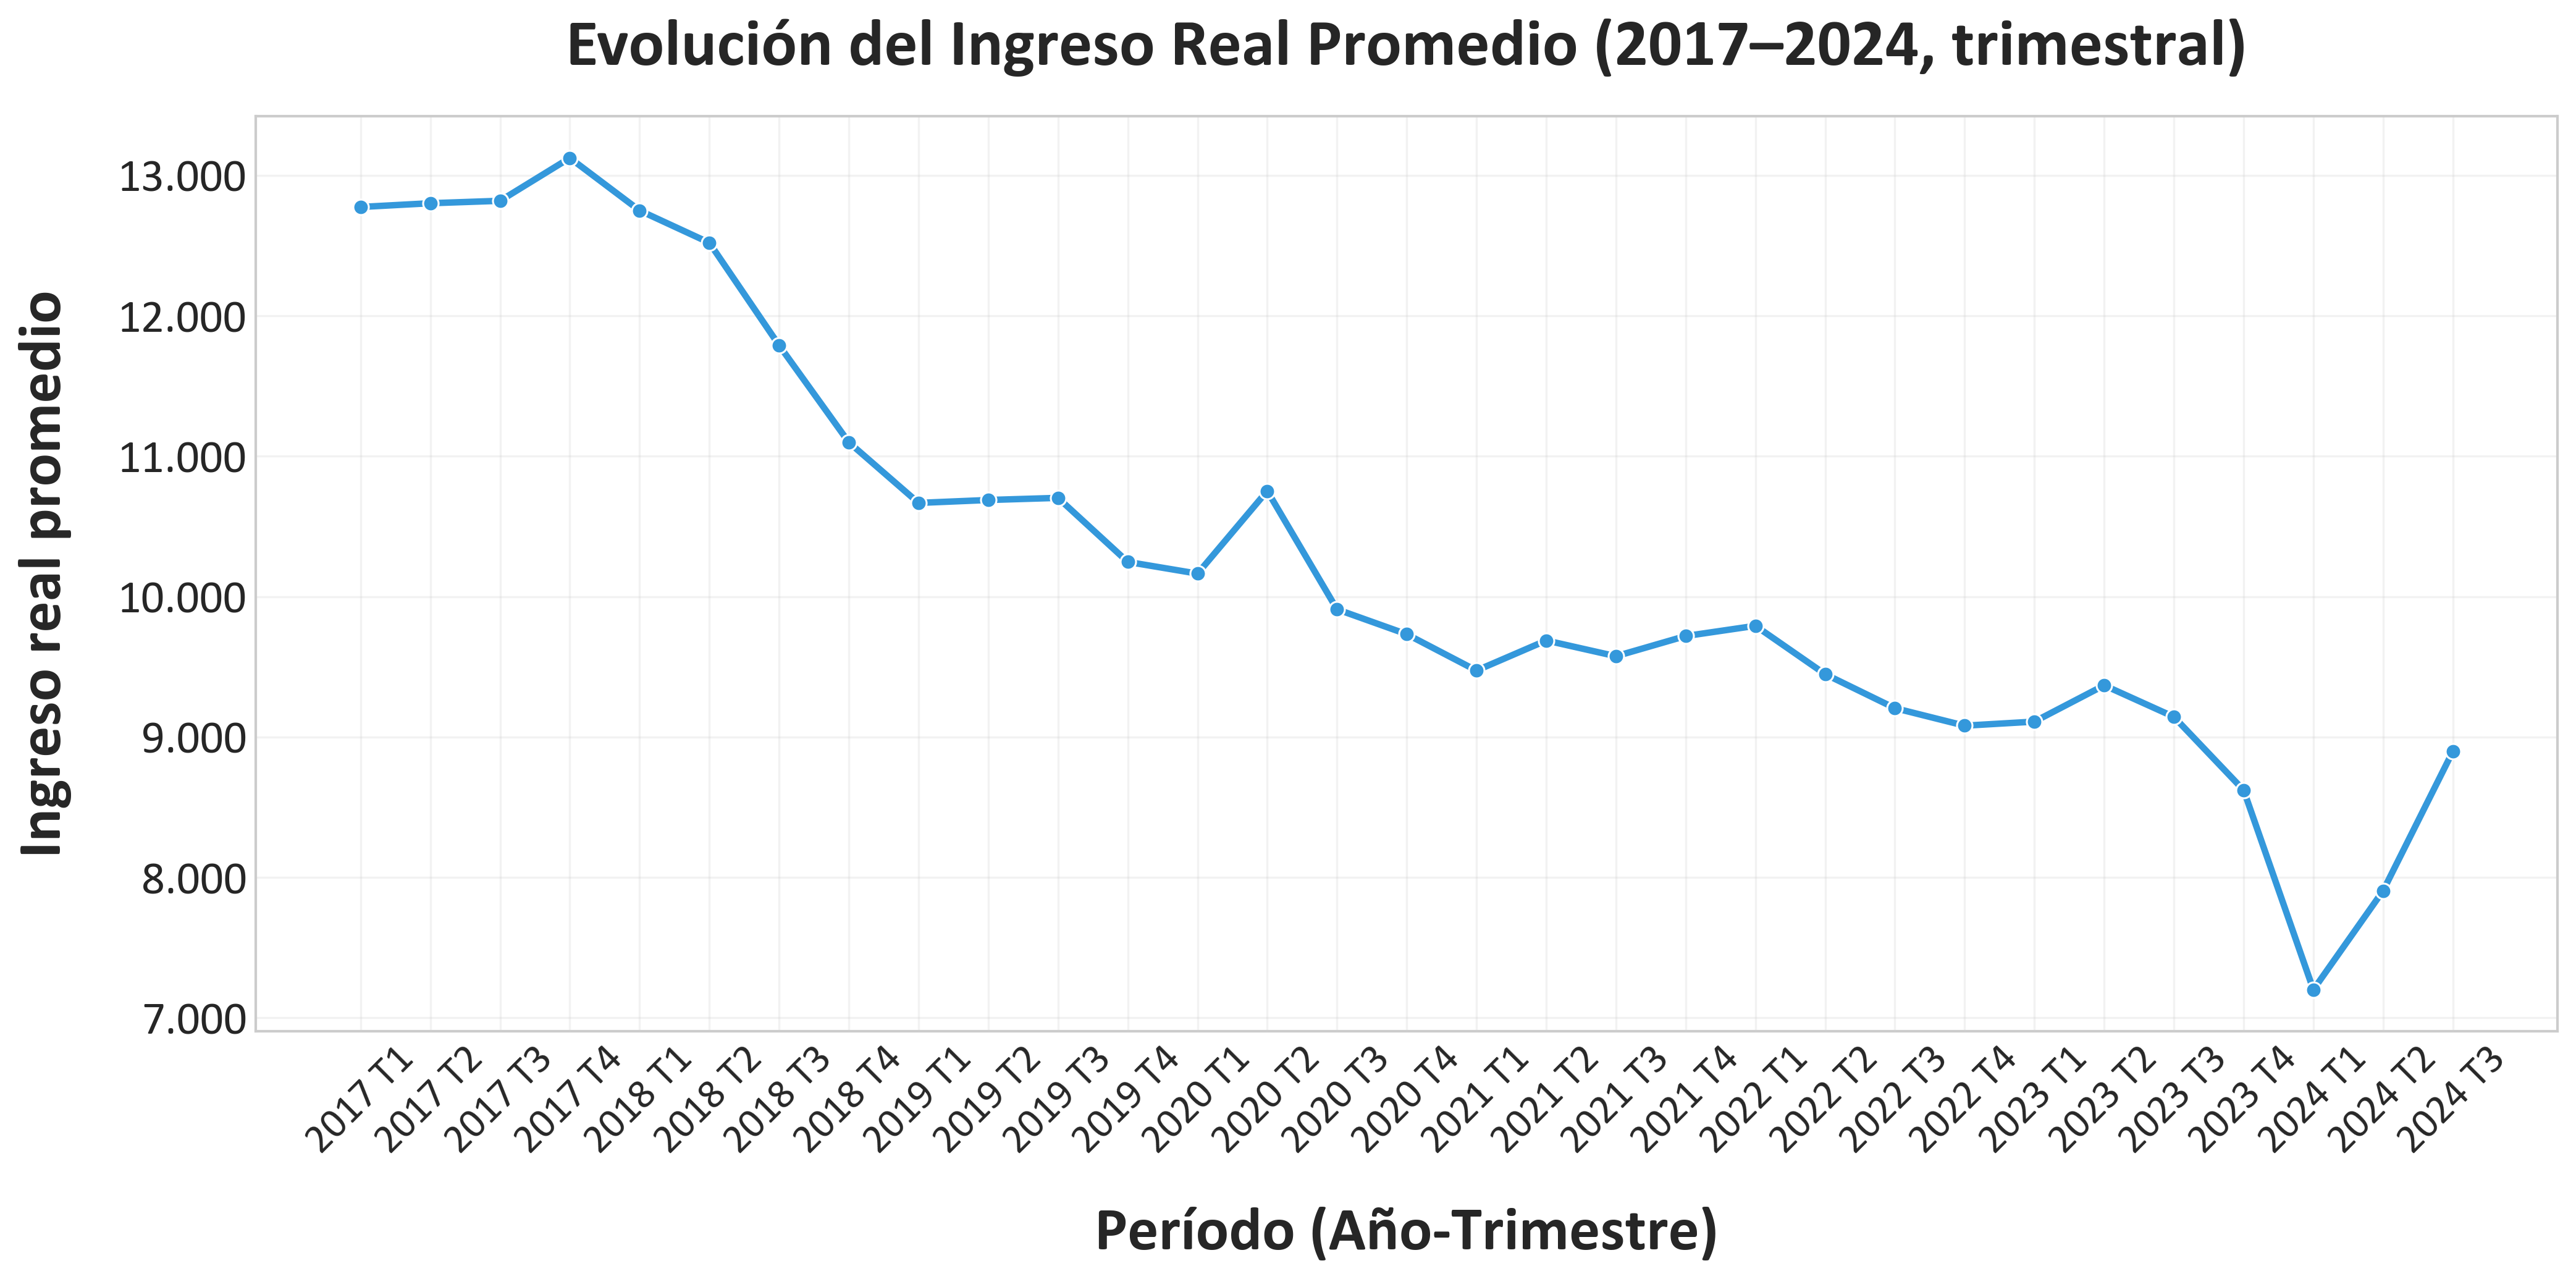

In [ ]:
import matplotlib.ticker as mtick

# =========================================================
# EVOLUCIÓN TRIMESTRAL DEL INGRESO REAL (ESTILO UNIFORME)
# =========================================================

df_evolucion = (
    df_asalariados
    .groupby(['Año', 'TRIMESTRE'])['Ingreso_Real']
    .mean()
    .reset_index()
)

# Crear etiqueta temporal ordenada
df_evolucion['Periodo'] = (
    df_evolucion['Año'].astype(str) +
    ' T' +
    df_evolucion['TRIMESTRE'].astype(str)
)

plt.figure(
    figsize=(14,7),
    dpi=300
)

sns.lineplot(
    data=df_evolucion,
    x='Periodo',
    y='Ingreso_Real',
    marker='o',
    linewidth=2.5,
    color=color_principal
)

# ---------------------------------------------------------
# TÍTULO
# ---------------------------------------------------------

plt.title(
    'Evolución del Ingreso Real Promedio (2017–2024, trimestral)',
    fontsize=26,
    fontweight='bold',
    pad=20
)

# ---------------------------------------------------------
# EJES
# ---------------------------------------------------------

plt.xlabel(
    'Período (Año-Trimestre)',
    fontsize=24,
    fontweight='bold',
    labelpad=18
)

plt.ylabel(
    'Ingreso real promedio',
    fontsize=24,
    fontweight='bold',
    labelpad=18
)

# ---------------------------------------------------------
# TICKS
# ---------------------------------------------------------

plt.xticks(
    rotation=45,
    fontsize=16
)

plt.yticks(fontsize=18)

ax = plt.gca()

# =========================================================
# FORMATO EJE Y (INGRESO CON PUNTO)
# =========================================================

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda y, p: format(int(y), ',').replace(',', '.')
    )
)

# ---------------------------------------------------------
# GRID SUAVE
# ---------------------------------------------------------

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

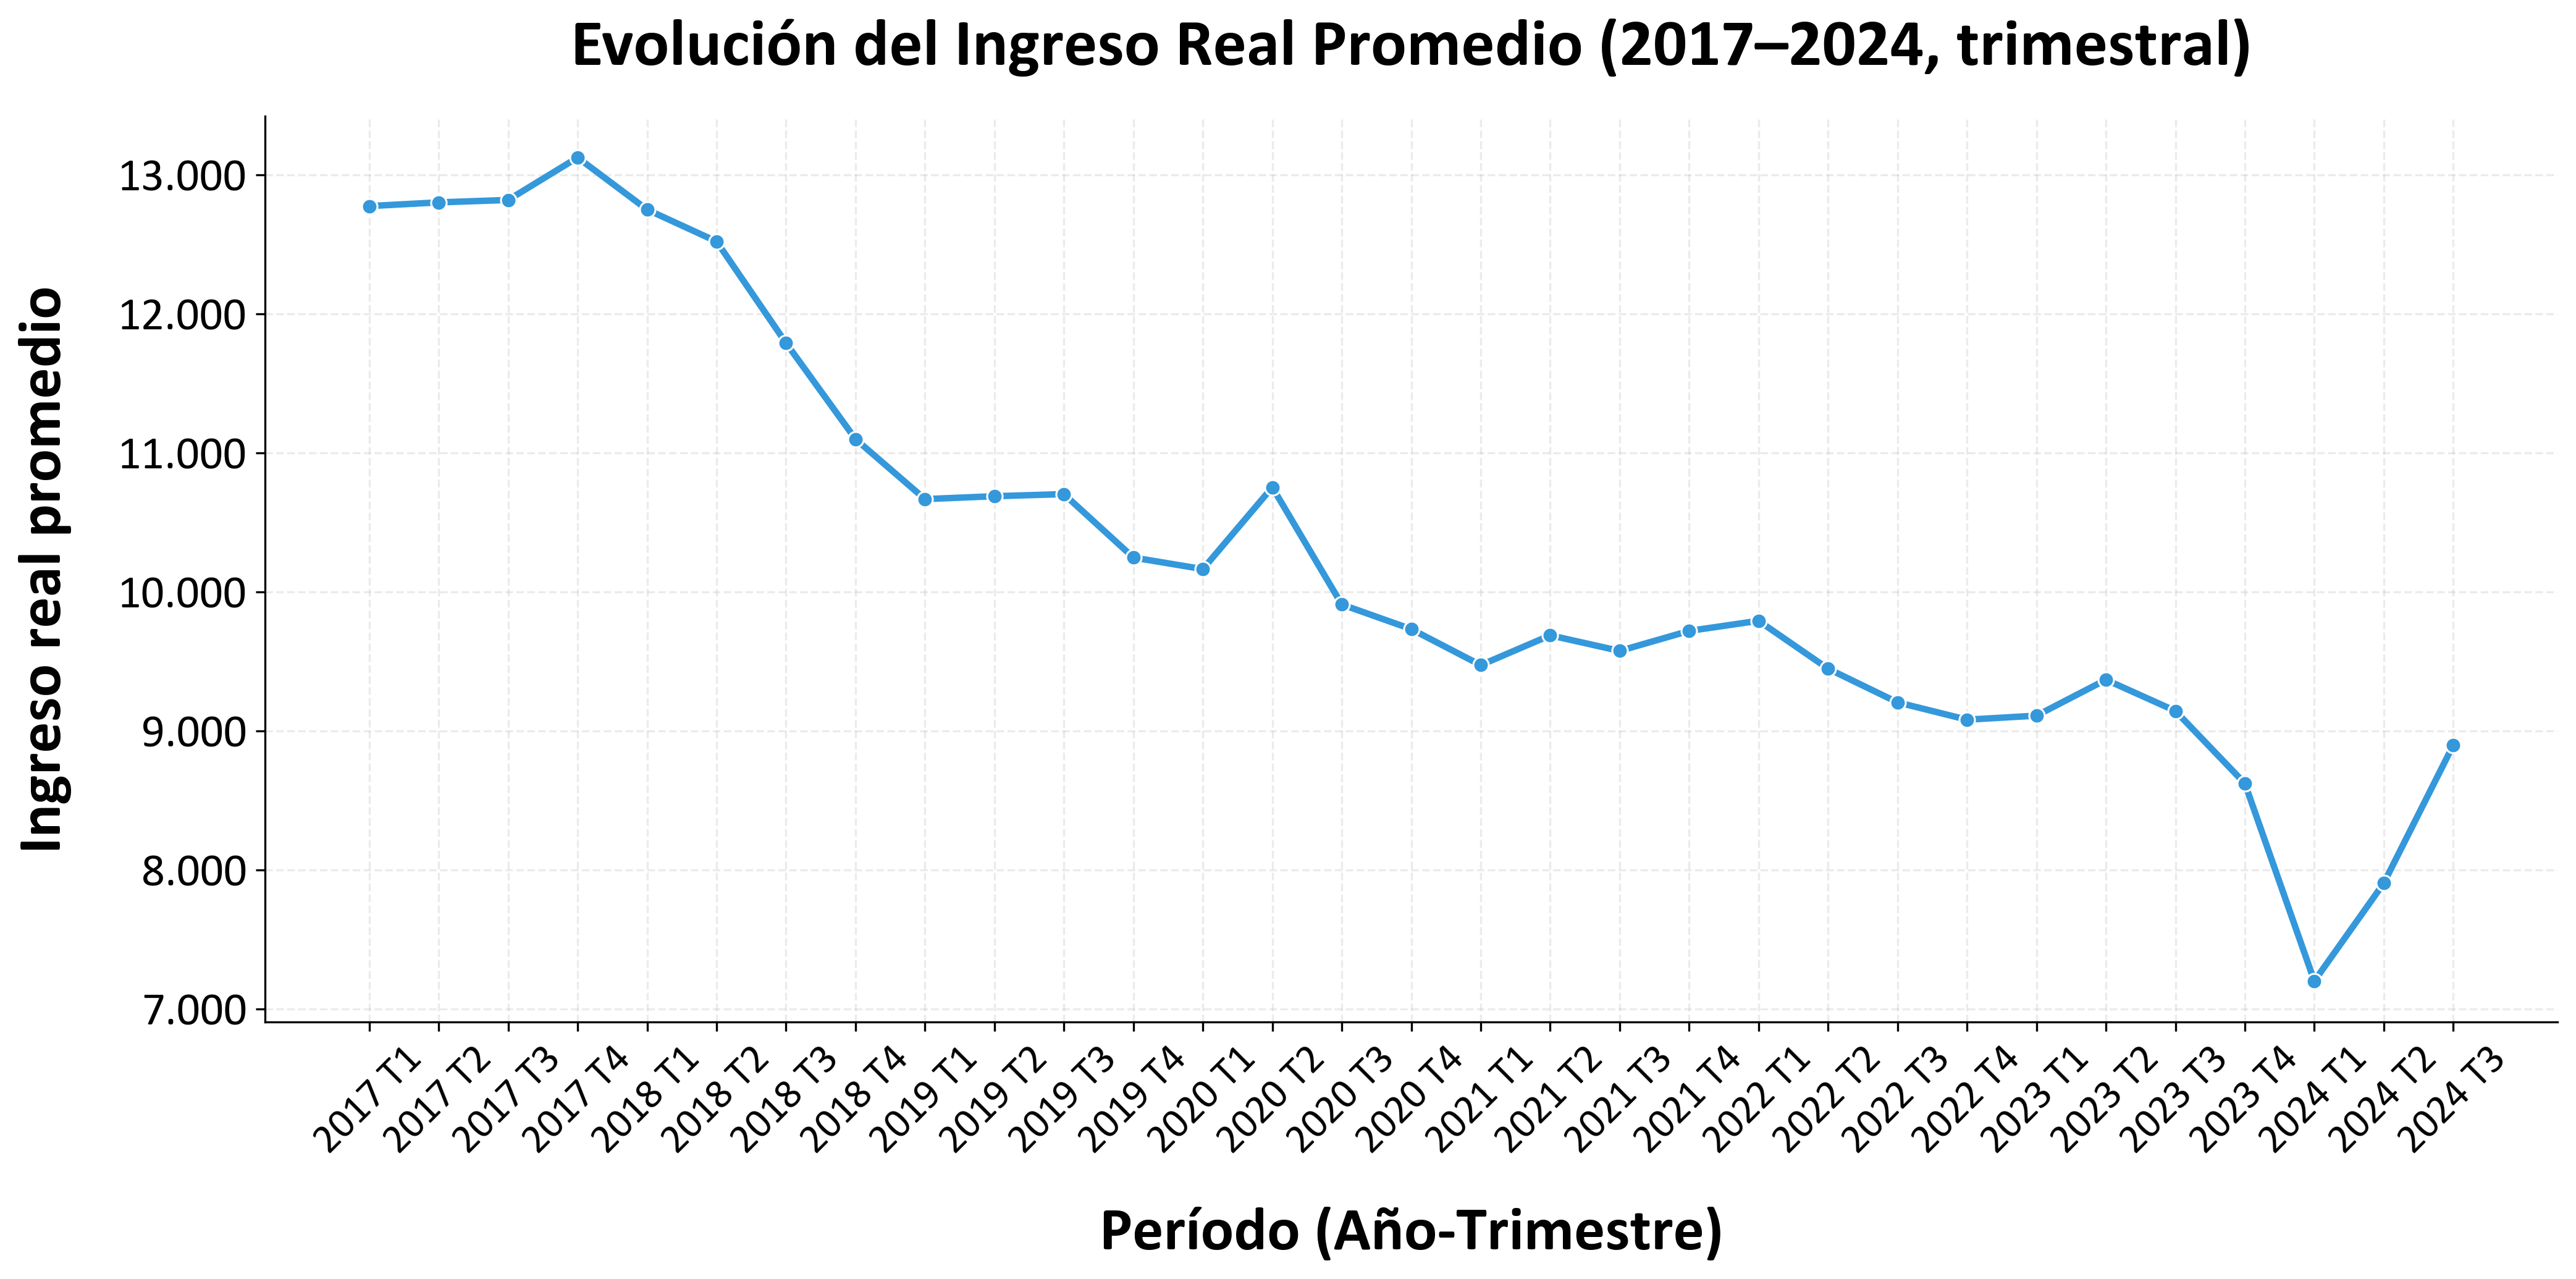

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# =========================================================
# CONFIGURACIÓN GENERAL — ESTILO TESIS
# =========================================================

plt.rcParams['font.family'] = 'Calibri'

# =========================================================
# EVOLUCIÓN TRIMESTRAL DEL INGRESO REAL
# =========================================================

df_evolucion = (
    df_asalariados
    .groupby(['Año', 'TRIMESTRE'])['Ingreso_Real']
    .mean()
    .reset_index()
)

# =========================================================
# ETIQUETA TEMPORAL
# =========================================================

df_evolucion['Periodo'] = (
    df_evolucion['Año'].astype(str) +
    ' T' +
    df_evolucion['TRIMESTRE'].astype(str)
)

# =========================================================
# GRÁFICO
# =========================================================

plt.figure(
    figsize=(14,7),
    dpi=300
)

sns.lineplot(
    data=df_evolucion,
    x='Periodo',
    y='Ingreso_Real',
    marker='o',
    linewidth=2.5,
    color=color_principal
)

# ---------------------------------------------------------
# TÍTULO
# ---------------------------------------------------------

plt.title(
    'Evolución del Ingreso Real Promedio (2017–2024, trimestral)',
    fontsize=26,
    fontweight='bold',
    pad=20
)

# ---------------------------------------------------------
# EJES
# ---------------------------------------------------------

plt.xlabel(
    'Período (Año-Trimestre)',
    fontsize=24,
    fontweight='bold',
    labelpad=18
)

plt.ylabel(
    'Ingreso real promedio',
    fontsize=24,
    fontweight='bold',
    labelpad=18
)

# ---------------------------------------------------------
# TICKS
# ---------------------------------------------------------

plt.xticks(
    rotation=45,
    fontsize=16,
    color='black'
)

plt.yticks(
    fontsize=18,
    color='black'
)

ax = plt.gca()

# =========================================================
# FORMATO EJE Y — PUNTO MILES
# =========================================================

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda y, p: format(int(y), ',').replace(',', '.')
    )
)

# ---------------------------------------------------------
# ESTÉTICA PROFESIONAL
# ---------------------------------------------------------

sns.despine()

plt.grid(
    alpha=0.25,
    linestyle='--'
)

plt.tight_layout()

plt.show()

### Ingreso Real según Nivel Educativo y Condición laboral

In [ ]:
orden_educacion = [
    "Sin instrucción",
    "Primario incompleto",
    "Primario completo",
    "Secundario incompleto",
    "Secundario completo",
    "Universitario incompleto",
    "Universitario completo"
]

df_asalariados["Nivel Educativo"] = pd.Categorical(
    df_asalariados["Nivel Educativo"],
    categories=orden_educacion,
    ordered=True
)

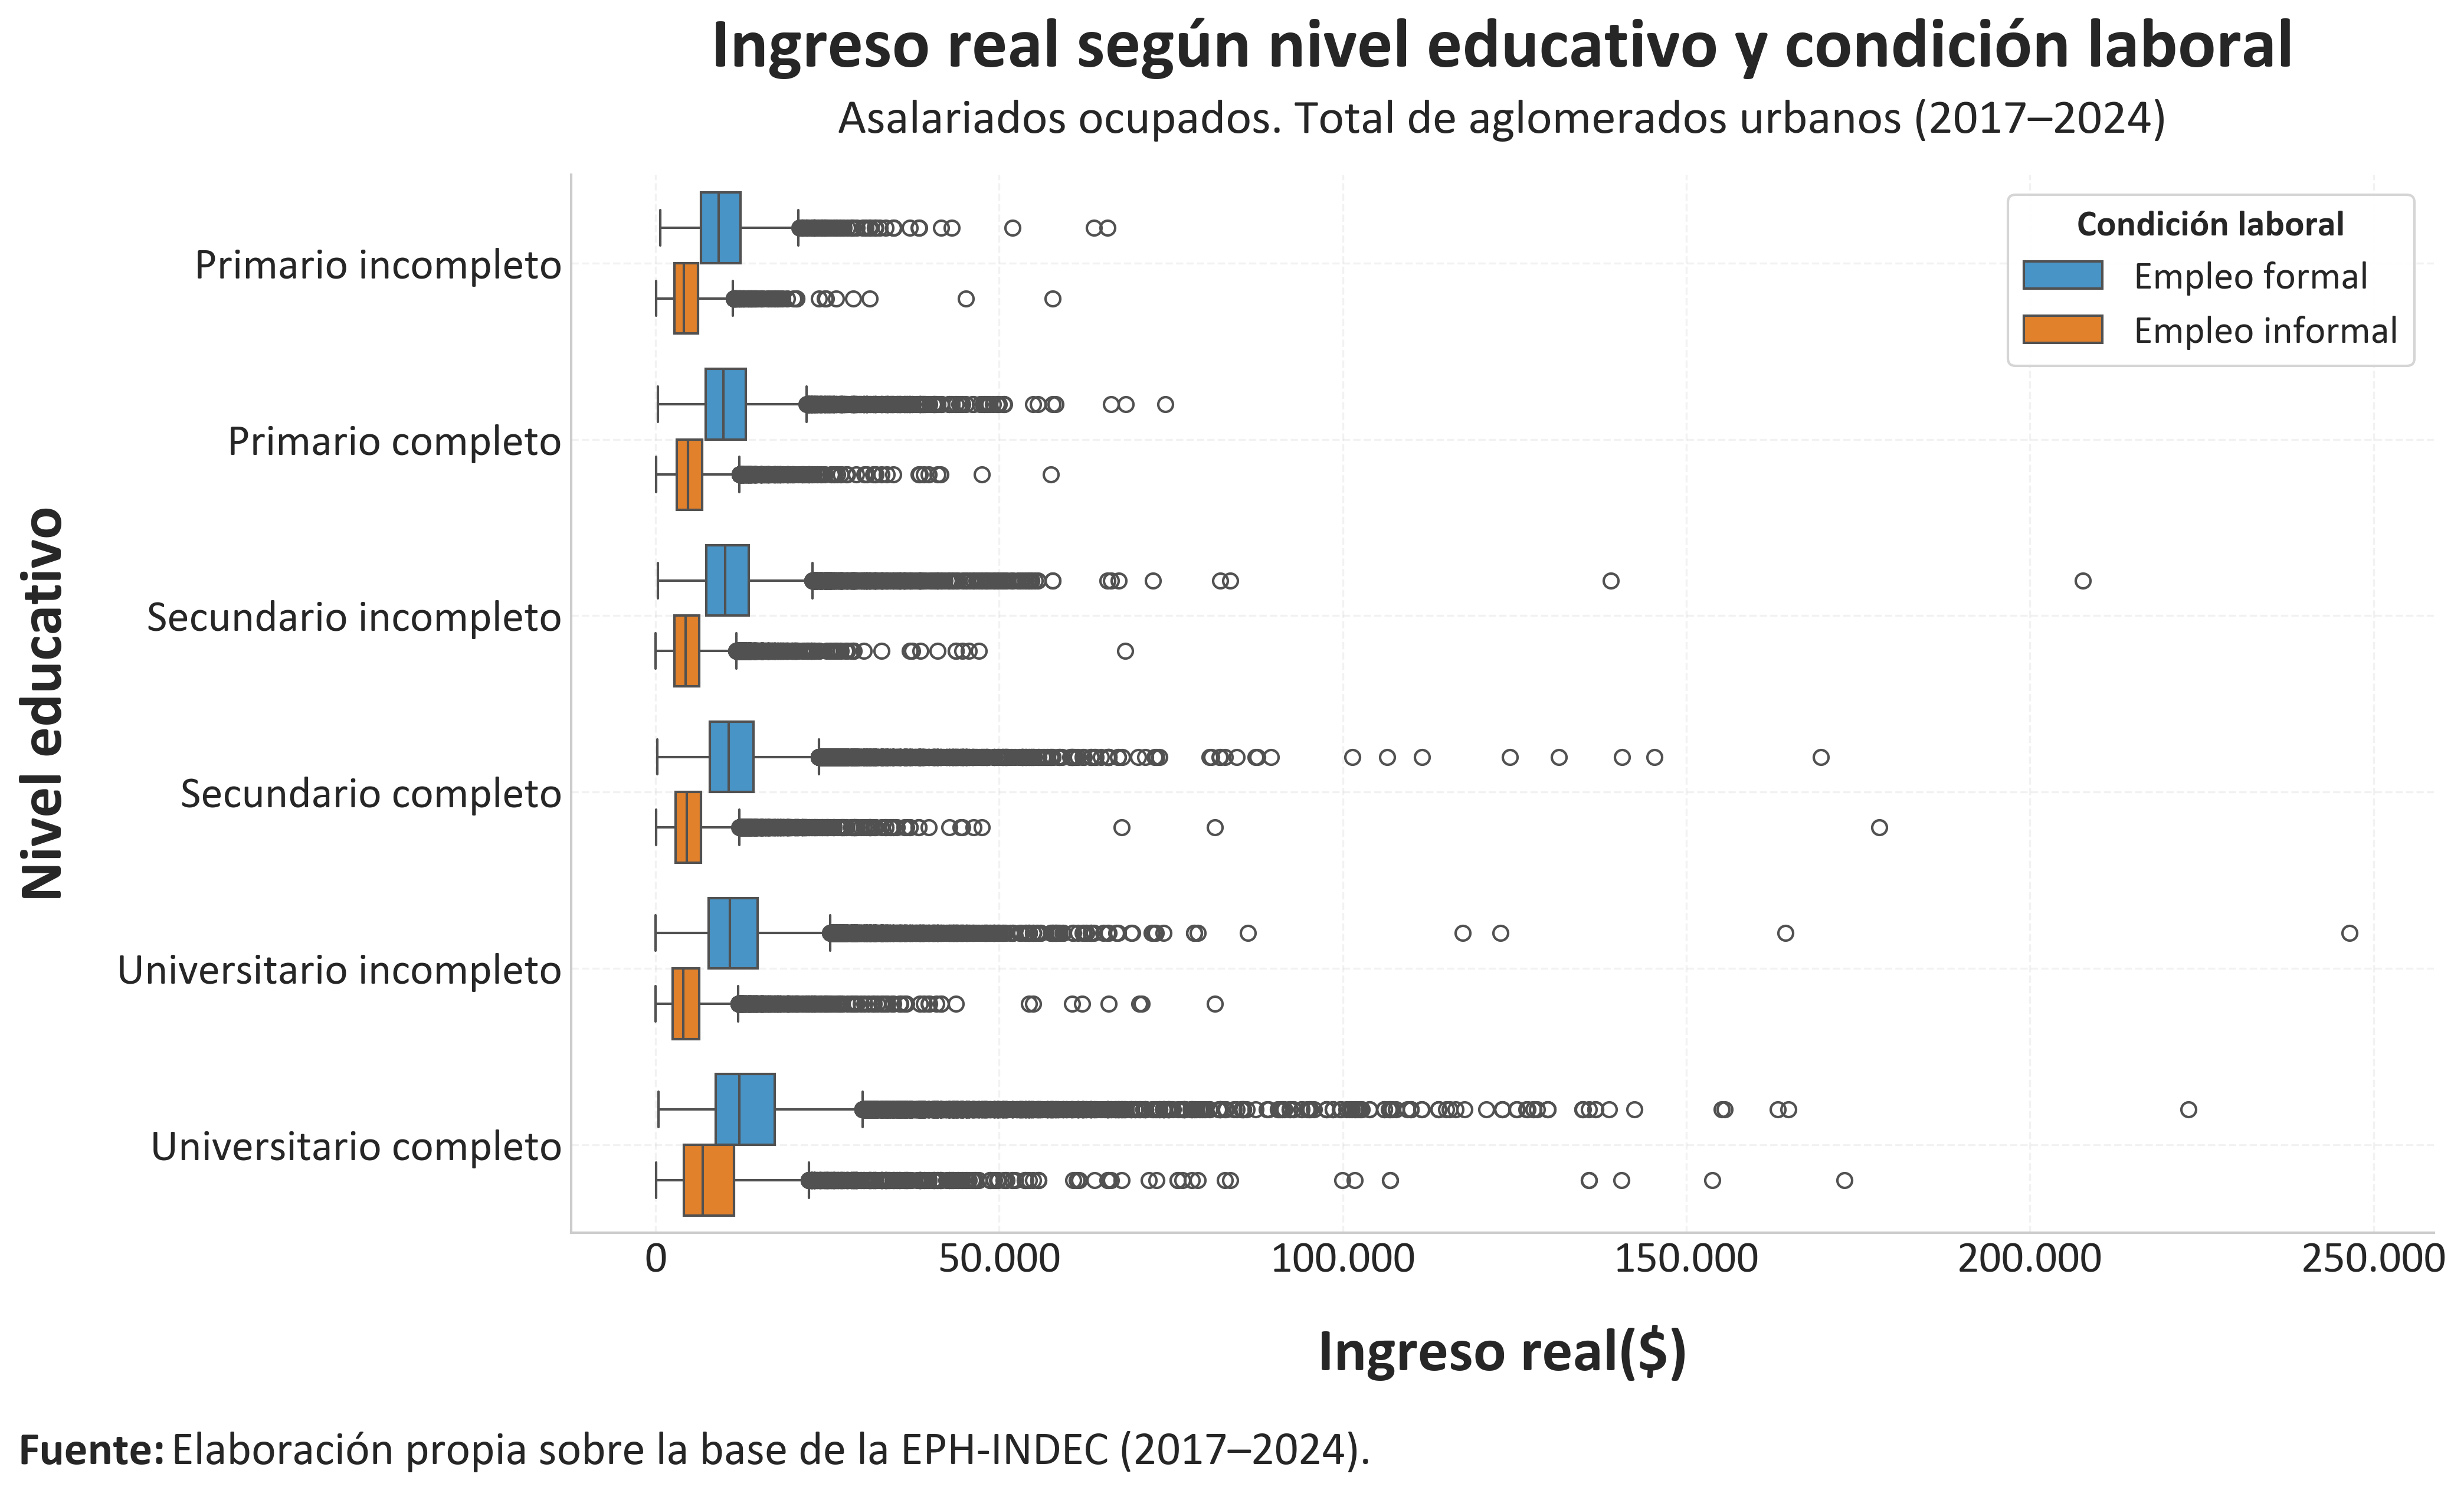

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.font_manager import FontProperties

# =========================================================
# ESTILO GENERAL
# =========================================================
plt.rcParams['font.family'] = 'Calibri'

# =========================================================
# ORDEN EDUCACIÓN (CORRECTO)
# =========================================================
orden_educacion = [
    "Primario incompleto",
    "Primario completo",
    "Secundario incompleto",
    "Secundario completo",
    "Universitario incompleto",
    "Universitario completo"
]

# =========================================================
# DATA CLEAN
# =========================================================
df_plot = df_asalariados.copy()

df_plot = df_plot.dropna(subset=[
    'Nivel Educativo',
    'Ingreso_Real',
    'Condición laboral'
])

# asegurar limpieza de texto (evita errores ocultos)
df_plot['Nivel Educativo'] = df_plot['Nivel Educativo'].str.strip()

# aplicar orden correcto
df_plot['Nivel Educativo'] = pd.Categorical(
    df_plot['Nivel Educativo'],
    categories=orden_educacion,
    ordered=True
)

# =========================================================
# FIGURA
# =========================================================
plt.figure(figsize=(14, 8), dpi=300)

ax = sns.boxplot(
    data=df_plot,
    y='Nivel Educativo',
    x='Ingreso_Real',
    hue='Condición laboral',
    order=orden_educacion,   # 🔴 CLAVE
    #palette=['#1f4e79', '#5b9bd5'],
    
    #palette={'#FF7F0E','#3498DB'},
    # COLORES
    palette={
        'Empleo formal': '#3498DB',
        'Empleo informal': '#FF7F0E'
    },
    dodge=True,
    showfliers=True
)

# =========================================================
# TÍTULO
# =========================================================
plt.title(
    'Ingreso real según nivel educativo y condición laboral',
    fontsize=29,
    fontweight='bold',
    pad=44
)

# subtítulo
plt.text(
    0.5, 1.04,
    'Asalariados ocupados. Total de aglomerados urbanos (2017–2024)',
    fontsize=20,
    ha='center',
    transform=ax.transAxes
)

# =========================================================
# EJES
# =========================================================
plt.xlabel('Ingreso real($)', fontsize=25, fontweight='bold', labelpad=18)
plt.ylabel('Nivel educativo', fontsize=25, fontweight='bold', labelpad=18)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# =========================================================
# FORMATO X
# =========================================================
ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, p: f'{x:,.0f}'.replace(',', '.'))
)

# =========================================================
# LEYENDA
# =========================================================
legend_title_font = FontProperties(weight='bold', size=15)

plt.legend(
    title='Condición laboral',
    title_fontproperties=legend_title_font,
    fontsize=16,
    frameon=True,
    facecolor='white',
    edgecolor='lightgray',
    framealpha=0.95
)

# =========================================================
# NOTA AL PIE (TESIS)
# =========================================================
plt.figtext(
    0.01,
    -0.04,
    "Fuente:",
    ha='left',
    fontsize=19,
    fontweight='bold'
)

plt.figtext(
    0.072,
    -0.04,
    "Elaboración propia sobre la base de la EPH-INDEC (2017–2024).",
    ha='left',
    fontsize=19
)

# =========================================================
# ESTÉTICA FINAL
# =========================================================
sns.despine()
plt.grid(alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

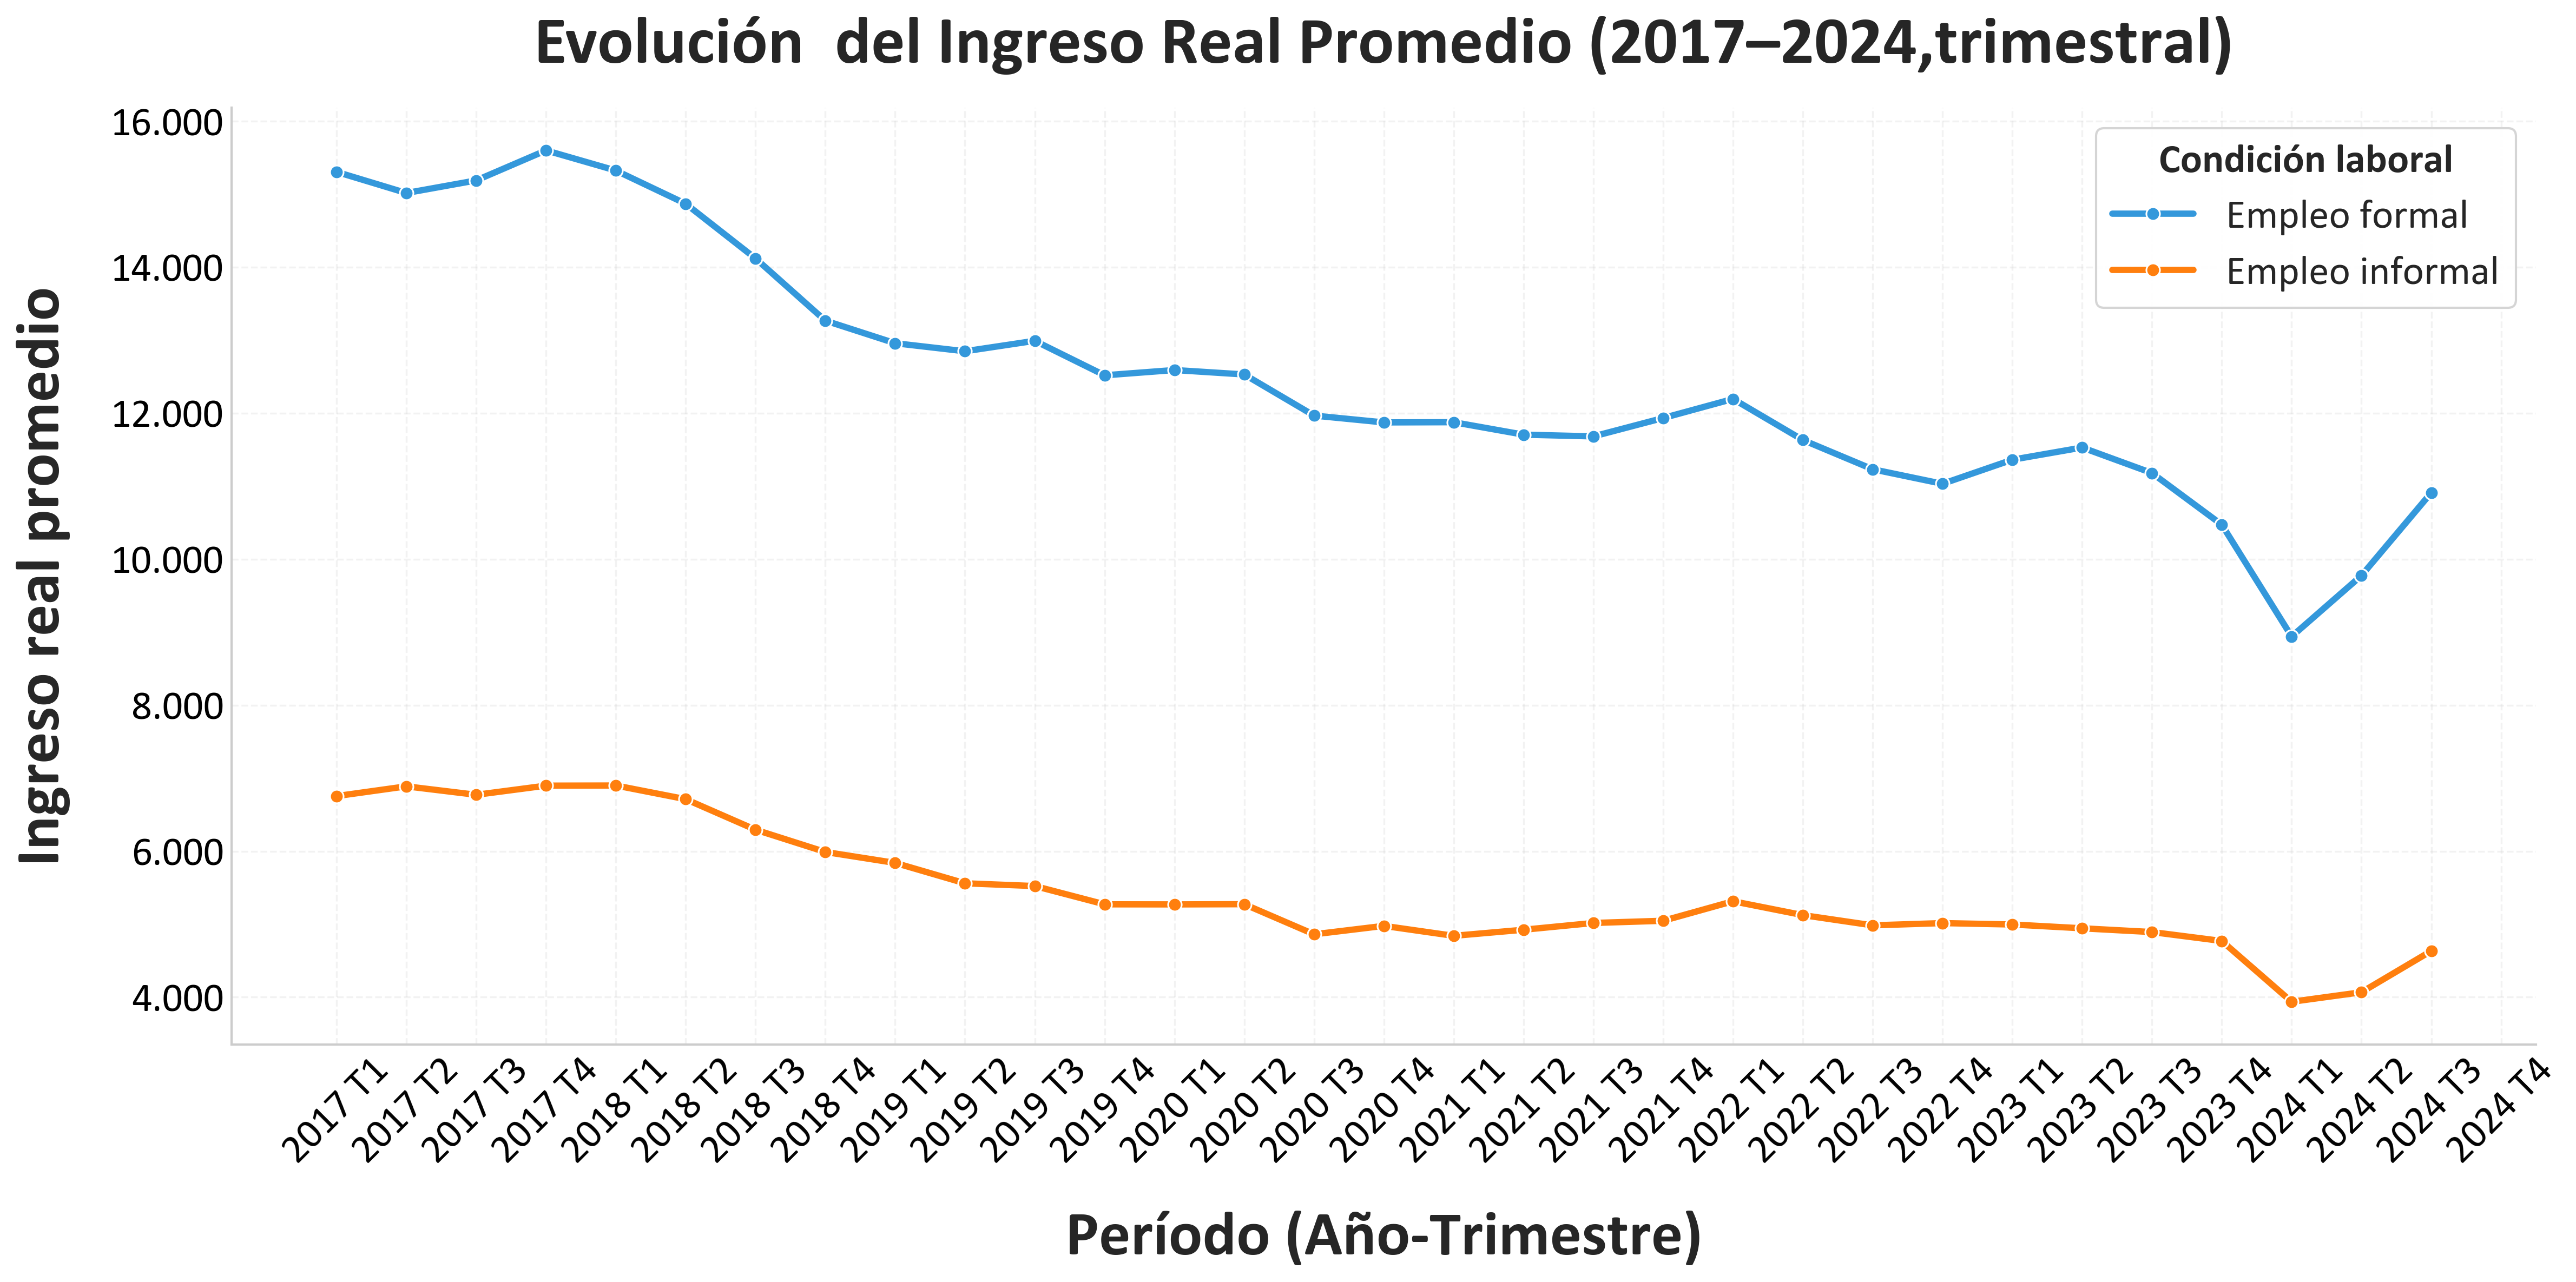

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.font_manager import FontProperties

# =========================================================
# CONFIGURACIÓN GENERAL — ESTILO TESIS
# =========================================================

plt.rcParams['font.family'] = 'Calibri'

# =========================================================
# EVOLUCIÓN TRIMESTRAL DEL INGRESO REAL
# SEGÚN CONDICIÓN LABORAL (2017–2024)
# =========================================================

df_asalariados = (
    df_asalariados
    .groupby(
        ['Año', 'TRIMESTRE', 'Condición laboral']
    )['Ingreso_Real']
    .mean()
    .reset_index()
)

# =========================================================
# CREAR ETIQUETA TEMPORAL
# =========================================================

df_asalariados['Periodo'] = (
    df_asalariados['Año'].astype(str)
    + ' T'
    + df_asalariados['TRIMESTRE'].astype(str)
)

# =========================================================
# GRÁFICO
# =========================================================

plt.figure(
    figsize=(16,8),
    dpi=300
)

sns.lineplot(
    data=df_asalariados,
    x='Periodo',
    y='Ingreso_Real',
    hue='Condición laboral',
    marker='o',
    linewidth=2.8,
    #palette=['#1f4e79', '#5b9bd5']
    palette=['#3498DB', '#FF7F0E']
)

# ---------------------------------------------------------
# TÍTULO
# ---------------------------------------------------------

plt.title(
    'Evolución  del Ingreso Real Promedio (2017–2024,trimestral)',
    fontsize=30,
    fontweight='bold',
    pad=20
)



# ---------------------------------------------------------
# EJES
# ---------------------------------------------------------

plt.xlabel(
    'Período (Año-Trimestre)',
    fontsize=28,
    fontweight='bold',
    labelpad=18
)

plt.ylabel(
    'Ingreso real promedio',
    fontsize=28,
    fontweight='bold',
    labelpad=18
)

# ---------------------------------------------------------
# TICKS
# ---------------------------------------------------------

plt.xticks(
    rotation=45,
    fontsize=18,
    color='black'
)

plt.yticks(
    fontsize=18,
    color='black'
)

ax = plt.gca()

# =========================================================
# FORMATO EJE Y — PUNTO MILES
# =========================================================

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda y, p: format(int(y), ',').replace(',', '.')
    )
)

# ---------------------------------------------------------
# LEYENDA — ESTILO HOMOGÉNEO
# ---------------------------------------------------------

legend_title_font = FontProperties(
    weight='bold',
    size=18
)

plt.legend(
    title='Condición laboral',
    title_fontproperties=legend_title_font,
    fontsize=18,
    frameon=True,
    facecolor='white',
    edgecolor='lightgray',
    framealpha=0.95,
    fancybox=True
)

# ---------------------------------------------------------
# ESTÉTICA PROFESIONAL
# ---------------------------------------------------------

sns.despine()

plt.grid(
    alpha=0.25,
    linestyle='--'
)

plt.tight_layout()

plt.show()

### Evolución del Ingreso Real Promedio

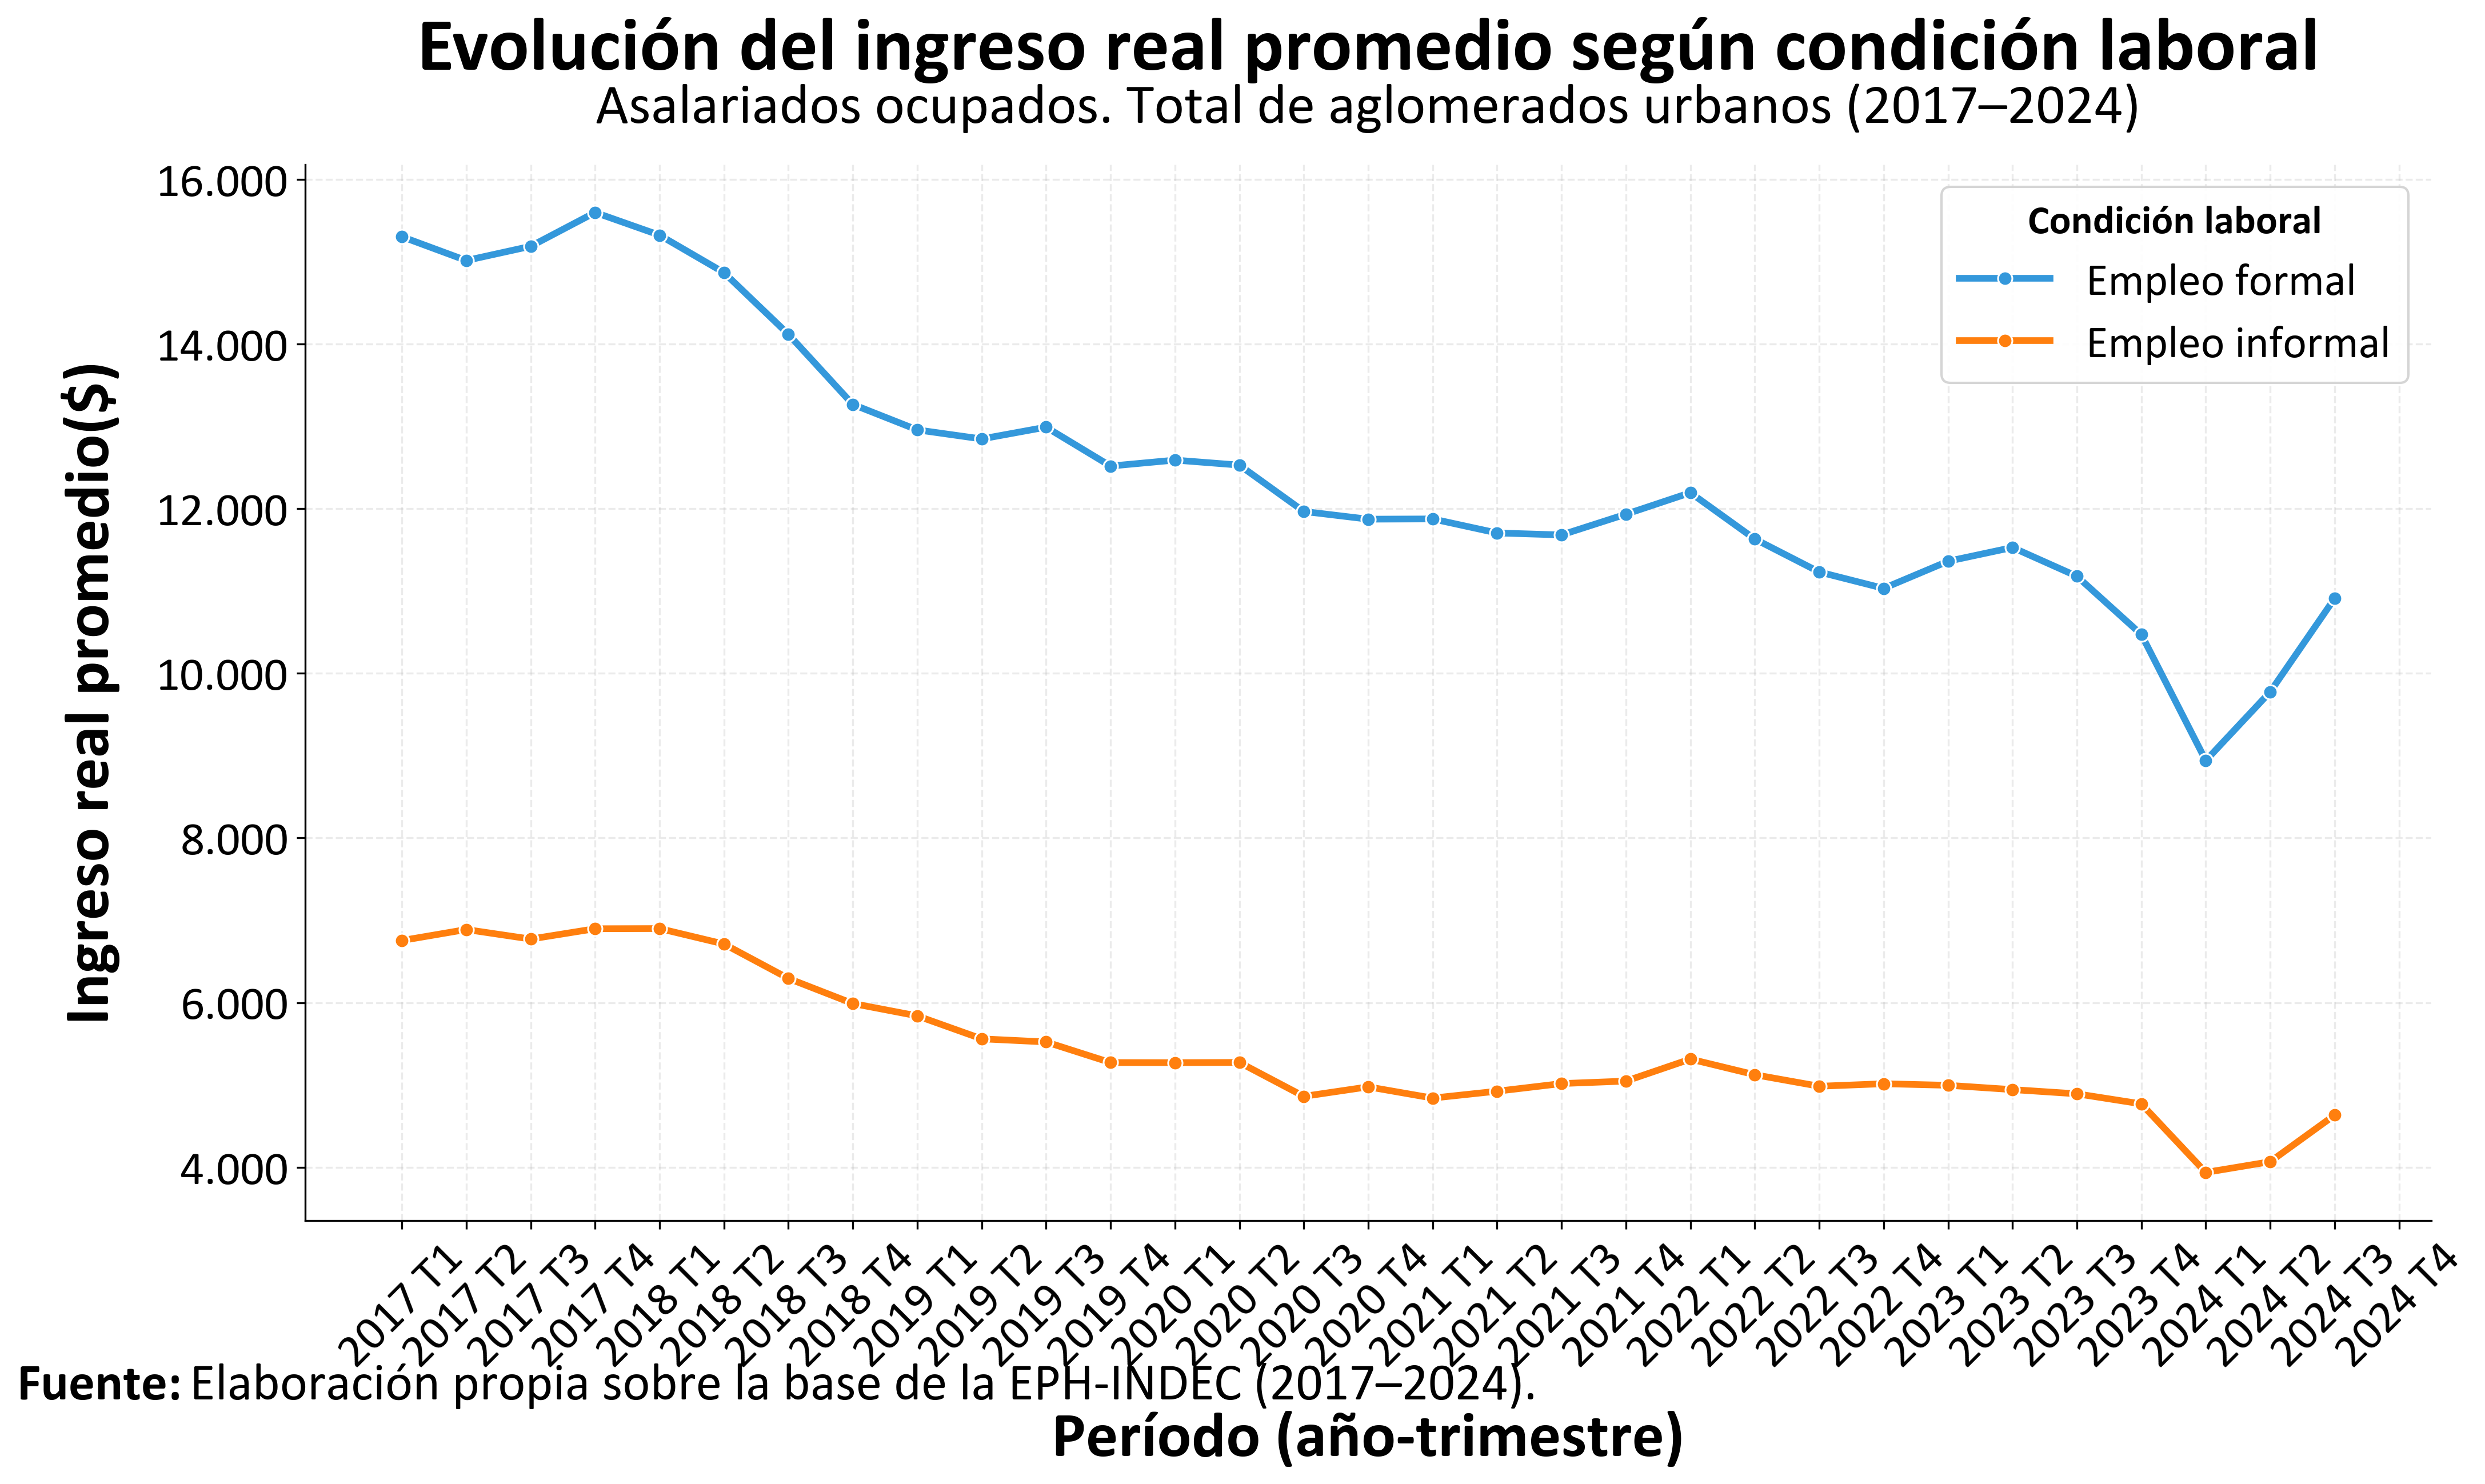

<Figure size 640x480 with 0 Axes>

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.font_manager import FontProperties

# =========================================================
# CONFIGURACIÓN GENERAL — ESTILO TESIS
# =========================================================

plt.rcParams['font.family'] = 'Calibri'

# =========================================================
# EVOLUCIÓN TRIMESTRAL DEL INGRESO REAL
# SEGÚN CONDICIÓN LABORAL
# =========================================================

df_evolucion = (
    df_asalariados
    .groupby(
        ['Año', 'TRIMESTRE', 'Condición laboral']
    )['Ingreso_Real']
    .mean()
    .reset_index()
)

# =========================================================
# CREAR ETIQUETA TEMPORAL
# =========================================================

df_evolucion['Periodo'] = (
    df_evolucion['Año'].astype(str)
    + ' T'
    + df_evolucion['TRIMESTRE'].astype(str)
)

# =========================================================
# GRÁFICO
# =========================================================

plt.figure(
    figsize=(16,8),
    dpi=300
)

sns.lineplot(
    data=df_evolucion,
    x='Periodo',
    y='Ingreso_Real',
    hue='Condición laboral',
    marker='o',
    linewidth=2.8,
    #palette=['#1f4e79', '#5b9bd5']
    palette={
        'Empleo formal': '#3498DB',
        'Empleo informal': '#FF7F0E'
    },
)

ax = plt.gca()

# ---------------------------------------------------------
# TÍTULO
# ---------------------------------------------------------

plt.title(
    'Evolución del ingreso real promedio según condición laboral',
    fontsize=32,
    fontweight='bold',
    pad=40
)

# ---------------------------------------------------------
# SUBTÍTULO / PERÍODO DE REFERENCIA
# ---------------------------------------------------------

plt.text(
    0.5,
    1.04,
    'Asalariados ocupados. Total de aglomerados urbanos (2017–2024)',
    fontsize=24,
    ha='center',
    transform=ax.transAxes
)

# ---------------------------------------------------------
# EJES
# ---------------------------------------------------------

plt.xlabel(
    'Período (año-trimestre)',
    fontsize=27,
    fontweight='bold',
    labelpad=15
)

plt.ylabel(
    'Ingreso real promedio($)',
    fontsize=27,
    fontweight='bold',
    labelpad=15
)

# ---------------------------------------------------------
# TICKS
# ---------------------------------------------------------

plt.xticks(
    rotation=45,
    fontsize=20,
    color='black'
)

plt.yticks(
    fontsize=20,
    color='black'
)

# =========================================================
# FORMATO EJE Y — PUNTO MILES
# =========================================================

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda y, p: format(int(y), ',').replace(',', '.')
    )
)

# ---------------------------------------------------------
# LEYENDA — ESTILO HOMOGÉNEO
# ---------------------------------------------------------

legend_title_font = FontProperties(
    weight='bold',
    size=17
)

plt.legend(
    title='Condición laboral',
    title_fontproperties=legend_title_font,
    fontsize=19,
    frameon=True,
    facecolor='white',
    edgecolor='lightgray',
    framealpha=0.95,
    fancybox=True
)



# ---------------------------------------------------------
# ESTÉTICA PROFESIONAL
# ---------------------------------------------------------

sns.despine()

plt.grid(
    alpha=0.25,
    linestyle='--'
)

# =========================================================
# NOTA AL PIE
# =========================================================
plt.figtext(
    0.02,
    -0.02,
    "Fuente:",
    ha='left',
    fontsize=22,
    fontweight='bold'
)

plt.figtext(
    0.083,
    -0.02,
    "Elaboración propia sobre la base de la EPH-INDEC (2017–2024).",
    ha='left',
    fontsize=22
)

### Se incorpora la figura al repositorio de GitHub para su uso en el TIF.

plt.savefig(
    r'D:\repositorios\modelos-segmentacion-laboral\Figuras\figura_3_evolucion_ingreso_real_condicion_laboral.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

plt.tight_layout(rect=[0, 0.04, 1, 0.95])

plt.show()

In [99]:
df_asalariados.columns[df_asalariados.columns == 'Año']

Index([], dtype='object')

### %Empleo formal vs empleo informal

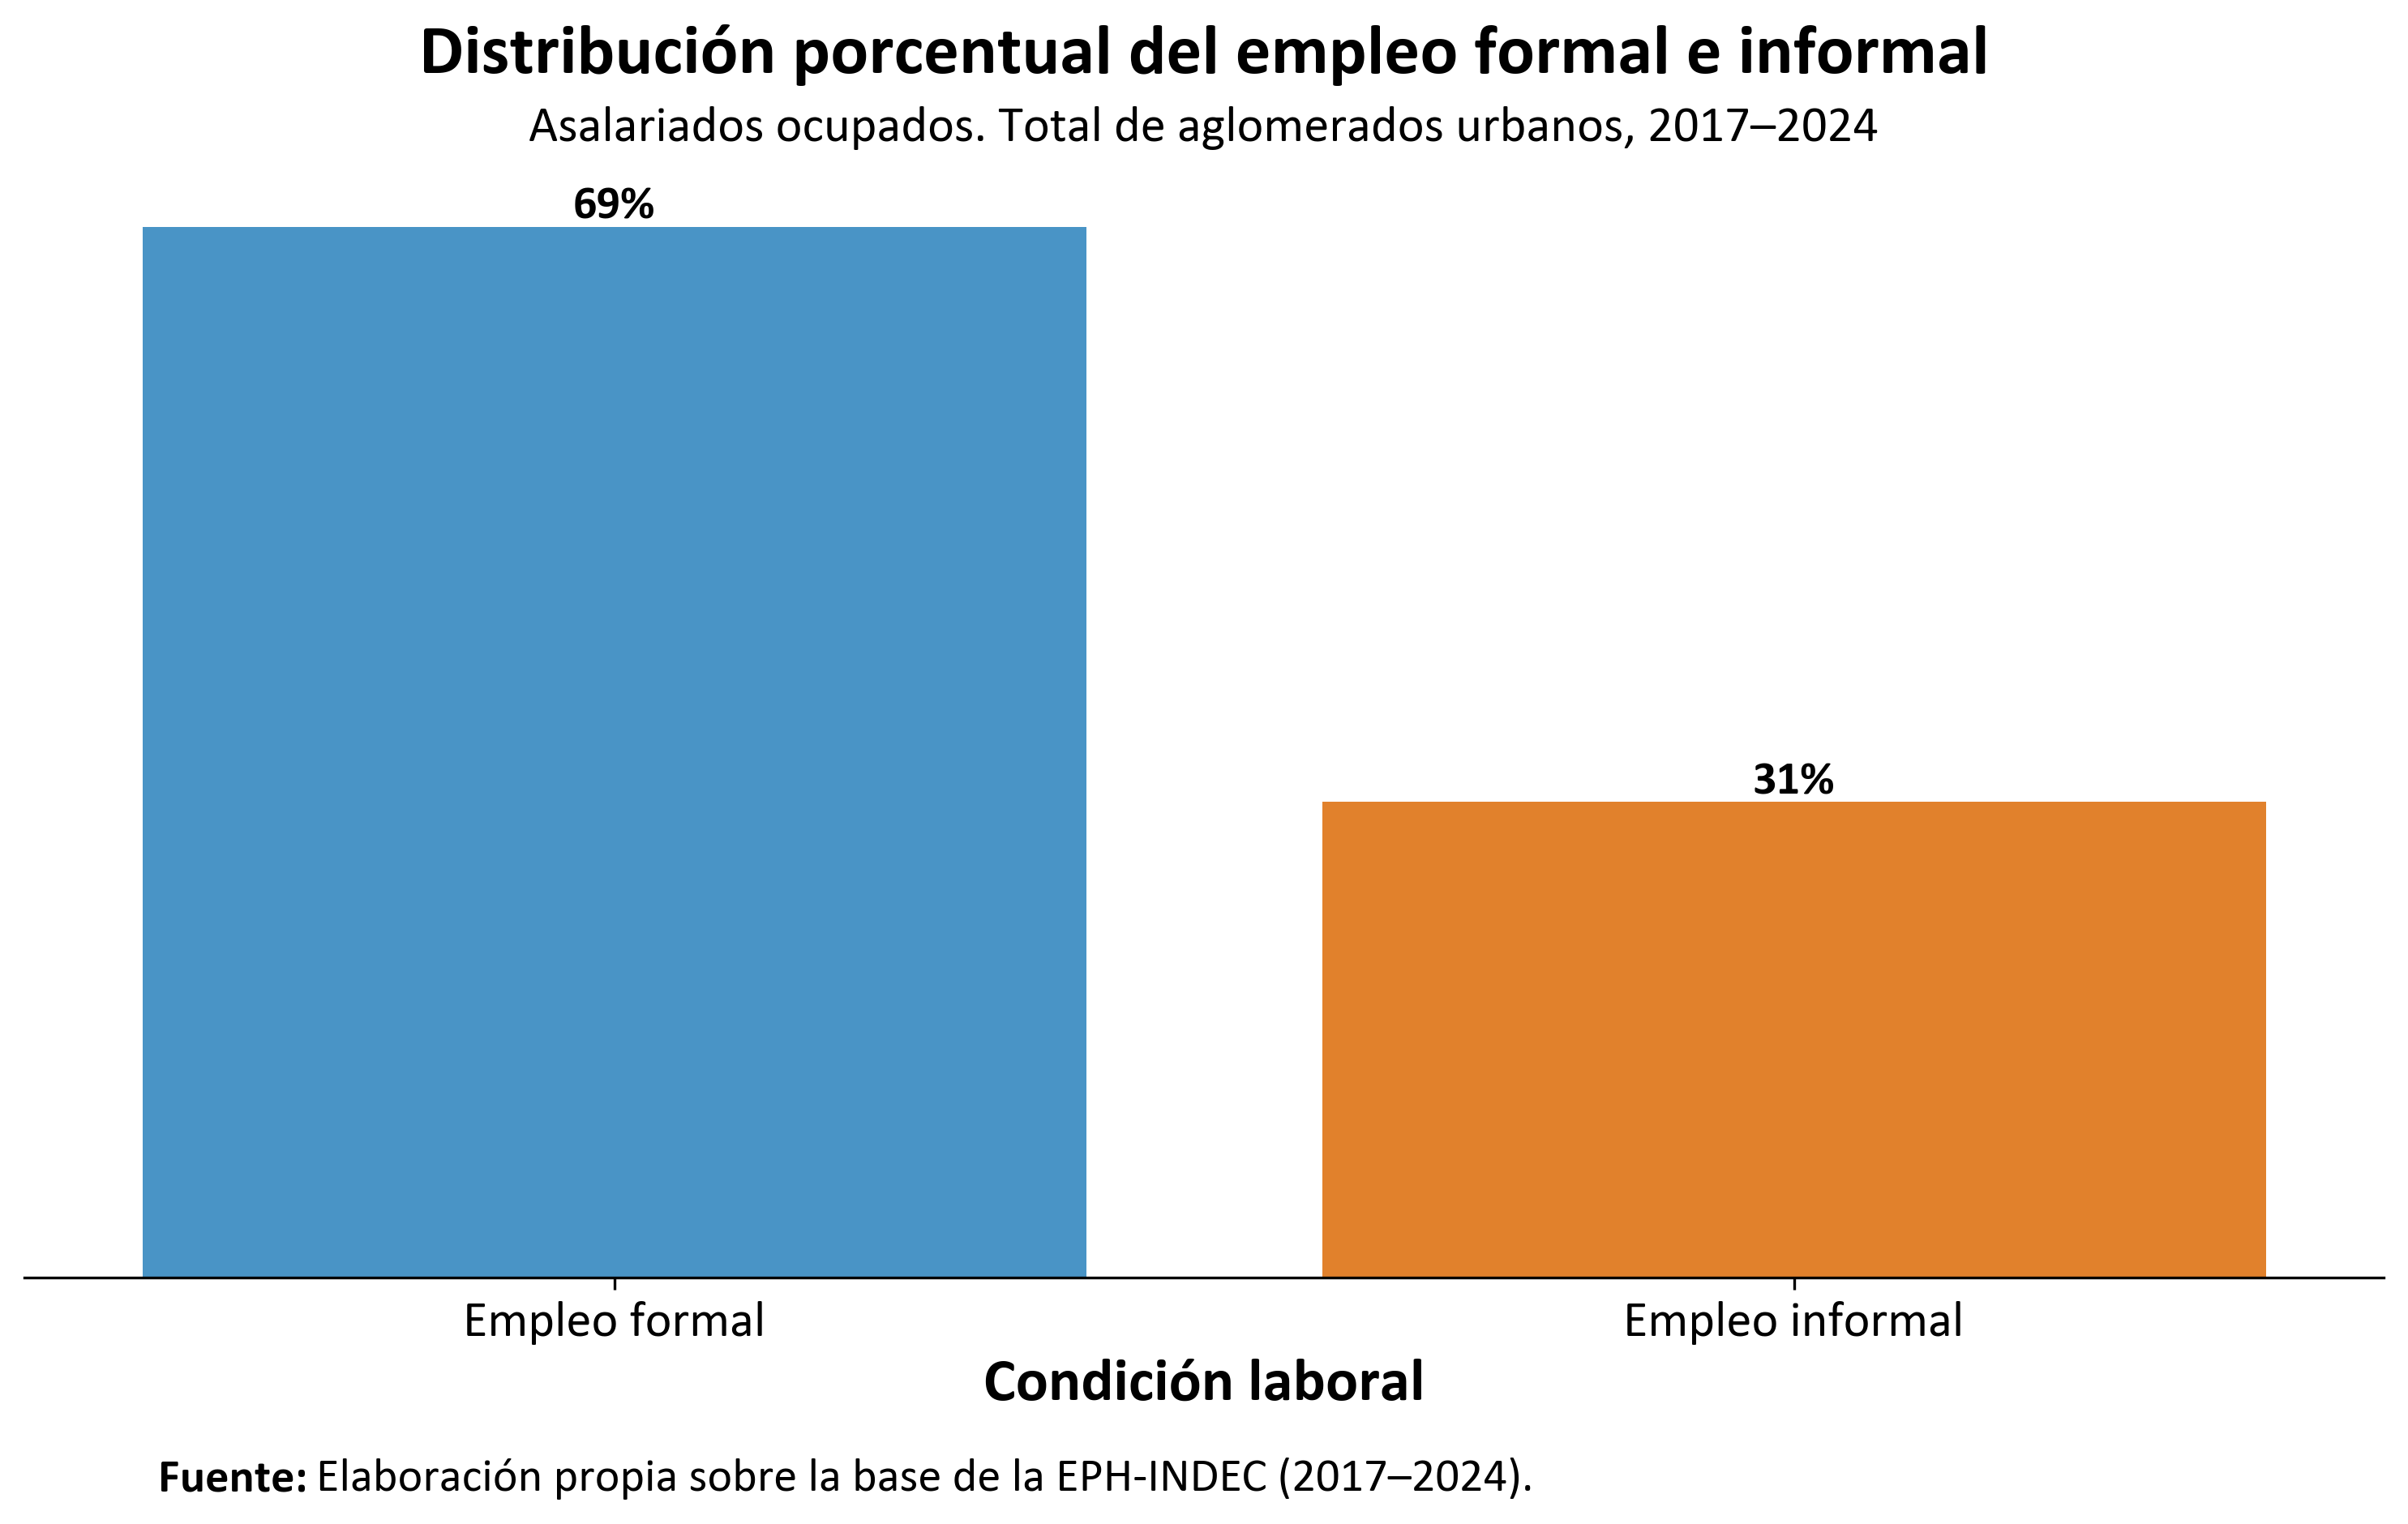

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# CONFIGURACIÓN GENERAL — ESTILO TESIS
# =========================================================
plt.rcParams['font.family'] = 'Calibri'

# =========================================================
# TAMAÑOS
# =========================================================
TITULO_SIZE = 21
SUBTITULO_SIZE = 15
LABEL_SIZE = 18
VALORES_SIZE = 14

# =========================================================
# DATOS
# =========================================================
df_inf = (
    df_asalariados['Condición laboral']
    .value_counts(normalize=True)
    .reset_index()
)

df_inf.columns = ['Formalidad_laboral', 'Proporcion']
df_inf['Proporcion'] *= 100

# =========================================================
# GRÁFICO
# =========================================================
plt.figure(figsize=(10, 6), dpi=300)
ax = plt.gca()

sns.barplot(
    data=df_inf,
    x='Formalidad_laboral',
    y='Proporcion',
    #palette=['#1f4e79', '#5b9bd5']
    palette=['#3498DB', '#FF7F0E'],
)

# =========================================================
# OCULTAR EJES (CLAVE DEL ESTILO)
# =========================================================
ax.set_ylabel("")
ax.set_yticks([])
ax.set_yticklabels([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# =========================================================
# TÍTULO
# =========================================================
plt.title(
    'Distribución porcentual del empleo formal e informal',
    fontsize=TITULO_SIZE,
    fontweight='bold',
    pad=30
)

# =========================================================
# SUBTÍTULO
# =========================================================
plt.text(
    0.5,
    1.03,
    'Asalariados ocupados. Total de aglomerados urbanos, 2017–2024',
    fontsize=SUBTITULO_SIZE,
    ha='center',
    transform=ax.transAxes
)

# =========================================================
# ETIQUETA EJE X
# =========================================================
plt.xlabel(
    'Condición laboral',
    fontsize=LABEL_SIZE,
    fontweight='bold'
)

plt.xticks(fontsize=15)

# =========================================================
# VALORES SOBRE BARRAS
# =========================================================
for p in ax.patches:
    altura = p.get_height()

    ax.annotate(
        f'{altura:.0f}%',
        (p.get_x() + p.get_width() / 2., altura),
        ha='center',
        va='bottom',
        fontsize=VALORES_SIZE,
        fontweight='bold'
    )

# =========================================================
# GRILLA SUAVE SOLO PARA REFERENCIA VISUAL (OPCIONAL)
# =========================================================
plt.grid(axis='y', alpha=0.15)

sns.despine(left=True)

plt.tight_layout()

# =========================================================
# NOTA AL PIE
# =========================================================
plt.figtext(
    0.07,
    -0.03,
    "Fuente:",
    ha='left',
    fontsize=14,
    fontweight='bold'
)

plt.figtext(
    0.135,
    -0.03,
    "Elaboración propia sobre la base de la EPH-INDEC (2017–2024).",
    ha='left',
    fontsize=14
)

### Se incorpora la figura al repositorio de Github para su uso en el TIF.
plt.savefig(
    r'D:\repositorios\modelos-segmentacion-laboral\Figuras\figura_2_condicion_laboral.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()